In [648]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import matplotlib.patches as patches
from sklearn import metrics
from scipy.spatial import distance
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'

In [649]:
# LIB: Base

task = "Task"
shovel = "Shovel"
cube = "Cube"

condition_key = "Condition"
c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"
conditions = [c_0, c_1, c_2, p_0, p_1, p_2]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

device_key = "Device"
device_proxy = "P"
device_controller = "C"
devices = [device_controller, device_proxy]

scaling_key = "Scaling"
scaling_none = "0"
scaling_subtle = "1"
scaling_pronounced = "2"
scalings = [scaling_none, scaling_subtle, scaling_pronounced]

device_x_scaling_key = "Device * Scaling"

subject_key = "Subject"

def get_confidence_interval(values):
    return 1.96 * np.std(values) / np.sqrt(len(values))

In [650]:
# LIB: Measurements

cohort = [
    #LS1
    "1_AlDe",
    "2_ReDo",
    "3_JuRo",
    "4_MaPo",
    "5_MaGo",
    "6_ElHa",
    #LS2
    "7_KlMe",
    "8_JuUe",
    "9_PhBa",
    "10_ToBa",
    "11_SePe",
    "12_ViDi",
    #LS3
    "13_FaPu",
    "14_JeBi",
    "15_DaEi",
    "16_MaEg",
    "17_JaDe",
    "18_InHo",
    #LS4
    "19_ToGr",
    "20_PeBu",
    "21_HaPr",
    "22_ClSt",
    "23_DaMe",
    "24_JoHi",
    #LS5
    "25_LeSc",
    "26_BaBa",
    "27_KaHi",
    "28_JoSc",
    "29_JeHo",
    "30_LiPa",
    #LS6
    "31_GiDe",
    "32_AnRa",
    "33_MaSu",
    "34_MiDo",
    "35_FlRu",
    "36_FaAs",
    #LS7
    "37_SiMi",
    "38_FaUe",
    "39_JeOb",
    "40_HeSe",
    "41_AnOb",
    "42_StSp",
    ]

hmd = "hmd"

unity = "u"
imot = "i"

start_ts = "start"
end_ts = "end"

unity_unix_key = "ts_unix_ms"

unified_delta_key = "delta_ms"
unified_unix_key = "unix_ms"

imot_unix_key = "System Timestamp CAL"
imot_delta_ms_key = "Timestamp"
hr_key = 'Heart rate'
gsr_res_key = 'GSR Resistance CAL'
gsr_con_key = 'GSR Conductance CAL'
imot_keys = [imot_unix_key, imot_delta_ms_key, hr_key, gsr_res_key, gsr_con_key]

baseline_ms = 30_000

extrema_quantile = 0.1

def get_df(p, e, c, s):
    path = './data/' + p + '/'  + s  + '_' + e + '_' + c + '.csv'
    return pd.read_csv(path)

def task_start(df, e):
    return df[unity_unix_key].min()
    if e == cube:
        return df[unity_unix_key].min()
    else:
        first_load = df[(df["collision_or_load_count"] == 1)]
        return first_load[unity_unix_key].min()

def task_end(df, e):
    return df[unity_unix_key].max()
    if e == cube:
        return df[unity_unix_key].max()
    else:
        final_load = df[(df["collision_or_load_count"] == 20)]
        final_unload = final_load[(final_load["shovel_loaded_state"] == False)]

        return final_unload[unity_unix_key].min()
    
def trim_df(df, min_ts, max_ts):
    min_trimmed = df[(df[unified_unix_key] >= min_ts)]
    full_trimmed = min_trimmed[(min_trimmed[unified_unix_key] <= max_ts)]
    return full_trimmed

def calc_pt_deltas(unity_df, pt):
    unity_df[pt + "_x_delta"] = unity_df[pt + "_x"].diff()
    unity_df[pt + "_y_delta"] = unity_df[pt + "_y"].diff()
    unity_df[pt + "_z_delta"] = unity_df[pt + "_z"].diff()

    new_df = unity_df.dropna(subset = [pt + "_x_delta", pt + "_y_delta", pt + "_z_delta"])

    new_df[pt+"_delta_dist"] = new_df.apply(lambda x: distance.euclidean((x[pt + "_x_delta"], x[pt + "_y_delta"], x[pt + "_z_delta"]), (0,0,0)), axis = 1)
    new_df[pt+"_delta_dist_planar"] = new_df.apply(lambda x: distance.euclidean((x[pt + "_x_delta"], x[pt + "_y_delta"], x[pt + "_z_delta"]), (0,0,0)), axis = 1)
    new_df[pt+"_delta_dist_vertical"] = new_df.apply(lambda x: x[pt + "_y_delta"], axis = 1)

    return new_df

def get_pt_path_len(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    return df[pt+"_delta_dist"].sum()

def get_pt_path_len_planar(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    return df[pt+"_delta_dist_planar"].sum()

def get_pt_path_len_vertical(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    return df[pt+"_delta_dist_vertical"].sum()

def sync_timestamps(unity_df, imot_df, e):
    task_start_ts = task_start(unity_df, e)

    unity_df[unified_unix_key] = unity_df[unity_unix_key]
    unity_df[unified_delta_key] = unity_df[unified_unix_key] - task_start_ts

    imot_start = imot_df.dropna(subset = imot_unix_key).iloc[0][imot_unix_key]

    imot_df[unified_unix_key] = imot_start + imot_df[imot_delta_ms_key]
    imot_df[unified_delta_key] = imot_df[unified_unix_key] - task_start_ts

    return [unity_df, imot_df]

def get_condition(p, e, c, augment_unity):
    imot_raw = get_df(p, e, c, imot).filter(items=imot_keys)
    unity_raw = get_df(p, e, c, unity)

    synced = sync_timestamps(unity_raw, imot_raw, e)
    unity_synced = synced[0]
    imot_synced = synced[1]

    # Add HMD path data
    if augment_unity:
        unity_synced = calc_pt_deltas(unity_synced, hmd)

    task_start_ts = task_start(unity_raw, e)
    task_end_ts = task_end(unity_raw, e)

    #imot_pre_task = trim_df(imot_synced, task_start_ts - baseline_ms, task_start_ts)
    #min_hr = imot_pre_task.dropna(subset = hr_key)[hr_key].quantile(extrema_quantile)
    #min_gsr_con = imot_pre_task.dropna(subset = gsr_con_key)[gsr_con_key].quantile(extrema_quantile)

    return {
        imot: imot_synced,
        unity: unity_synced,
        start_ts: task_start_ts,
        end_ts: task_end_ts,
        #"min_hr": min_hr,
        #"min_gsr_con": min_gsr_con
    }

def get_experiment(p, e, augment_unity):
    condition_data = list(map(lambda x: get_condition(p, e, x, augment_unity), conditions))

    #min_hr = np.min(list(map(lambda x: x["min_hr"], condition_data)))
    #min_gsr_con = np.min(list(map(lambda x: x["min_gsr_con"], condition_data)))

    return {
            c_0: condition_data[0],
            c_1: condition_data[1],
            c_2: condition_data[2],
            p_0: condition_data[3],
            p_1: condition_data[4],
            p_2: condition_data[5],
            #"min_hr": min_hr,
            #"min_gsr_con": min_gsr_con
    }
def get_participant(p, augment_unity):
    return {
        cube: get_experiment(p, cube, augment_unity),
        shovel: get_experiment(p, shovel, augment_unity),
        subject_key: p
    }

In [651]:
# LIB: Significance Testing

significance_key = "Significance"
aov_key = "aov"
pairwise_key = "pairwise"
eff_size_key = "ng2"

def get_significant_entries(df):
    return df[df[significance_key] == "✅"]

def get_semi_significant_entries(df):
    return df[df[significance_key] != "❌"]

def rm_anova(df, value_key, two_way):
    within = [device_key, scaling_key] if two_way else condition_key

    aov = pg.rm_anova(
        dv=value_key,
        within=within,
        subject=subject_key,
        data=df,
        detailed=True
    )

    p_unc = "p-unc"
    p_corr = "p-GG-corr"
    aov[significance_key] = aov.apply(lambda x:
        "✅" if
            (x[p_unc] if p_corr not in aov.columns or np.isnan(x[p_corr]) else x[p_corr]) < 0.05
        else 
            ("🟨"  if
                (x[p_unc] if p_corr not in aov.columns or np.isnan(x[p_corr]) else x[p_corr]) < 0.1
            else "❌"),
        axis=1)
    
    display(aov)

    pairwise = pg.pairwise_tests(
    dv=value_key,
    within=within,
    subject=subject_key,
    data=df,
    padjust='holm'
    )

    p_unc = "p-unc"
    p_corr = "p-corr"
    pairwise[significance_key] = pairwise.apply(lambda x:
        "✅" if
            (x[p_unc] if np.isnan(x[p_corr]) else x[p_corr]) < 0.05
        else 
            ("🟨"  if
                (x[p_unc] if np.isnan(x[p_corr]) else x[p_corr]) < 0.1
            else "❌"),
        axis=1)
    
    significant_sources = get_significant_entries(aov).get("Source").tolist()
    valid_pairwise = pairwise[pairwise["Contrast"].isin(significant_sources)]

    if(valid_pairwise.shape[0] > 0):
        display(valid_pairwise)

    return {
        aov_key: aov,
        pairwise_key: valid_pairwise
    }

#Adapted from https://stackoverflow.com/questions/11517986/indicating-the-statistically-significant-difference-in-bar-graph
def barplot_annotate_brackets(ax, num1, num2, data, x, y, offset, height, addtext='', color="black", fs=None, maxasterix=3):
    if type(data) is str:
        text = data
    else:
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # etc.
        text = ''
        p = .05

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = x[num1], y[num1]
    rx, ry = x[num2], y[num2]

    y = max(ly, ry) + offset

    barx = [lx, lx, rx, rx]
    bary = [y, y+height, y+height, y]
    mid = ((lx+rx)/2, y+height)

    ax.plot(barx, bary, c=color)

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    if addtext != "":
        text = text + " (" + addtext + ")"

    ax.text(*mid, text, color=color, **kwargs)

condition_dict = {'C0': 0, 'C1': 1, 'C2': 2, 'P0': 3, 'P1': 4, 'P2': 5}

def plot_significance_brackets(ax, scale, barheights, brackets):
    n_bars = np.arange(len(conditions))

    offset_step = (scale[1] - scale[0]) / 5
    bracket_height = offset_step * 0.25
    fixed_heights =  [np.max(barheights) + bracket_height*2] * len(conditions)

    current_offset = 0

    for bracket in brackets:
        barplot_annotate_brackets(ax, bracket[0], bracket[1], bracket[2], n_bars, fixed_heights, offset= current_offset, height=bracket_height)
        current_offset += offset_step

    # Set axis limits to provided scale or max bracket height if higher
    ax.set_ylim([scale[0], np.max([fixed_heights[0]+current_offset, scale[1]])])

def plot_values(axs, idx, values, labels, scale, ylabel, title, brackets, clrs=colors):
    means = list(map(lambda x: np.mean(x), values))
    conf = list(map(get_confidence_interval, values))

    axs_first = axs[0, idx]
    axs_second = axs[1, idx]
    axs_third = axs[2, idx]

    axs_first.bar(labels, means, color=clrs)
    axs_first.errorbar(labels, means, yerr= conf, fmt='none', capsize=6, color="black")
    axs_first.set_title(title)

    barheights = []
    for i in range(len(labels)):
        barheights.append(means[i] + conf[i])

    plot_significance_brackets(axs_first, scale if scale is not None else axs_first.get_ylim(), barheights, brackets)

    n_bars = np.arange(len(labels))

    axs_second.violinplot(values, showmeans=True)
    #axs_second.set_title(title + ' Violin (+Mean)')
    #axs_second.set_xticks([])
    axs_second.set_xticks([y + 1 for y in n_bars], labels=labels)


    axs_third.boxplot(values, tick_labels=labels)
    #axs_third.set_title(title + ' Boxplot')
    #axs_third.set_xticks([])

    if scale is not None:
        axs_first.set_yticks(range(scale[0], scale[1]+1))
        axs_second.set_ylim([scale[0]-0.5, scale[1]+0.5])
        axs_third.set_ylim([scale[0]-0.5, scale[1]+0.5])

    if ylabel is not None and idx == 0:
        axs_first.set_ylabel(ylabel)
        axs_second.set_ylabel(ylabel)
        axs_third.set_ylabel(ylabel)

def plot_experiment(df, e, key, title, scale, ylabel, two_way_tests, one_way_tests):
    fig, axs = plt.subplots(3, 3, figsize=(20, 10), width_ratios=[1, 1, 2])
    fig.suptitle('[' + e + '] ' + title)

    device_values = list(map(lambda x: df[df[device_key] == x][key], devices))
    device_brackets = []
    device_test = two_way_tests.loc[(two_way_tests['Contrast'] == device_key)]
    for index, row in device_test.iterrows():
        p_value = row["p-corr"]
        if(np.isnan(p_value)):
            p_value = row["p-unc"]
        device_brackets.append([0,1,p_value])
    plot_values(axs, 0, device_values, devices, scale, ylabel, "Device", brackets=device_brackets, clrs=["tab:blue", "tab:red"])

    scaling_values = list(map(lambda x: df[df[scaling_key] == x][key], scalings))
    scaling_brackets = []
    scaling_test = two_way_tests.loc[(two_way_tests['Contrast'] == scaling_key)]
    for index, row in scaling_test.iterrows():
        a = int(row["A"])
        b = int(row["B"])
        p_value = row["p-corr"]
        if(np.isnan(p_value)):
            p_value = row["p-unc"]
        scaling_brackets.append([a,b,p_value])
    plot_values(axs, 1, scaling_values, scalings, scale, ylabel, "Scaling", brackets=scaling_brackets)

    condition_values = list(map(lambda x: df[df[condition_key] == x][key], conditions))
    condition_brackets = []
    for index, row in one_way_tests.iterrows():
        a = condition_dict[row["A"]]
        b = condition_dict[row["B"]]
        p_value = row["p-corr"]
        if(np.isnan(p_value)):
            p_value = row["p-unc"]
        condition_brackets.append([a,b,p_value])
    plot_values(axs, 2, condition_values, conditions, scale, ylabel, "Condition", brackets=condition_brackets)

    fig.tight_layout()
    plt.show()

cube_aovs = []
shovel_aovs = []
aovs_dv_key = "key"
two_way_key = "two_way"
one_way_key = "one_way"

def try_add_aov_entry(new_entry, e):
    if e == cube and not any(x[aovs_dv_key] == new_entry[aovs_dv_key] for x in cube_aovs):
        cube_aovs.append(new_entry)
    elif e == shovel and not any(x[aovs_dv_key] == new_entry[aovs_dv_key] for x in shovel_aovs):
        shovel_aovs.append(new_entry)

def report_experiment_core(df, e, key, title, scale = None, ylabel = None):
    print('\033[1m' + "------ " + "["+e+"] " + title + ": Two-Way RM ANOVA"  + " ------")
    two_way_result = rm_anova(df, key, two_way=True)
    print('\033[1m' + "------ " + "["+e+"] " + title + ": One-Way RM ANOVA"  + " ------")
    one_way_result = rm_anova(df, key, two_way=False)

    aov_entry = {
        aovs_dv_key: title,
        two_way_key: two_way_result[aov_key],
        one_way_key: one_way_result[aov_key]
    }
    try_add_aov_entry(aov_entry, e)

    two_way_sig_pairwise = get_significant_entries(two_way_result[pairwise_key])
    one_way_sig_pairwise = get_significant_entries(one_way_result[pairwise_key])

    plot_experiment(df, e, key, title, scale, ylabel, two_way_sig_pairwise, one_way_sig_pairwise)

def get_aov_eff_sizes(entry):
    eff_sizes = []

    one_way = entry[one_way_key]
    row = one_way.iloc[0] #Second row is error entry
    if row[significance_key] == "✅":
        eff_sizes.append(row[eff_size_key])
    else:
        eff_sizes.append(0)

    two_way = entry[two_way_key]
    for index, row in two_way.iterrows():
        if row[significance_key] == "✅":
            eff_sizes.append(row[eff_size_key])
        else:
            eff_sizes.append(0)

    return eff_sizes

def show_eff_size_comparison(title, xlim=None):
    columns = [condition_key, device_key, scaling_key, device_x_scaling_key]
    eff_size_colors = ["tab:green", "tab:blue", "tab:orange", "tab:red"]

    cube_aov_index = list(map(lambda x: x[aovs_dv_key], cube_aovs))
    cube_aov_values = list(map(lambda x: get_aov_eff_sizes(x), cube_aovs))
    cube_df = pd.DataFrame(cube_aov_values, columns=columns, index = cube_aov_index)
    cube_df.plot(kind='barh', color=eff_size_colors, logx=True)
    plt.title("[Cube] " + title +  " effect size comparison")
    plt.xlabel("Effect size [" + eff_size_key + "]")
    plt.ylabel("Dependent variable")
    if xlim is not None:
        plt.xlim(xlim)
    plt.gca().invert_yaxis()
    plt.show()

    shovel_aov_index = list(map(lambda x: x[aovs_dv_key], shovel_aovs))
    shovel_aov_values = list(map(lambda x: get_aov_eff_sizes(x), shovel_aovs))
    shovel_df = pd.DataFrame(shovel_aov_values, columns=columns, index = shovel_aov_index)
    shovel_df.plot(kind='barh', color=eff_size_colors, logx=True)
    plt.title("[Shovel] " + title +  " effect size comparison")
    plt.xlabel("Effect size [" + eff_size_key + "]")
    plt.ylabel("Dependent variable")
    if xlim is not None:
        plt.xlim(xlim)
    plt.gca().invert_yaxis()
    plt.show()

In [652]:
# Notebook Defs

def get_task_df(p, key):
    start = p[start_ts]
    end = p[end_ts]
    return trim_df(p[imot], min_ts = start, max_ts = end).dropna(subset = key)

def peak_val(p, key):
    task_df = get_task_df(p, key)
    return task_df[key].quantile(0.9)

def mean_val(p, key):
    task_df = get_task_df(p, key)
    return task_df[key].mean()

def normalized_auc(p, key):
    duration = p[start_ts]-p[end_ts]
    task_df = get_task_df(p, key)
    return metrics.auc(task_df[unified_delta_key].apply(lambda x: x / duration), task_df[key].apply(lambda x: x))

def delta_val(p, key):
    task_df = get_task_df(p, key)
    return task_df[key].quantile(0.9) - task_df[key].quantile(0.1)

    #start_df = trim_df(p[imot], min_ts = start - baseline_ms, max_ts = start).dropna(subset = key)
    #end_df = trim_df(p[imot], min_ts = end, max_ts = end + baseline_ms).dropna(subset = key)
    #task_df = trim_df(p[imot], min_ts = start, max_ts = end).dropna(subset = key)
    #baseline = p["min_hr"] if key == hr_key else (p["max_gsr_res"] if key == gsr_res_key else (p["min_gsr_con"] if key == gsr_con_key else 0))
    #return trim_df(p[imot], min_ts = start, max_ts = end).dropna(subset = key)[key].mean()

tuple_value_key = "v"
tuple_subject_key = "p"

def find_outliers(tuples, m=3):
    values = list(map(lambda x: x[tuple_value_key], tuples))
    mean = np.mean(values)
    std = np.std(values)

    outliers = []
    for i in tuples:
        value = i[tuple_value_key]
        if np.abs(value - mean) > m * std:
            outliers.append(i)

    return outliers

def agg_values(data, single_func, e, c):
    participant_values = list(map(lambda x: {tuple_value_key: single_func(x[e][c]), tuple_subject_key: x[subject_key]}, data))
    return participant_values

def get_condition_values(data, single_func, e, remove_outliers):
    complete_values =  []
    outliers_set = set([])

    for c in conditions:
        condition_values = agg_values(data, single_func, e, c)
        complete_values.append(condition_values)

        if remove_outliers:
            cond_outliers = find_outliers(condition_values)
            for i in cond_outliers:
                print("[" + e + "] " + c + " subject " + i[tuple_subject_key] + " is outlier")
                outliers_set.add(i[tuple_subject_key])

    if remove_outliers:
        for outlier in outliers_set:
            print("[" + e + "] dropping subject " + outlier)

        #Filter out outliers from ALL conditions afterwards
        filtered_values = []
        for condition_values in complete_values:
            filtered_condition_values = list(filter(lambda x: x[tuple_subject_key] not in outliers_set, condition_values))
            filtered_values.append(filtered_condition_values)

        return filtered_values

    else:
        return complete_values

def report_exeriment(data, func, e, title, ylabel, remove_outliers = False):
    condition_values = get_condition_values(data, func, e, remove_outliers)

    #Construct DF matching LIB format
    value_key = 'target_var'
    data =  {subject_key: [], device_key: [], scaling_key: [], value_key: [], condition_key: []}
    df = pd.DataFrame(data)

    for i in range(len(conditions)):
        n_values = len(condition_values[i])
        device = [conditions[i][0]] * n_values # Device is always the same for condition
        scaling = [conditions[i][1:]] * n_values # Scaling is always the same for condition
        cond = [conditions[i]] * n_values # Condition is always the same for condition

        values = list(map(lambda x: x[tuple_value_key], condition_values[i]))
        subjects = list(map(lambda x: x[tuple_subject_key], condition_values[i]))

        condition_data = {subject_key: subjects, device_key: device, scaling_key: scaling, value_key: values, condition_key: cond}
        condition_rows = pd.DataFrame(condition_data)
        df = pd.concat([df, condition_rows], ignore_index=True)

    report_experiment_core(df, e, value_key, title, scale=None, ylabel=ylabel)

In [653]:
data = list(map(lambda x: get_participant(x, augment_unity=True), cohort))

print(data[0][subject_key])
print(data[len(data)-1][subject_key])
data[0][shovel][c_0][unity].head(3)

1_AlDe
42_StSp


,ts_datetime,ts_unix_ms,primary_grab_hand,pt_x,pt_y,pt_z,st_x,st_y,st_z,pv_x,...,grab_count,collision_or_load_count,unix_ms,delta_ms,hmd_x_delta,hmd_y_delta,hmd_z_delta,hmd_delta_dist,hmd_delta_dist_planar,hmd_delta_dist_vertical
1,6/17/2025 12:47:46 PM,1750157266350,Right,0.013560,0.082527,0.009633,-0.025655,0.159465,0.275159,0.013639,...,1,0,1750157266350,14,0.000185,-0.000783,-0.000379,0.000889,0.000889,-0.000783
2,6/17/2025 12:47:46 PM,1750157266379,Right,0.013584,0.082218,0.009236,-0.025412,0.157989,0.274887,0.013584,...,1,0,1750157266379,43,0.000279,-0.001432,-0.000806,0.001667,0.001667,-0.001432
3,6/17/2025 12:47:46 PM,1750157266393,Right,0.013629,0.082381,0.009438,-0.024857,0.157077,0.274748,0.013574,...,1,0,1750157266393,57,0.000260,-0.000542,-0.000252,0.000652,0.000652,-0.000542


------ [Cube] Mean Heart Rate: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,55.095755,1,41,55.095755,1.909549,0.174497,0.174497,0.001141,1.000000,❌
1,Scaling,79.089909,2,82,39.544955,1.283855,0.282475,0.281029,0.001638,0.899006,❌
2,Device * Scaling,34.553161,2,82,17.276580,0.427277,0.653726,0.619048,0.000716,0.840056,❌


------ [Cube] Mean Heart Rate: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,168.738825,5,33.747765,0.984908,0.427987,0.411831,0.003487,0.716718,False,0.437428,0.003648,❌
1,Error,7024.301859,205,34.264887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


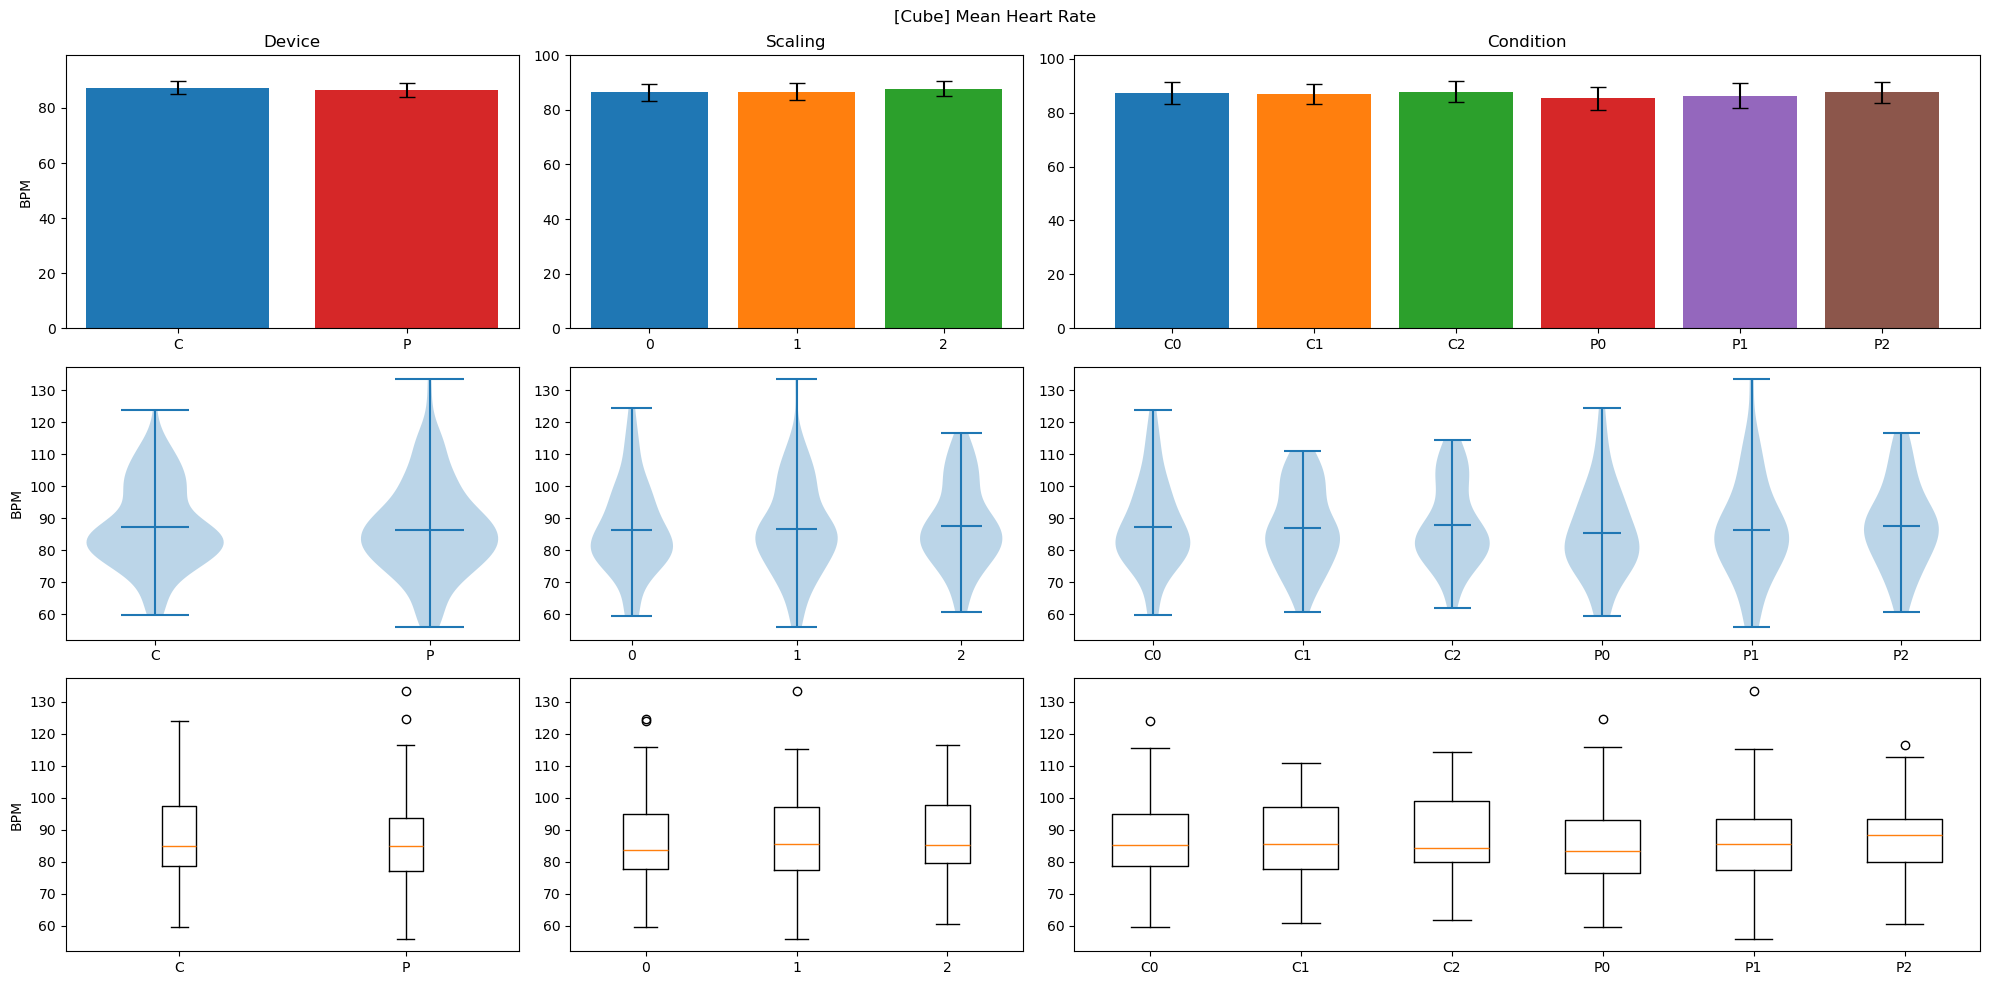

------ [Shovel] Mean Heart Rate: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,1.744598,1,41,1.744598,0.113003,0.738465,0.738465,0.000037,1.000000,❌
1,Scaling,74.331556,2,82,37.165778,4.254019,0.017466,0.020602,0.001555,0.913955,✅
2,Device * Scaling,2.362663,2,82,1.181332,0.115325,0.891221,0.865074,0.000049,0.871837,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-1.951651,41.0,two-sided,0.057834,0.115667,holm,0.934,-0.057982,❌
2,Scaling,-,0,2,True,True,-2.533125,41.0,two-sided,0.015226,0.045678,holm,2.802,-0.095011,✅
3,Scaling,-,1,2,True,True,-1.205087,41.0,two-sided,0.235079,0.235079,holm,0.327,-0.037449,❌


------ [Shovel] Mean Heart Rate: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,78.438817,5,15.687763,1.468927,0.201417,0.215989,0.001641,0.767913,False,0.477507,0.010899,❌
1,Error,2189.346944,205,10.679741,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


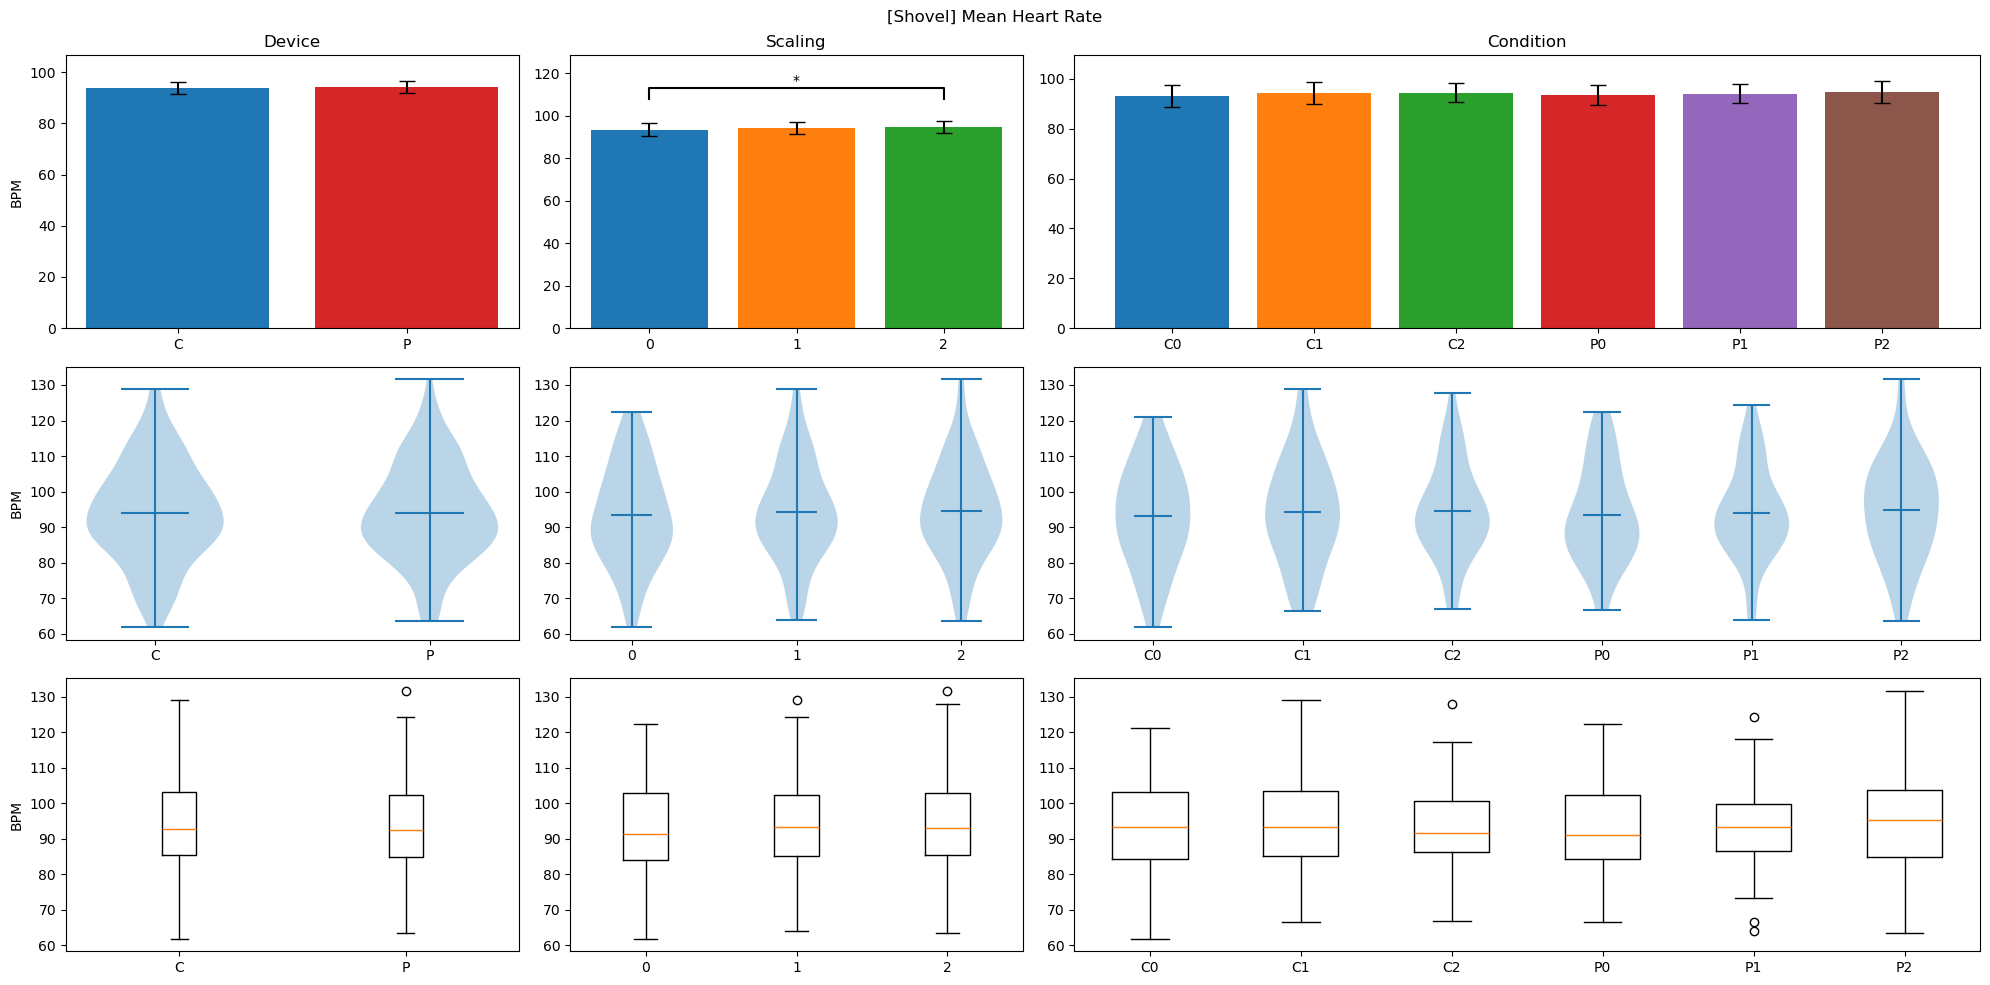

In [654]:
def hr_mean(p):
    return mean_val(p, hr_key)

title = 'Mean Heart Rate'
ylabel = 'BPM'
report_exeriment(data, hr_mean, cube, title, ylabel)
report_exeriment(data, hr_mean, shovel, title, ylabel)

------ [Cube] Peak Heart Rate: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,8.215278,1,41,8.215278,0.187465,0.667304,0.667304,0.000179,1.000000,❌
1,Scaling,174.018175,2,82,87.009087,1.990759,0.143139,0.144853,0.003768,0.966417,❌
2,Device * Scaling,49.475317,2,82,24.737659,0.478695,0.621312,0.601336,0.001074,0.899111,❌


------ [Cube] Peak Heart Rate: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,ng2,eps,Significance
0,Condition,231.70877,5,46.341754,0.987716,0.426271,0.005012,0.814236,❌
1,Error,9618.20623,205,46.918079,NaN,NaN,NaN,NaN,❌


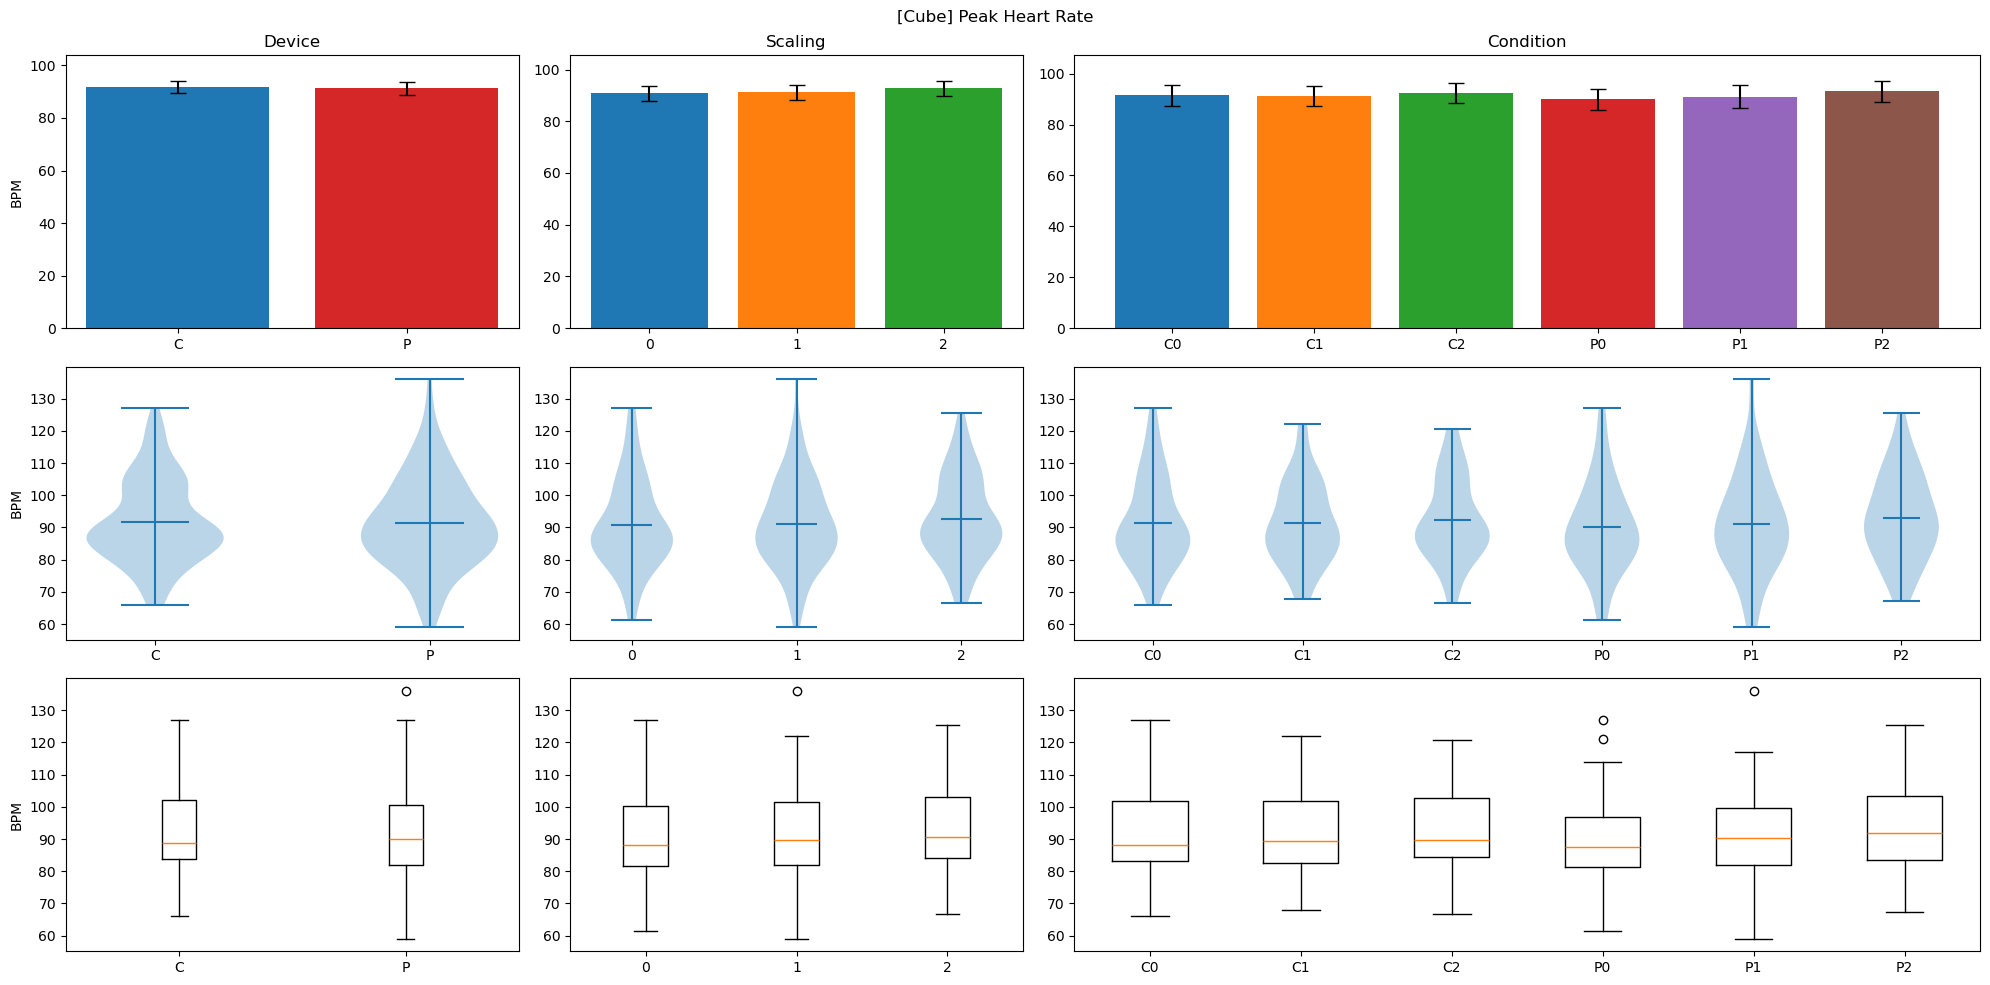

------ [Shovel] Peak Heart Rate: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,37.568611,1,41,37.568611,1.478322,0.230992,0.230992,0.000777,1.000000,❌
1,Scaling,31.637143,2,82,15.818571,1.094080,0.339685,0.334803,0.000654,0.897272,❌
2,Device * Scaling,8.735556,2,82,4.367778,0.349525,0.706068,0.659847,0.000181,0.805302,❌


------ [Shovel] Peak Heart Rate: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,77.94131,5,15.588262,0.98259,0.429407,0.418127,0.001611,0.791586,False,0.486248,0.01356,❌
1,Error,3252.21369,205,15.864457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


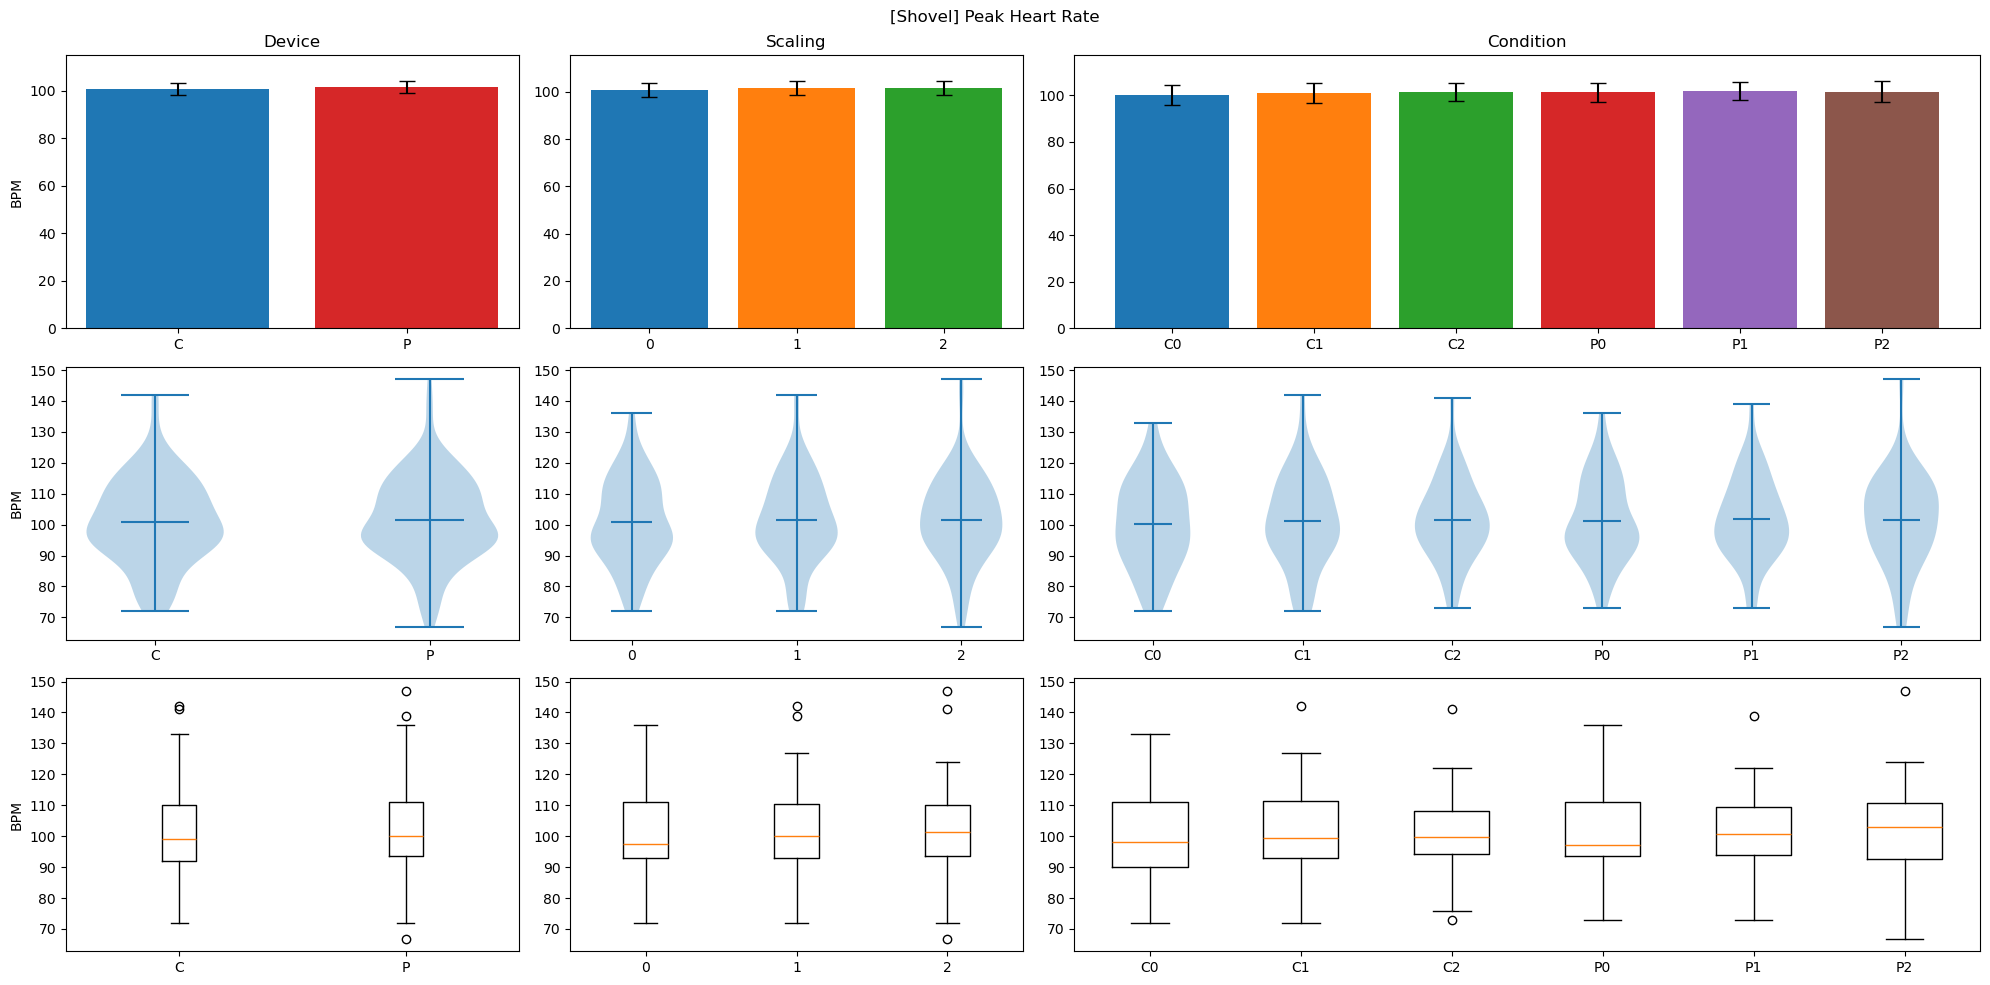

In [655]:
def hr_peak(p):
    return peak_val(p, hr_key)

title = 'Peak Heart Rate'
ylabel = 'BPM'
report_exeriment(data, hr_peak, cube, title, ylabel)
report_exeriment(data, hr_peak, shovel, title, ylabel)

------ [Cube] Heart Rate Delta: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,57.620040,1,41,57.620040,2.119090,0.153088,0.153088,0.006404,1.000000,❌
1,Scaling,56.204127,2,82,28.102063,1.053434,0.353409,0.352079,0.006248,0.974475,❌
2,Device * Scaling,0.748889,2,82,0.374444,0.017992,0.982172,0.965451,0.000084,0.809858,❌


------ [Cube] Heart Rate Delta: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,ng2,eps,Significance
0,Condition,114.573056,5,22.914611,0.937843,0.457445,0.012654,0.874215,❌
1,Error,5008.828611,205,24.433310,NaN,NaN,NaN,NaN,❌


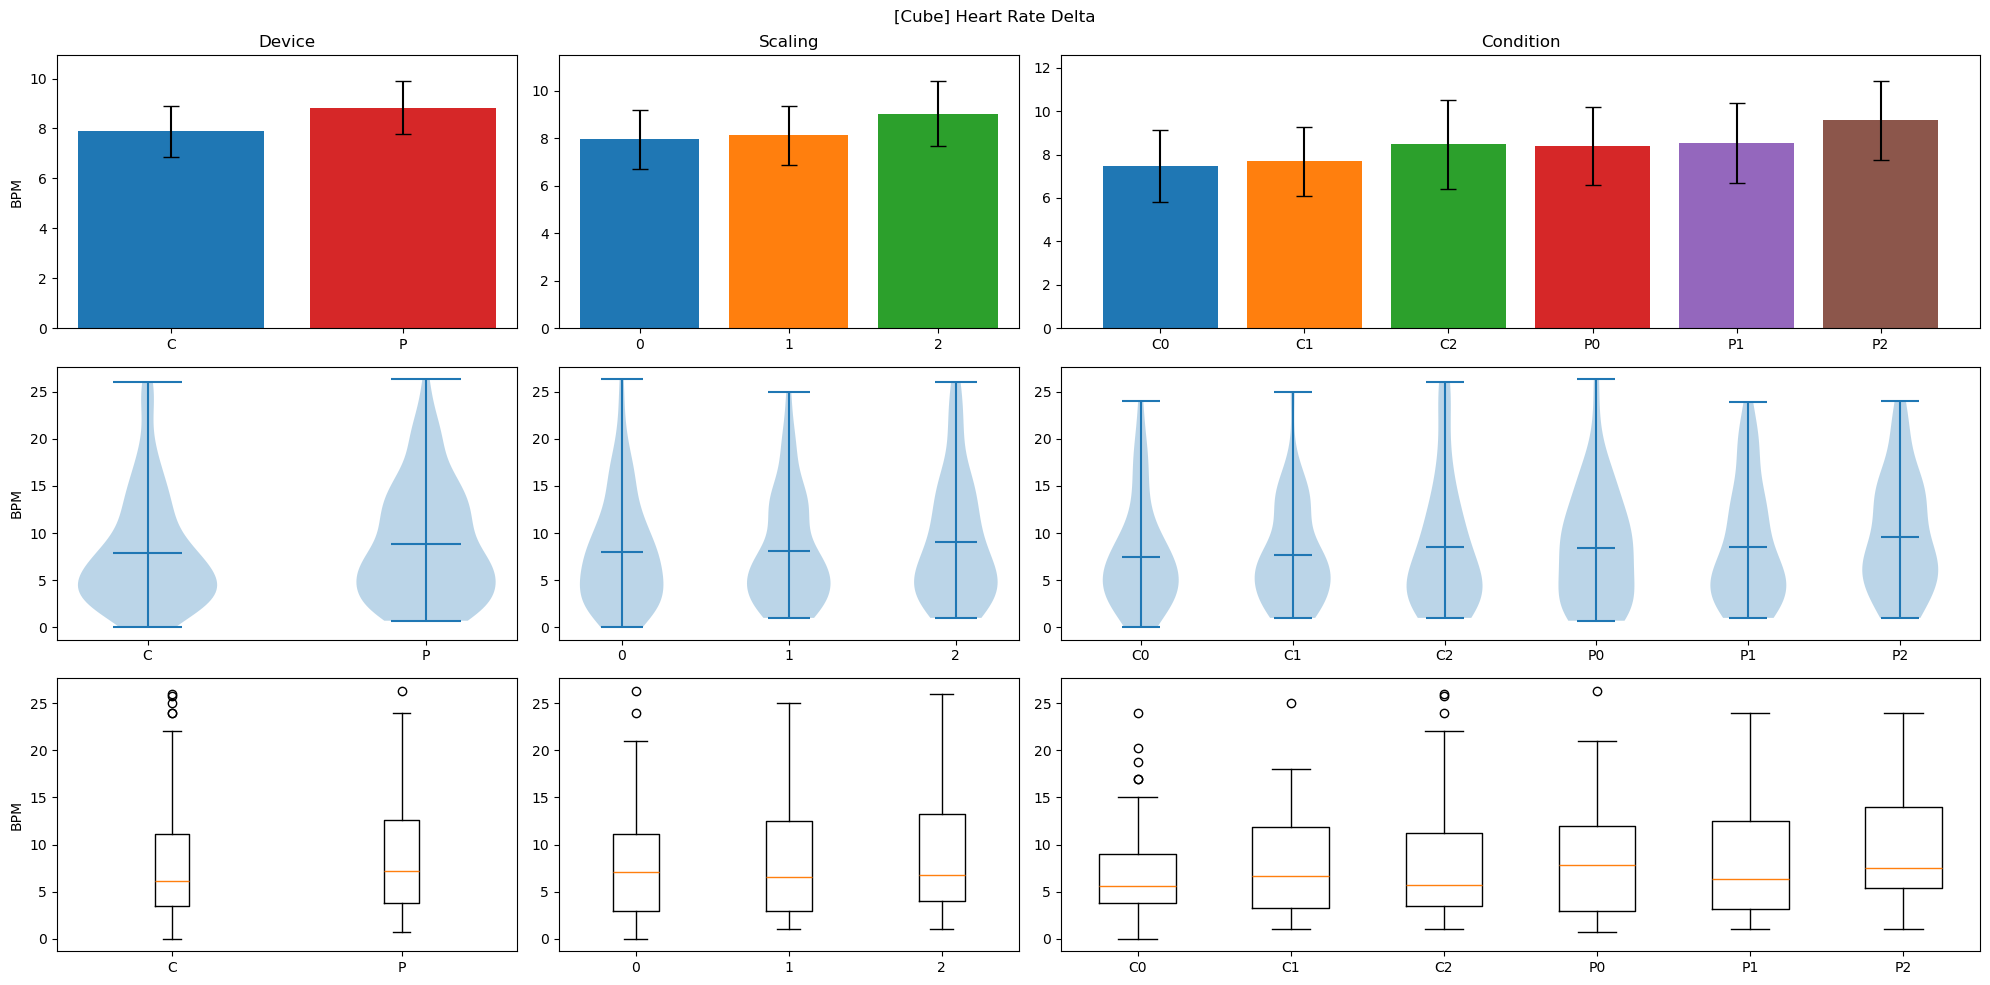

------ [Shovel] Heart Rate Delta: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,156.200635,1,41,156.200635,4.834828,0.033589,0.033589,0.012141,1.000000,✅
1,Scaling,57.386270,2,82,28.693135,1.416168,0.248513,0.248755,0.004495,0.959115,❌
2,Device * Scaling,77.773889,2,82,38.886944,1.392907,0.254166,0.254271,0.006082,0.966643,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.198824,41.0,two-sided,0.033589,NaN,NaN,1.449,-0.261467,✅


------ [Shovel] Heart Rate Delta: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,ng2,eps,Significance
0,Condition,291.360794,5,58.272159,2.264487,0.049416,0.022411,0.882066,✅
1,Error,5275.275873,205,25.733053,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,0.222602,41.0,two-sided,0.824951,1.000000,holm,0.171,0.036539,❌
1,Condition,C0,C2,True,True,0.104959,41.0,two-sided,0.916920,1.000000,holm,0.168,0.016538,❌
2,Condition,C0,P0,True,True,-0.842170,41.0,two-sided,0.404579,1.000000,holm,0.233,-0.140676,❌
3,Condition,C0,P1,True,True,-2.561132,41.0,two-sided,0.014210,0.198939,holm,2.971,-0.415852,❌
4,Condition,C0,P2,True,True,-0.341133,41.0,two-sided,0.734745,1.000000,holm,0.176,-0.059769,❌
5,Condition,C1,C2,True,True,-0.118789,41.0,two-sided,0.906023,1.000000,holm,0.168,-0.020042,❌
6,Condition,C1,P0,True,True,-1.160415,41.0,two-sided,0.252592,1.000000,holm,0.312,-0.175247,❌
7,Condition,C1,P1,True,True,-2.532388,41.0,two-sided,0.015253,0.198939,holm,2.798,-0.453768,❌
8,Condition,C1,P2,True,True,-0.671962,41.0,two-sided,0.505377,1.000000,holm,0.206,-0.093703,❌
9,Condition,C2,P0,True,True,-1.148211,41.0,two-sided,0.257537,1.000000,holm,0.308,-0.156464,❌


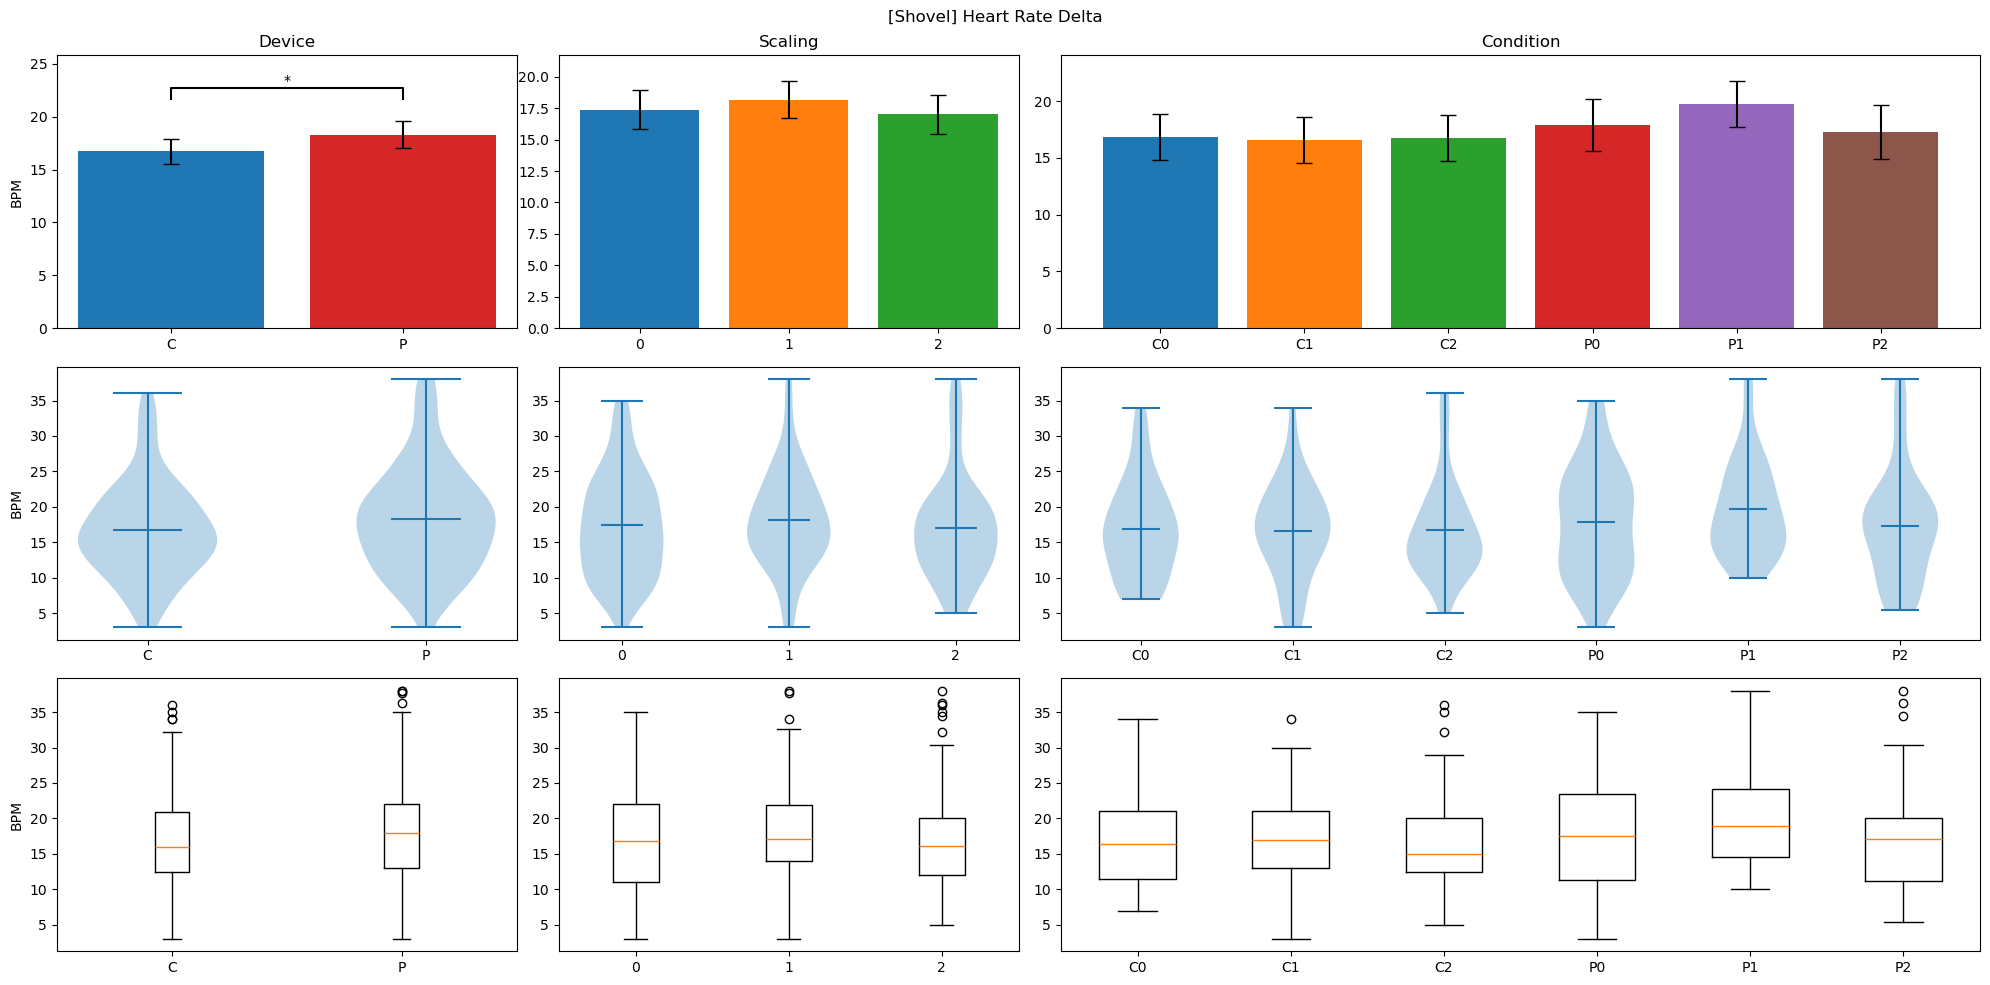

In [656]:
def hr_delta(p):
    return delta_val(p, hr_key)

title = 'Heart Rate Delta'
ylabel = 'BPM'
report_exeriment(data, hr_delta, cube, title, ylabel)
report_exeriment(data, hr_delta, shovel, title, ylabel)

------ [Cube] Heart Rate Normalized AUC: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,25.646150,1,41,25.646150,0.771243,0.384950,0.384950,0.000539,1.000000,❌
1,Scaling,120.876697,2,82,60.438348,1.506201,0.227821,0.230222,0.002534,0.809598,❌
2,Device * Scaling,30.375726,2,82,15.187863,0.299987,0.741637,0.710362,0.000638,0.866846,❌


------ [Cube] Heart Rate Normalized AUC: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,176.898573,5,35.379715,0.823694,0.534066,0.505271,0.003704,0.749107,False,0.46933,0.008828,❌
1,Error,8805.258455,205,42.952480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


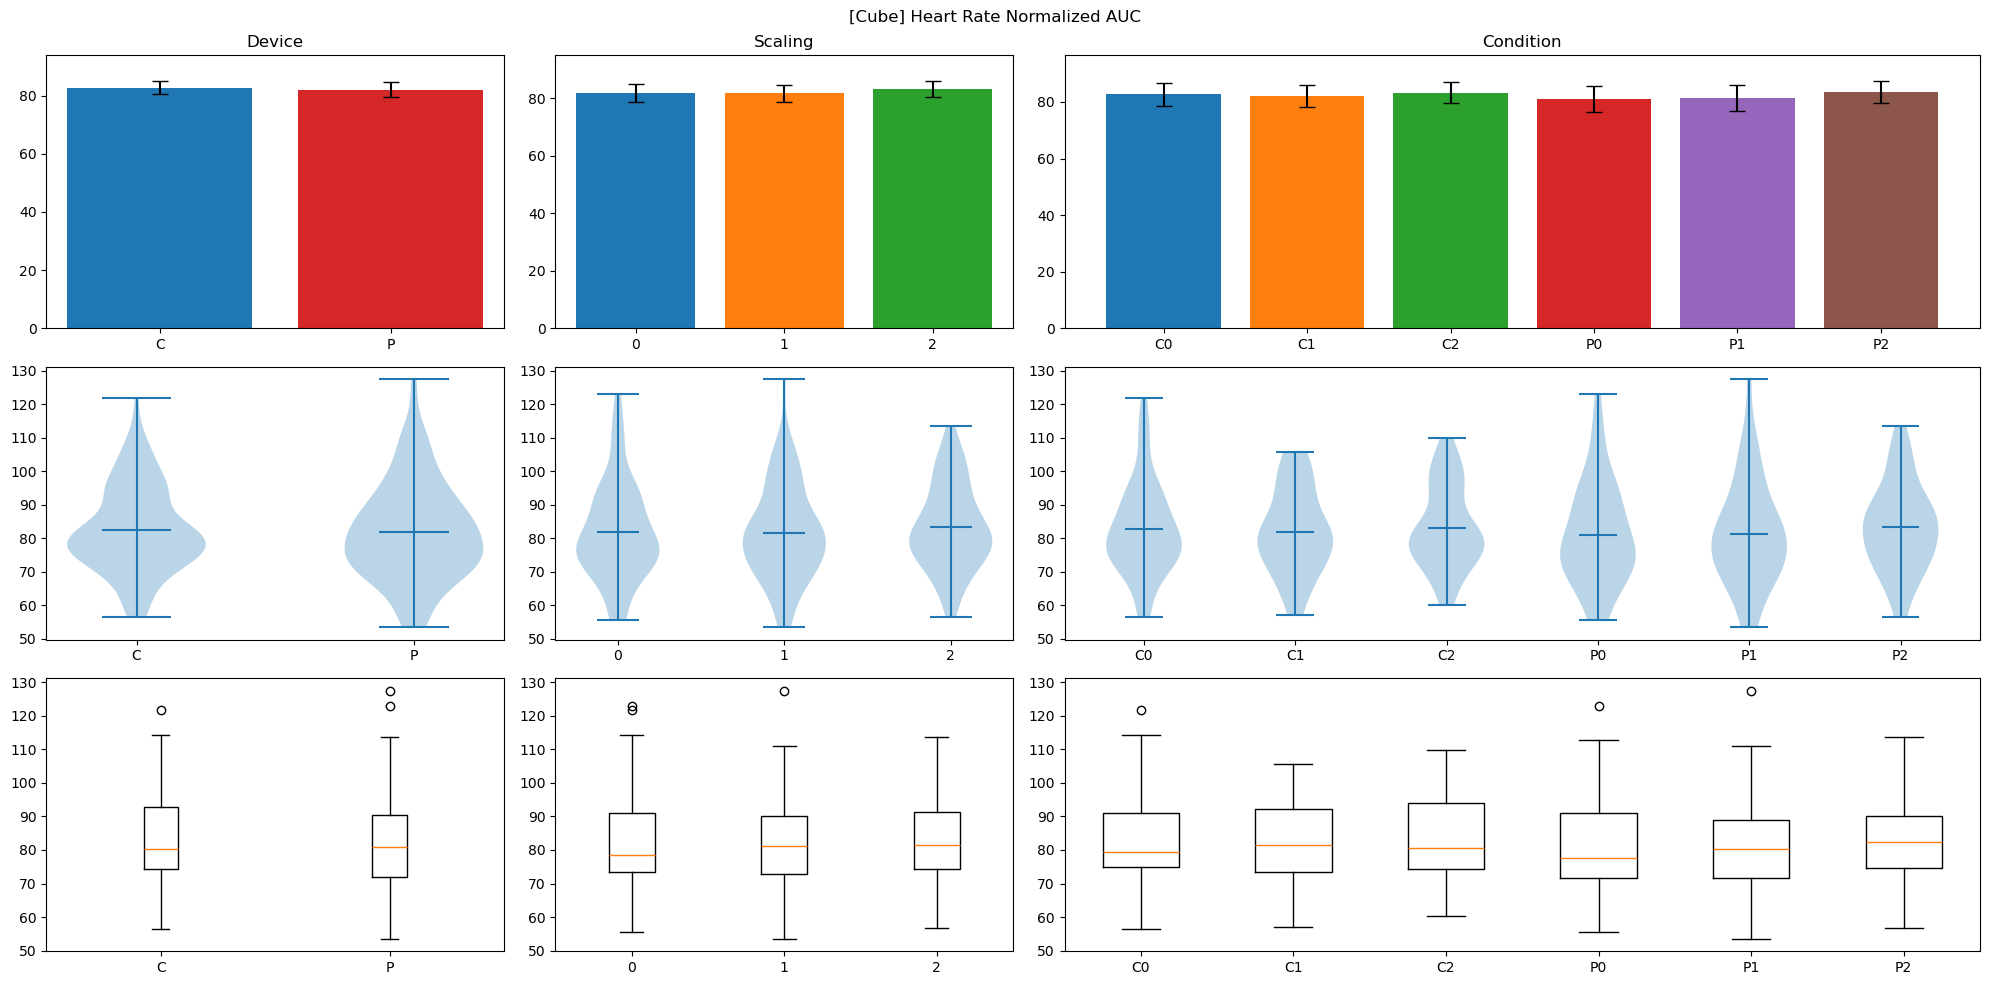

------ [Shovel] Heart Rate Normalized AUC: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,1.102022,1,41,1.102022,0.066596,0.797649,0.797649,0.000024,1.000000,❌
1,Scaling,109.839807,2,82,54.919904,6.426979,0.002553,0.003781,0.002338,0.889062,✅
2,Device * Scaling,5.830397,2,82,2.915199,0.286238,0.751831,0.724685,0.000124,0.883706,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.306186,41.0,two-sided,0.026231,0.052461,holm,1.777,-0.065309,🟨
2,Scaling,-,0,2,True,True,-3.092804,41.0,two-sided,0.003561,0.010683,holm,9.794,-0.117033,✅
3,Scaling,-,1,2,True,True,-1.658981,41.0,two-sided,0.104752,0.104752,holm,0.588,-0.052761,❌


------ [Shovel] Heart Rate Normalized AUC: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,116.772226,5,23.354445,2.16216,0.059641,0.078786,0.002485,0.764387,False,0.458654,0.006642,🟨
1,Error,2214.295767,205,10.801443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


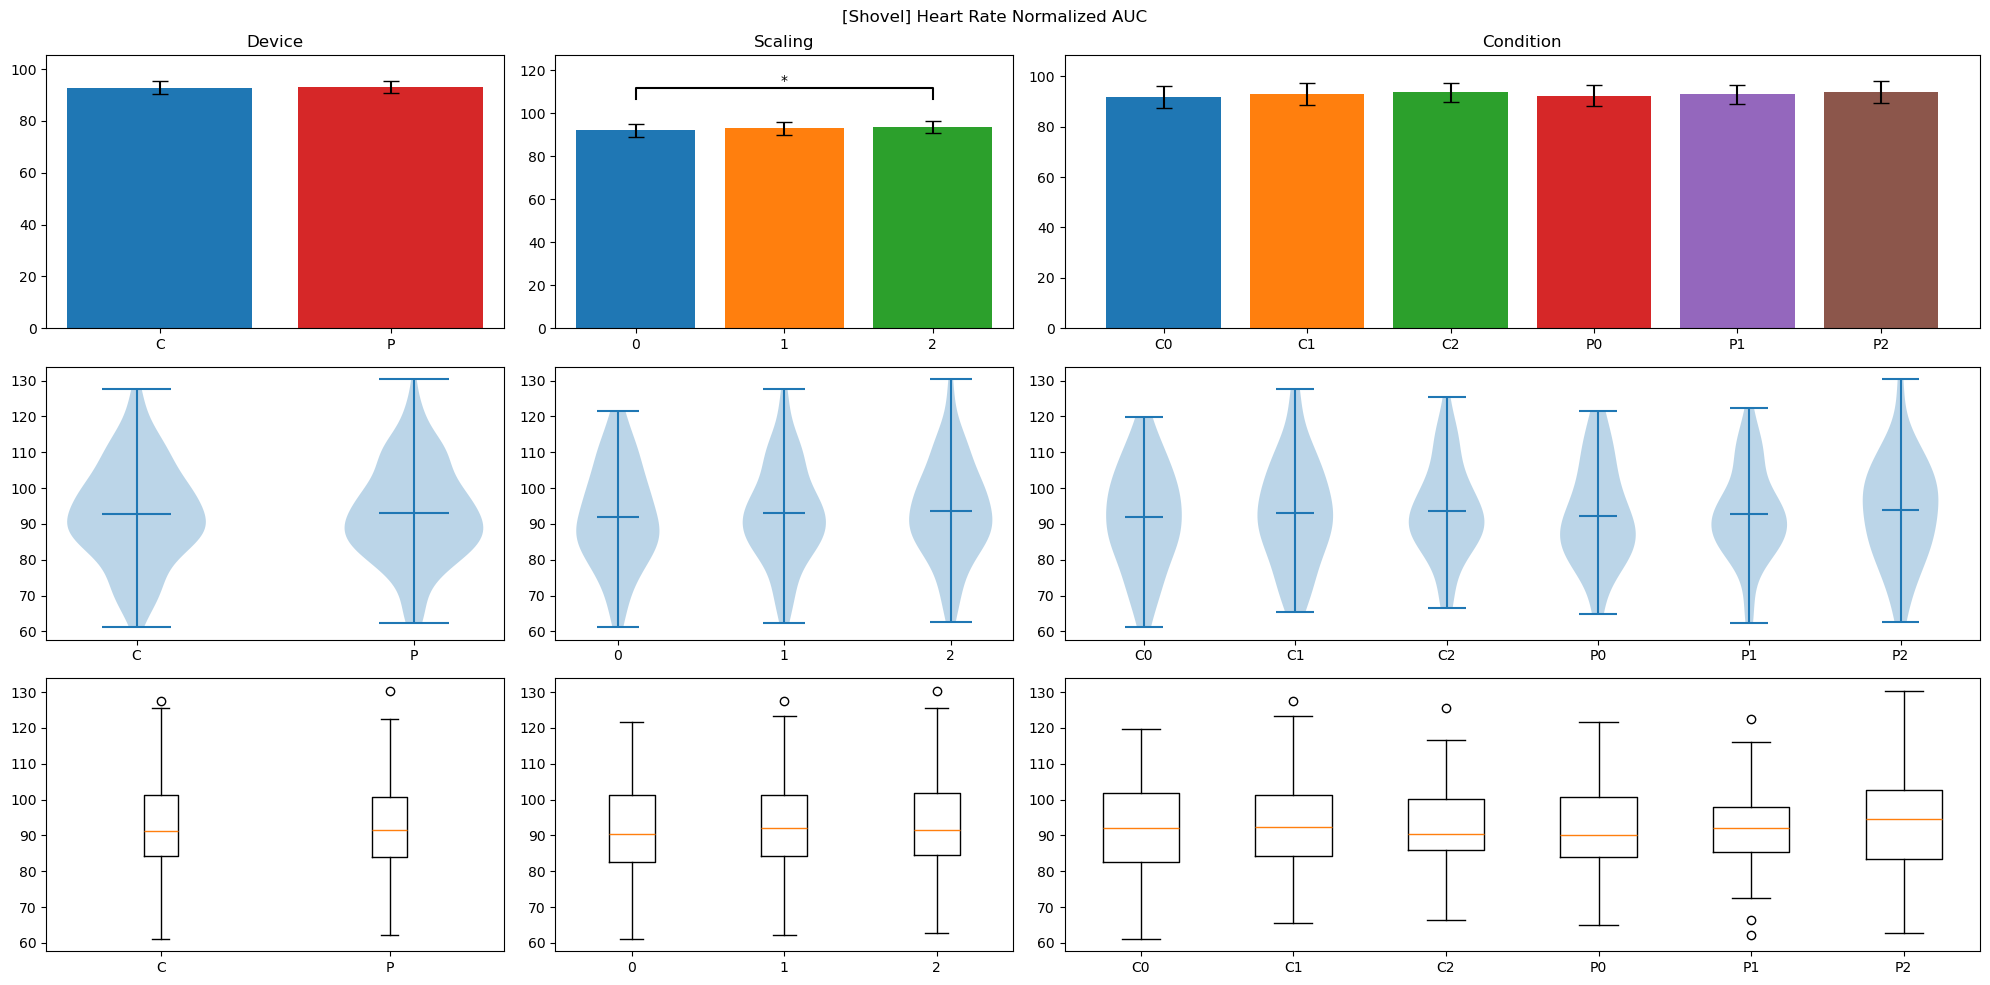

In [657]:
def hr_auc(p):
    return normalized_auc(p, hr_key)

title = 'Heart Rate Normalized AUC'
ylabel = ''
report_exeriment(data, hr_auc, cube, title, ylabel)
report_exeriment(data, hr_auc, shovel, title, ylabel)

------ [Cube] Mean Skin Conductance: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,9.795457,1,41,9.795457,2.968790,0.092421,0.092421,0.001540,1.000000,🟨
1,Scaling,11.349200,2,82,5.674600,1.343702,0.266561,0.260088,0.001784,0.629555,❌
2,Device * Scaling,19.859480,2,82,9.929740,3.044654,0.053029,0.077172,0.003117,0.639080,🟨


------ [Cube] Mean Skin Conductance: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,41.004137,5,8.200827,2.244535,0.051269,0.092099,0.006415,0.552342,False,0.027482,7.157897e-23,🟨
1,Error,749.005718,205,3.653686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


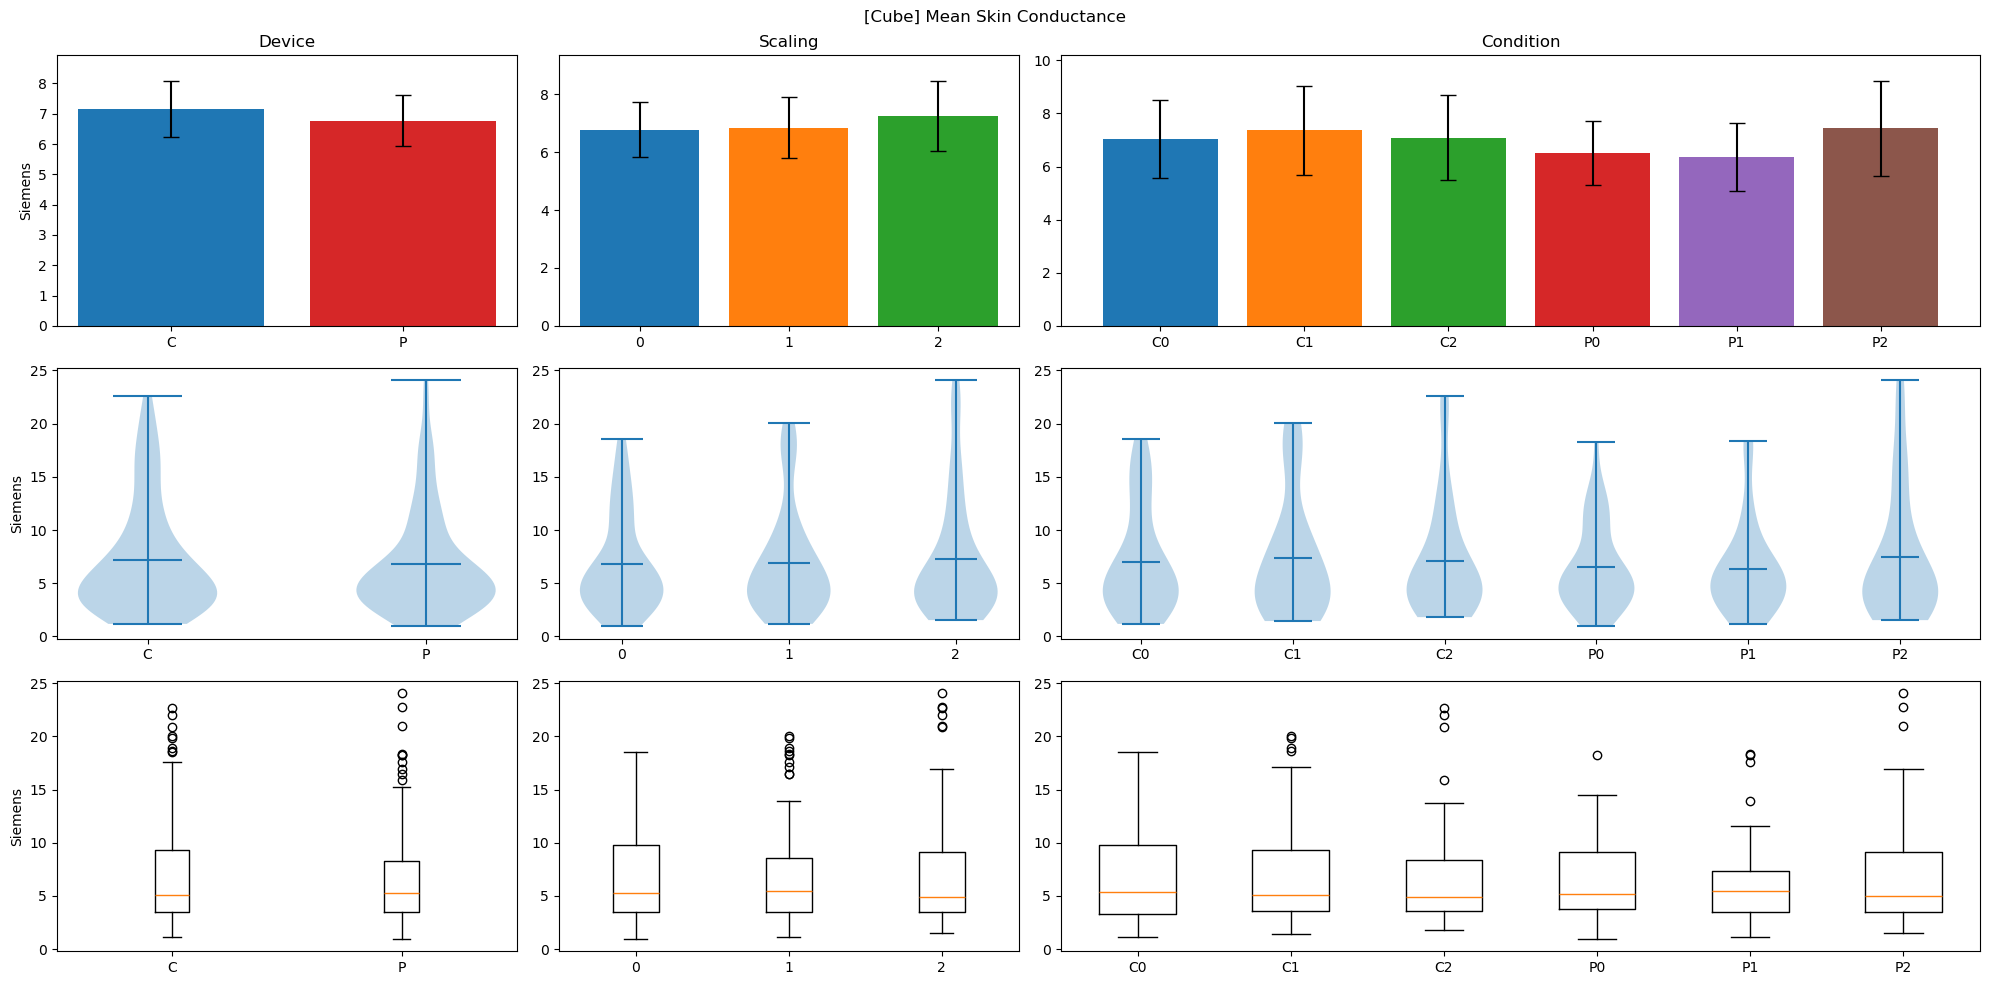

------ [Shovel] Mean Skin Conductance: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.553842,1,41,0.553842,0.354366,0.554924,0.554924,0.000055,1.000000,❌
1,Scaling,0.099651,2,82,0.049825,0.049382,0.951846,0.882025,0.000010,0.646207,❌
2,Device * Scaling,2.886870,2,82,1.443435,1.189137,0.309679,0.288961,0.000285,0.574847,❌


------ [Shovel] Mean Skin Conductance: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,3.540363,5,0.708073,0.589219,0.708242,0.603562,0.00035,0.532374,False,0.052474,6.383811e-18,❌
1,Error,246.351182,205,1.201713,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


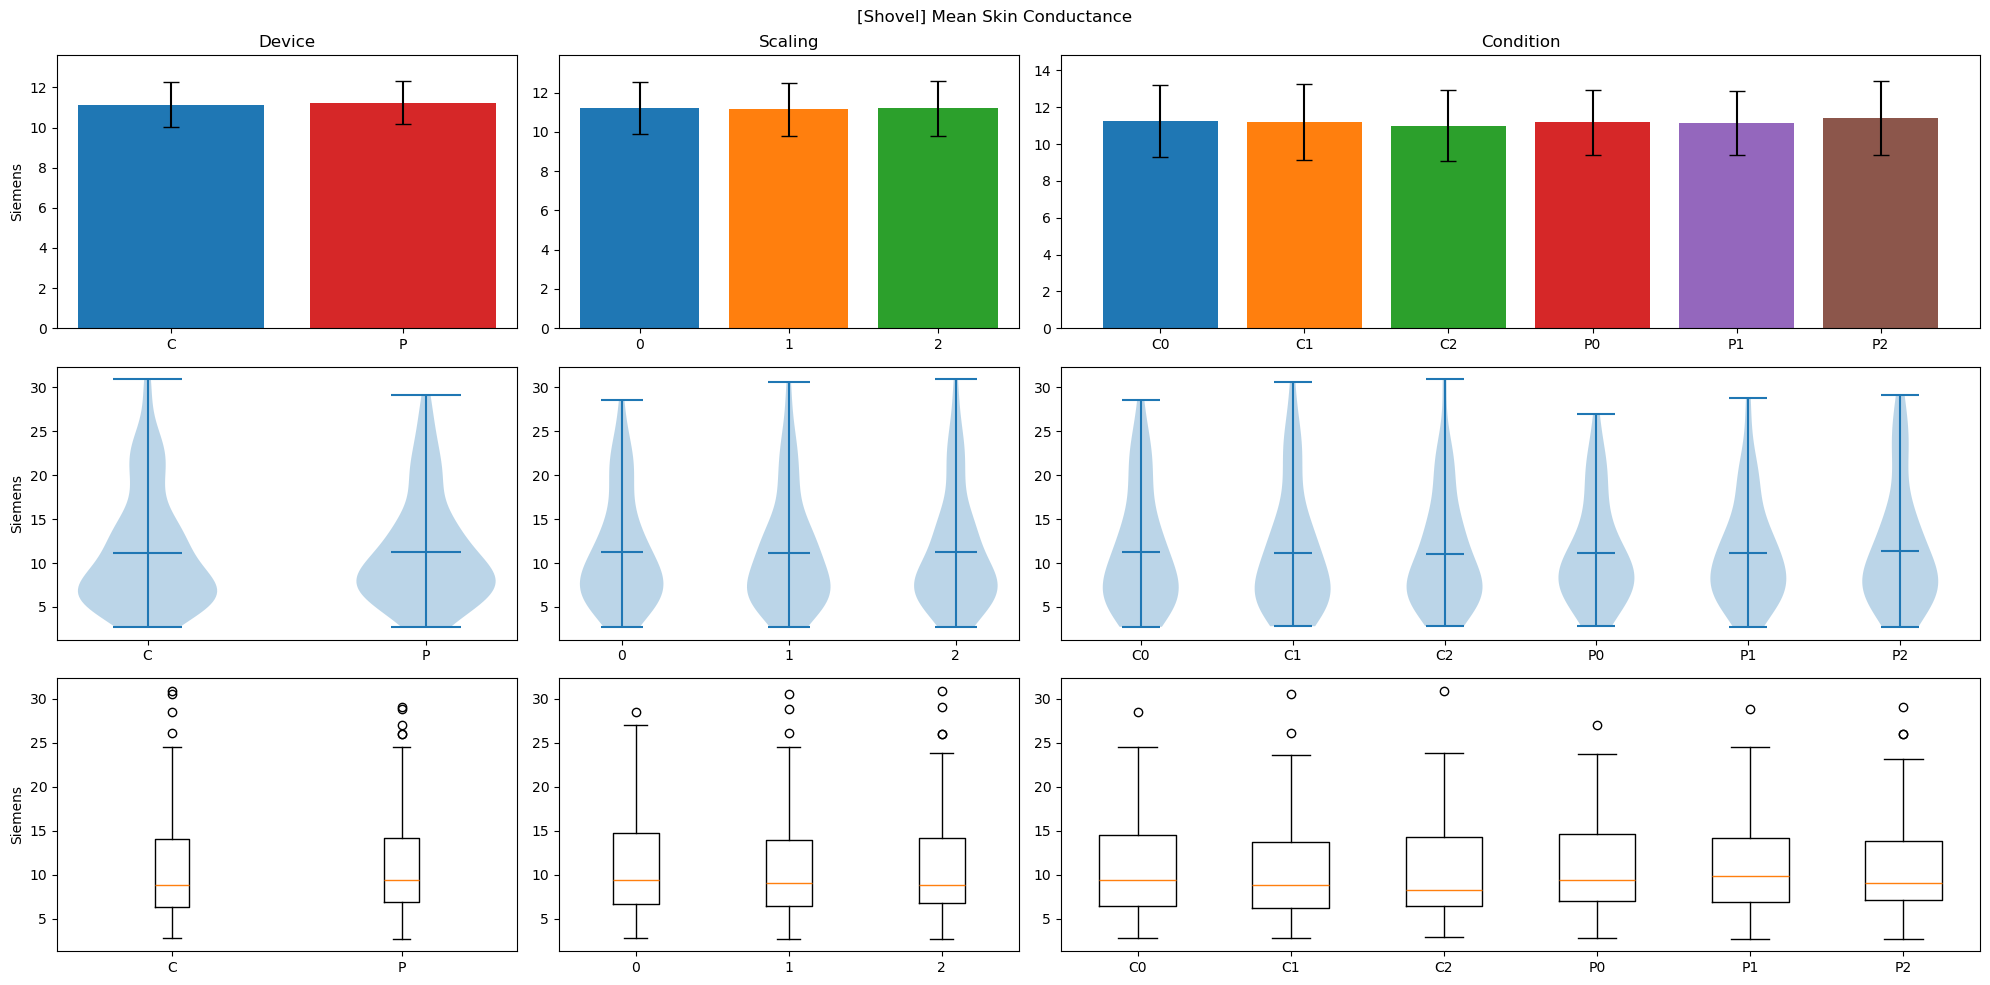

In [658]:
def gsr_con_mean(p):
    return mean_val(p, gsr_con_key)

title = 'Mean Skin Conductance'
ylabel = 'Siemens'
report_exeriment(data, gsr_con_mean, cube, title, ylabel)
report_exeriment(data, gsr_con_mean, shovel, title, ylabel)

------ [Cube] Peak Skin Conductance: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,3.568752,1,41,3.568752,1.232539,0.273383,0.273383,0.000525,1.000000,❌
1,Scaling,15.740759,2,82,7.870379,1.733870,0.183011,0.194325,0.002311,0.620245,❌
2,Device * Scaling,20.084506,2,82,10.042253,2.989213,0.055840,0.076141,0.002947,0.691073,🟨


------ [Cube] Peak Skin Conductance: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,39.394017,5,7.878803,2.107439,0.065905,0.109397,0.005763,0.543585,False,0.031757,9.315702e-22,❌
1,Error,766.406428,205,3.738568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


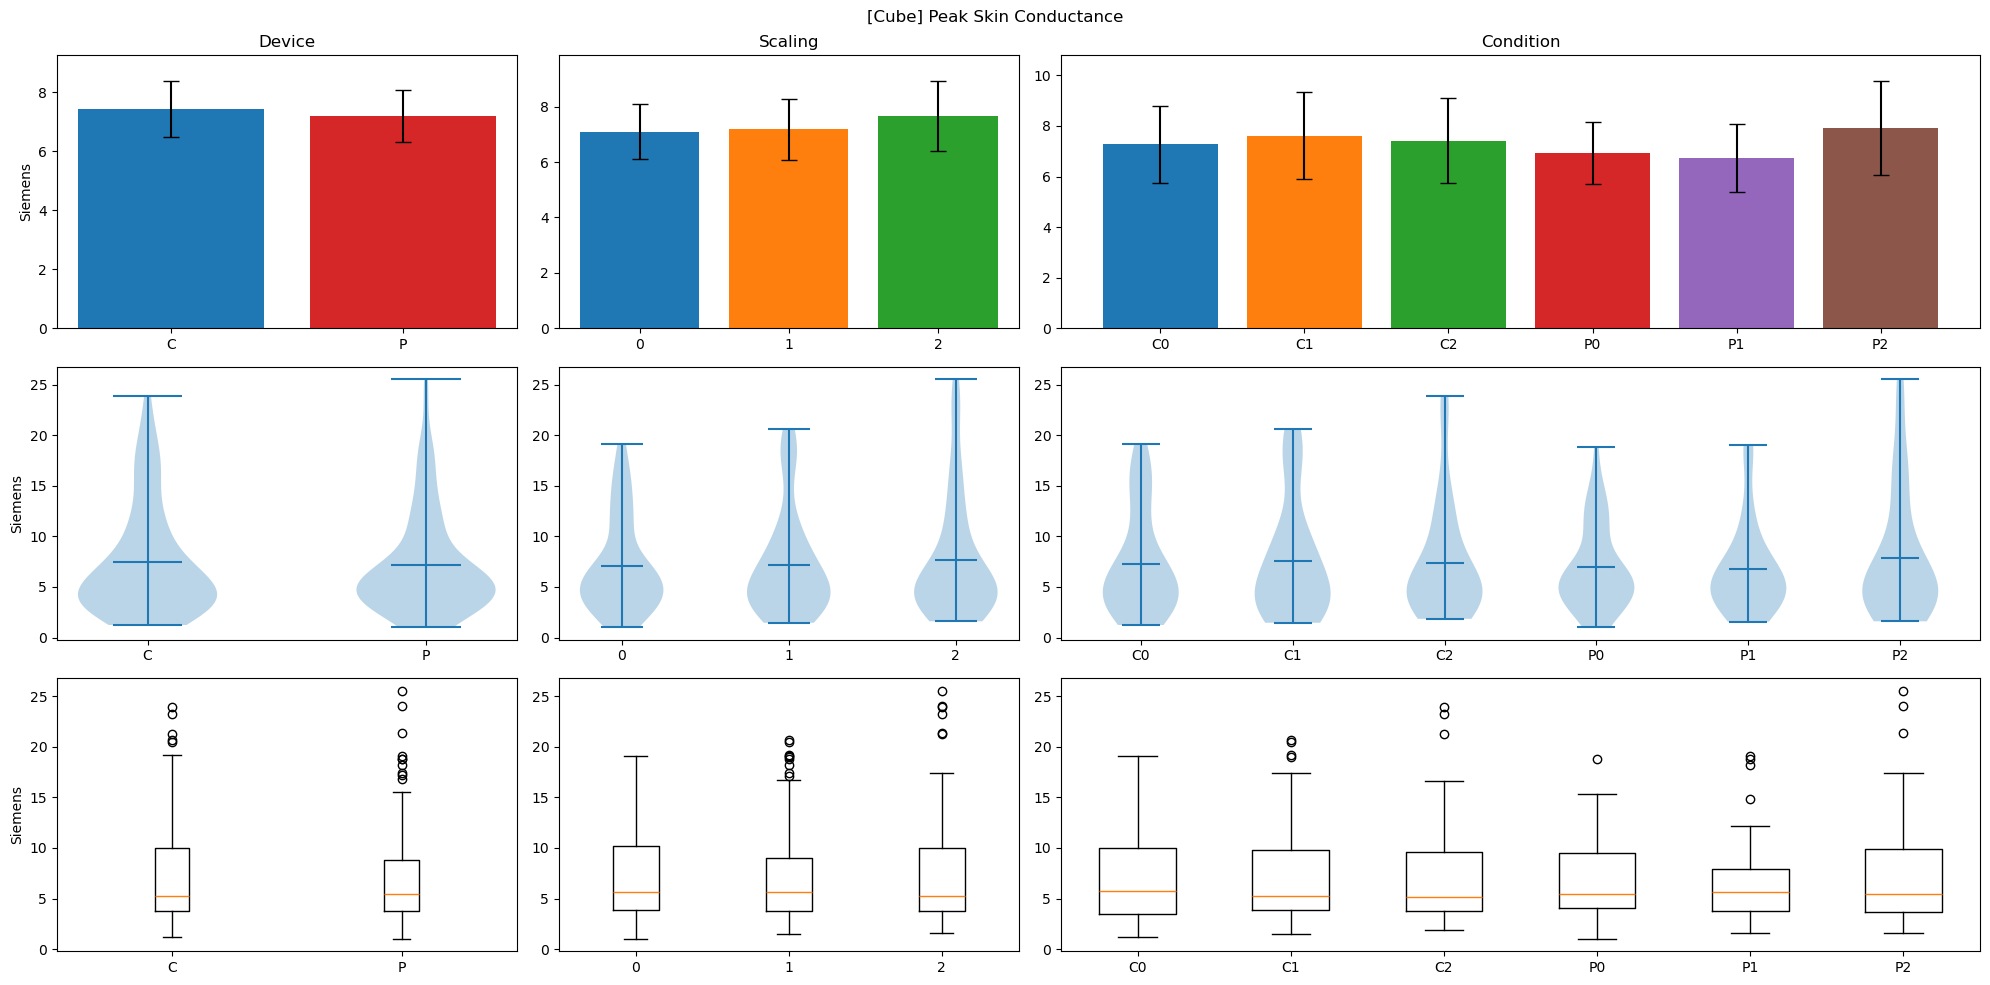

------ [Shovel] Peak Skin Conductance: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,2.431900,1,41,2.431900,1.582693,0.215491,0.215491,0.000220,1.000000,❌
1,Scaling,0.064584,2,82,0.032292,0.027164,0.973210,0.934738,0.000006,0.712520,❌
2,Device * Scaling,2.400484,2,82,1.200242,0.859115,0.427313,0.377138,0.000217,0.595581,❌


------ [Shovel] Peak Skin Conductance: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,4.896967,5,0.979393,0.729996,0.601686,0.53139,0.000442,0.578522,False,0.096218,2.180652e-13,❌
1,Error,275.036817,205,1.341643,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


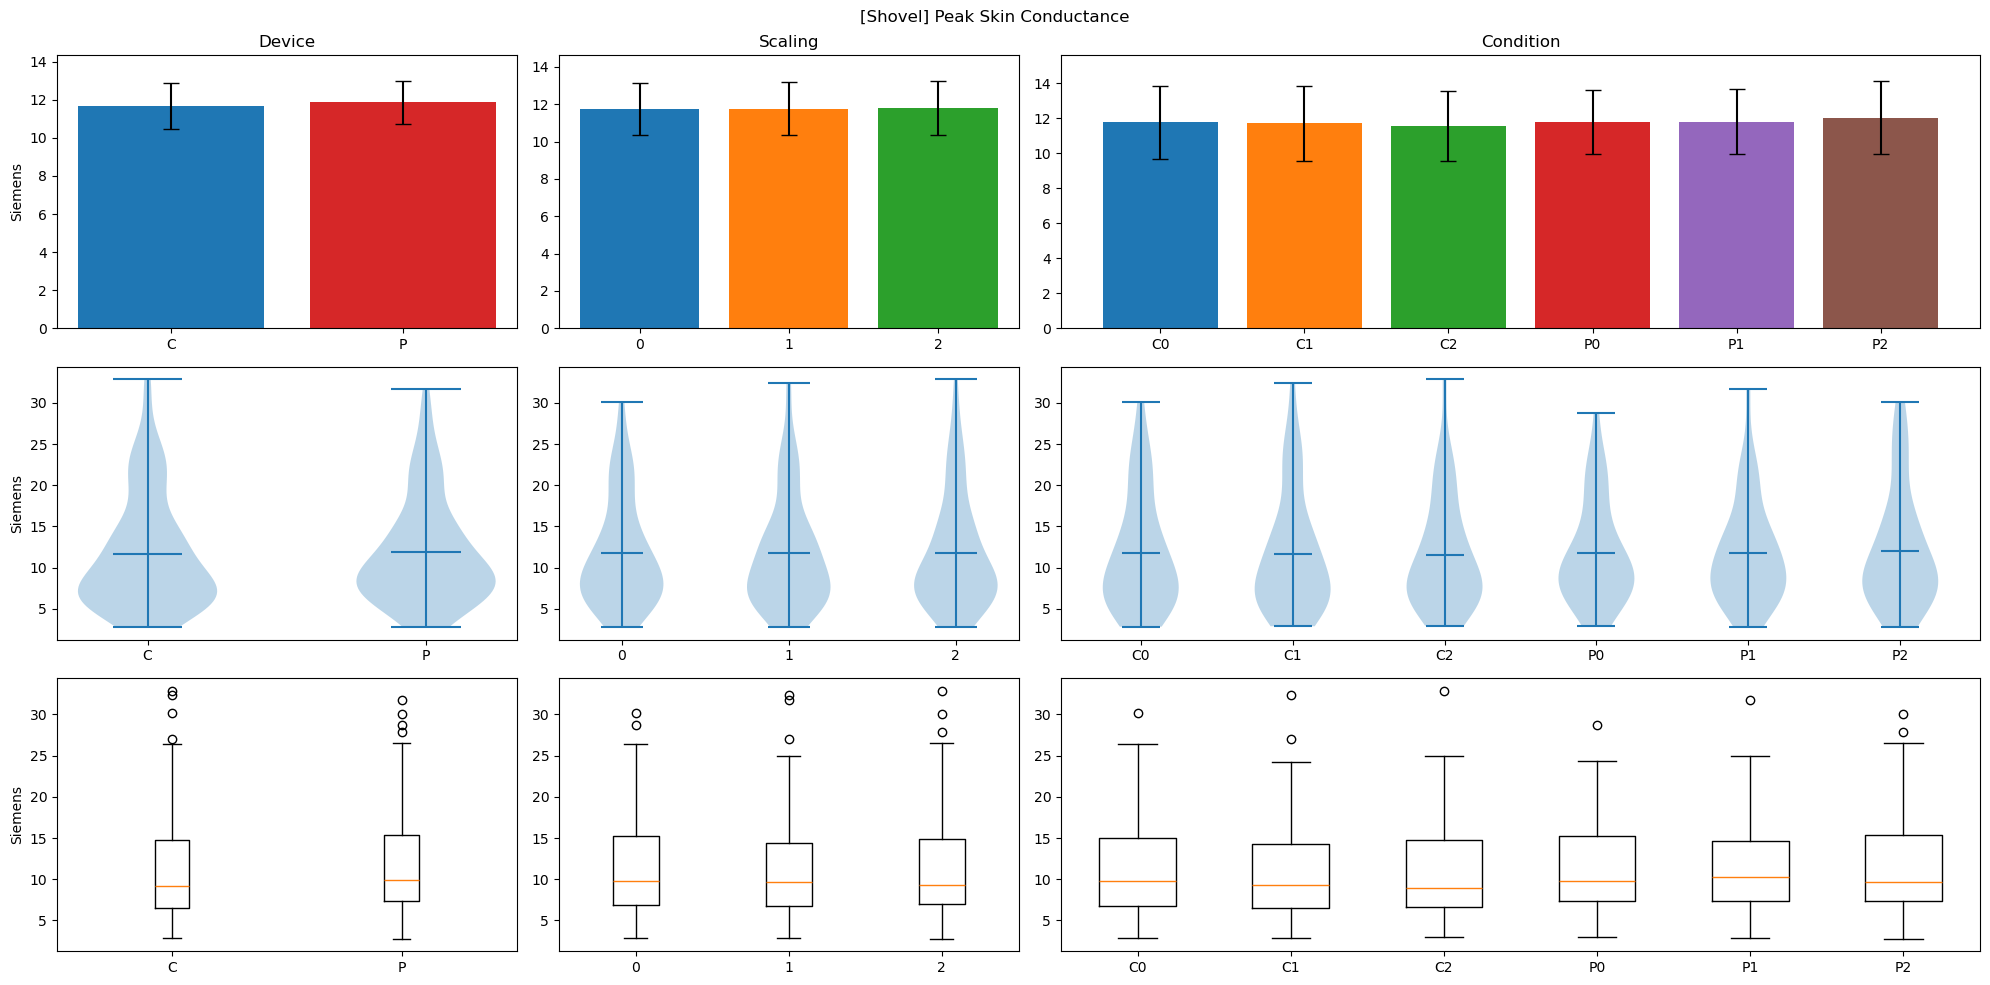

In [659]:
def gsr_con_peak(p):
    return peak_val(p, gsr_con_key)

title = 'Peak Skin Conductance'
ylabel = 'Siemens'
report_exeriment(data, gsr_con_peak, cube, title, ylabel)
report_exeriment(data, gsr_con_peak, shovel, title, ylabel)

------ [Cube] Skin Conductance Delta: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,5.734525,1,41,5.734525,13.064400,0.000815,0.000815,0.051081,1.000000,✅
1,Scaling,1.322656,2,82,0.661328,4.581205,0.012999,0.024303,0.012264,0.711015,✅
2,Device * Scaling,0.151884,2,82,0.075942,0.503197,0.606449,0.551287,0.001424,0.737726,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.614471,41.0,two-sided,0.000815,NaN,NaN,36.108,-0.516777,✅
1,Scaling,-,0,1,True,True,0.242766,41.0,two-sided,0.809397,0.809397,holm,0.172,0.019148,❌
2,Scaling,-,0,2,True,True,-2.075600,41.0,two-sided,0.044243,0.088487,holm,1.158,-0.249575,🟨
3,Scaling,-,1,2,True,True,-2.575428,41.0,two-sided,0.013716,0.041147,holm,3.061,-0.261456,✅


------ [Cube] Skin Conductance Delta: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,7.209065,5,1.441813,7.002534,0.000005,0.00025,0.063384,0.585913,False,0.103114,7.033102e-13,✅
1,Error,42.209241,205,0.205899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-0.476517,41.0,two-sided,0.636236,1.000000,holm,0.186,-0.063947,❌
1,Condition,C0,C2,True,True,-1.884456,41.0,two-sided,0.066606,0.432935,holm,0.835,-0.316143,❌
2,Condition,C0,P0,True,True,-3.364786,41.0,two-sided,0.001672,0.016720,holm,19.055,-0.623269,✅
3,Condition,C0,P1,True,True,-3.833651,41.0,two-sided,0.000427,0.005545,holm,64.544,-0.610007,✅
4,Condition,C0,P2,True,True,-4.995287,41.0,two-sided,0.000011,0.000171,holm,1764.426,-0.783110,✅
5,Condition,C1,C2,True,True,-2.114961,41.0,two-sided,0.040556,0.365007,holm,1.242,-0.269409,❌
6,Condition,C1,P0,True,True,-3.663740,41.0,two-sided,0.000706,0.008467,holm,41.081,-0.554140,✅
7,Condition,C1,P1,True,True,-3.438492,41.0,two-sided,0.001356,0.014911,holm,22.951,-0.531785,✅
8,Condition,C1,P2,True,True,-4.483821,41.0,two-sided,0.000058,0.000812,holm,395.227,-0.705156,✅
9,Condition,C2,P0,True,True,-1.133426,41.0,two-sided,0.263620,1.000000,holm,0.303,-0.188133,❌


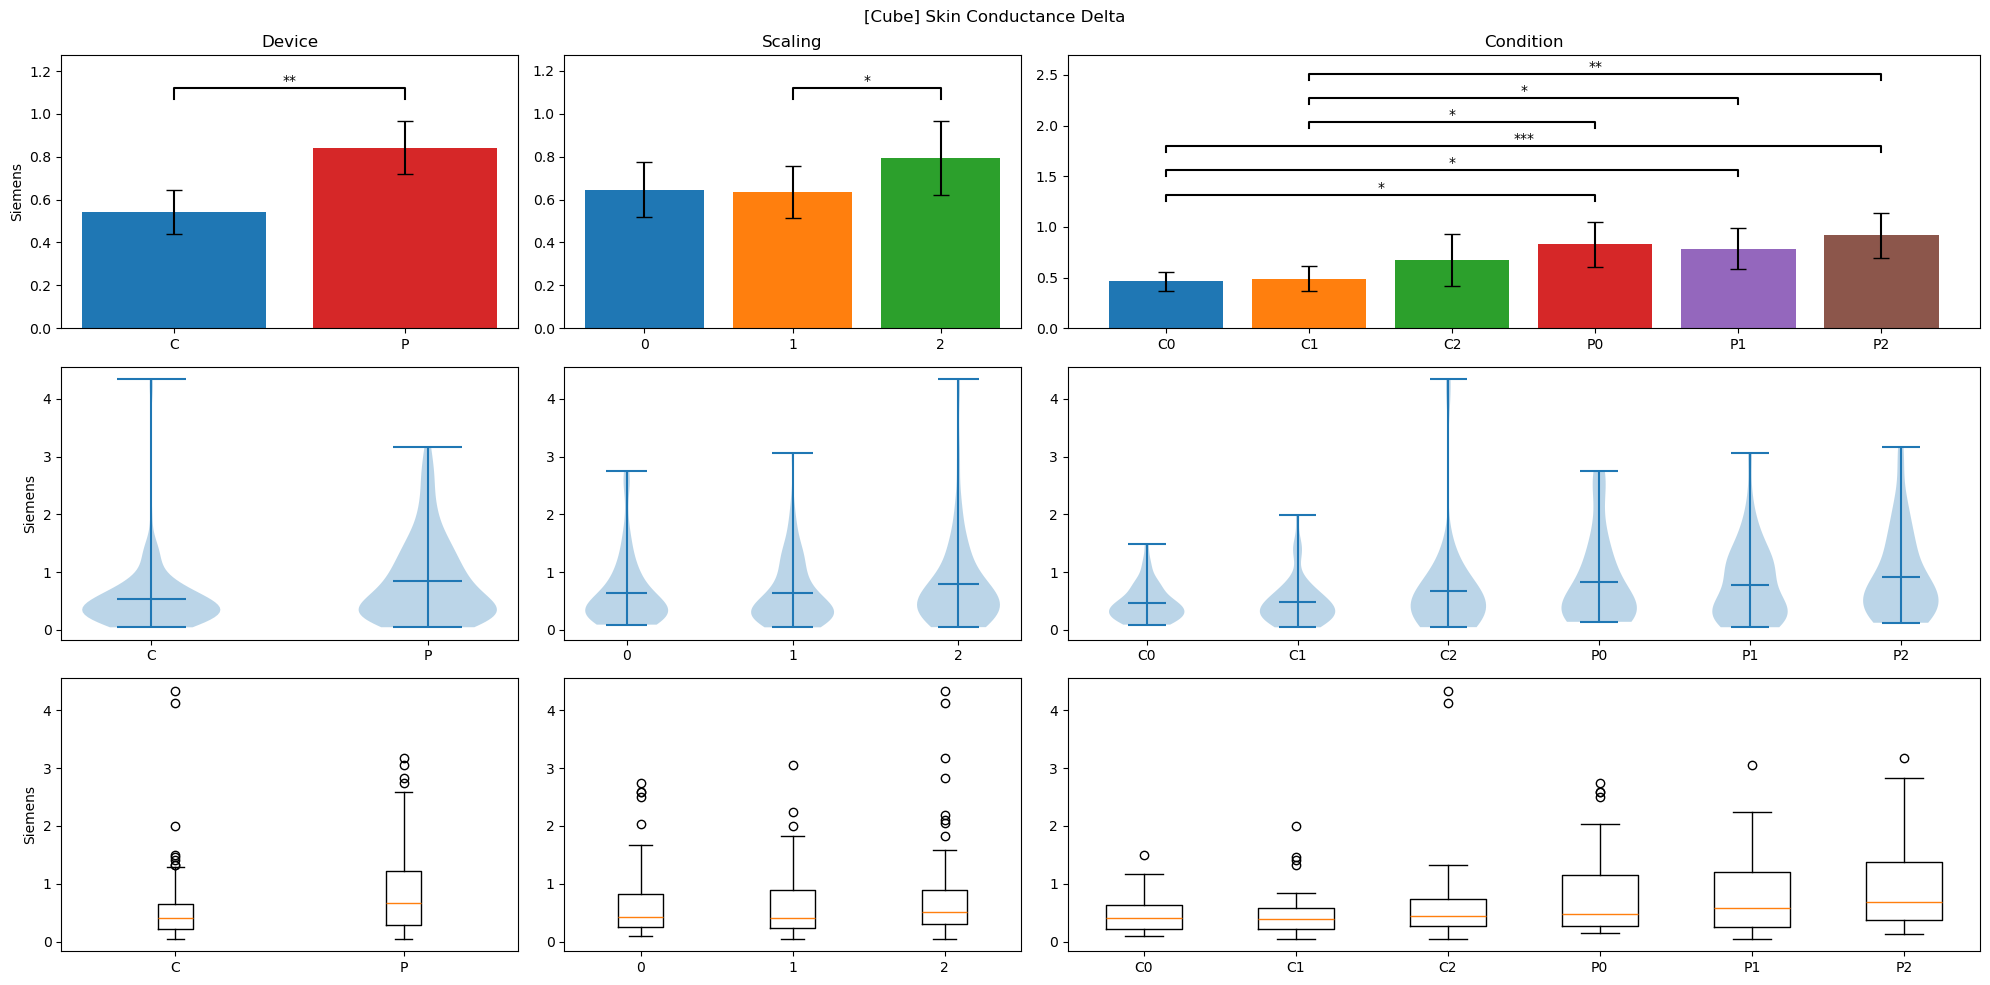

------ [Shovel] Skin Conductance Delta: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,2.423546,1,41,2.423546,23.155965,0.000020,0.000020,0.014048,1.000000,✅
1,Scaling,0.134314,2,82,0.067157,0.309080,0.734974,0.720084,0.000789,0.933678,❌
2,Device * Scaling,0.130751,2,82,0.065375,0.347650,0.707382,0.689469,0.000768,0.919270,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-4.812065,41.0,two-sided,0.00002,NaN,NaN,1026.593,-0.260542,✅


------ [Shovel] Skin Conductance Delta: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,2.688612,5,0.537722,2.937336,0.013884,0.024838,0.01556,0.754156,False,0.418444,0.002051,✅
1,Error,37.528249,205,0.183065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-0.013918,41.0,two-sided,0.988963,1.000000,holm,0.167,-0.001434,❌
1,Condition,C0,C2,True,True,-0.771517,41.0,two-sided,0.444825,1.000000,holm,0.221,-0.094411,❌
2,Condition,C0,P0,True,True,-2.243036,41.0,two-sided,0.030362,0.364341,holm,1.574,-0.258658,❌
3,Condition,C0,P1,True,True,-2.666933,41.0,two-sided,0.010907,0.141794,holm,3.72,-0.296029,❌
4,Condition,C0,P2,True,True,-3.242906,41.0,two-sided,0.002355,0.035321,holm,14.082,-0.290816,✅
5,Condition,C1,C2,True,True,-0.660830,41.0,two-sided,0.512418,1.000000,holm,0.205,-0.092786,❌
6,Condition,C1,P0,True,True,-2.124789,41.0,two-sided,0.039679,0.396788,holm,1.265,-0.255727,❌
7,Condition,C1,P1,True,True,-2.884906,41.0,two-sided,0.006215,0.087010,holm,6.032,-0.293442,🟨
8,Condition,C1,P2,True,True,-2.223420,41.0,two-sided,0.031758,0.364341,holm,1.517,-0.287813,❌
9,Condition,C2,P0,True,True,-1.109203,41.0,two-sided,0.273806,1.000000,holm,0.296,-0.126408,❌


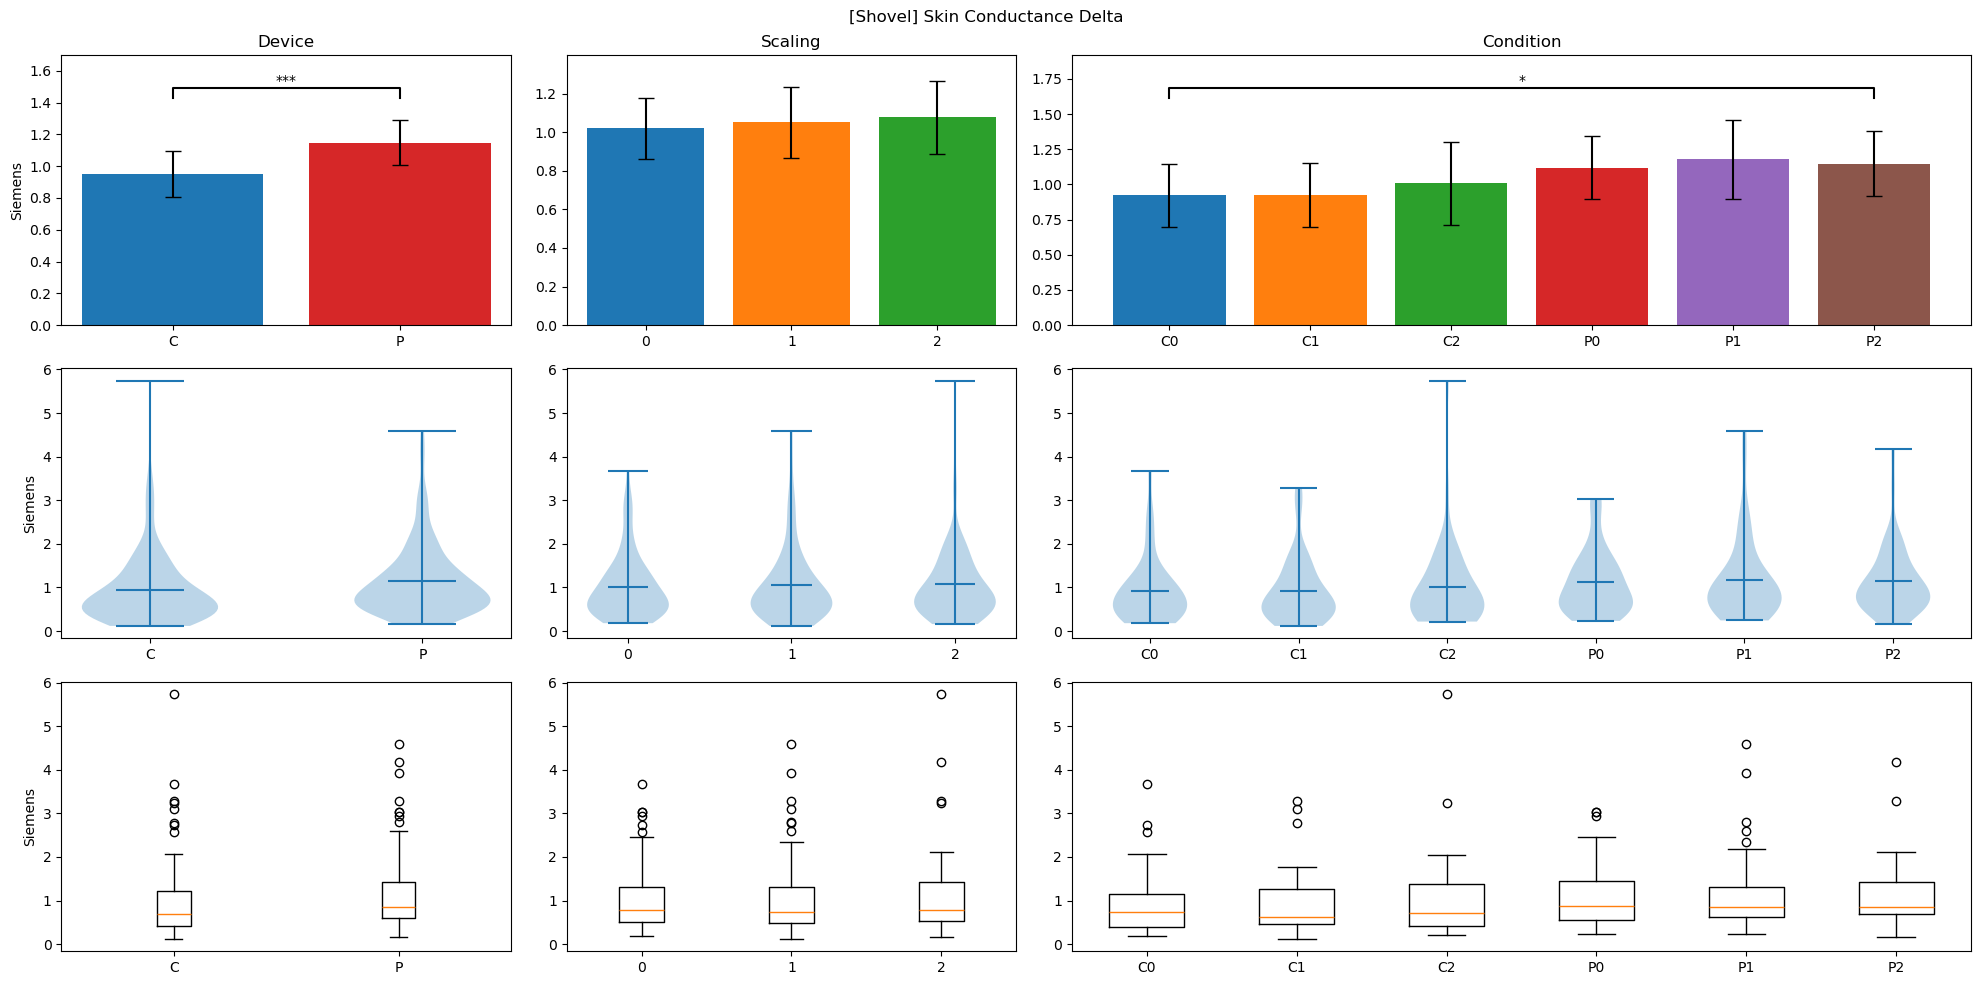

In [660]:
def gsr_con_delta(p):
    return delta_val(p, gsr_con_key)

title = 'Skin Conductance Delta'
ylabel = 'Siemens'
report_exeriment(data, gsr_con_delta, cube, title, ylabel)
report_exeriment(data, gsr_con_delta, shovel, title, ylabel)

------ [Cube] Skin Conductance Normalized AUC: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,9.765031,1,41,9.765031,2.965431,0.092599,0.092599,0.001537,1.000000,🟨
1,Scaling,11.354241,2,82,5.677120,1.345760,0.266030,0.259679,0.001786,0.629590,❌
2,Device * Scaling,19.842592,2,82,9.921296,3.046500,0.052938,0.077062,0.003118,0.639251,🟨


------ [Cube] Skin Conductance Normalized AUC: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,40.961864,5,8.192373,2.245317,0.051195,0.092001,0.006415,0.552444,False,0.0275,7.241178e-23,🟨
1,Error,747.973111,205,3.648649,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


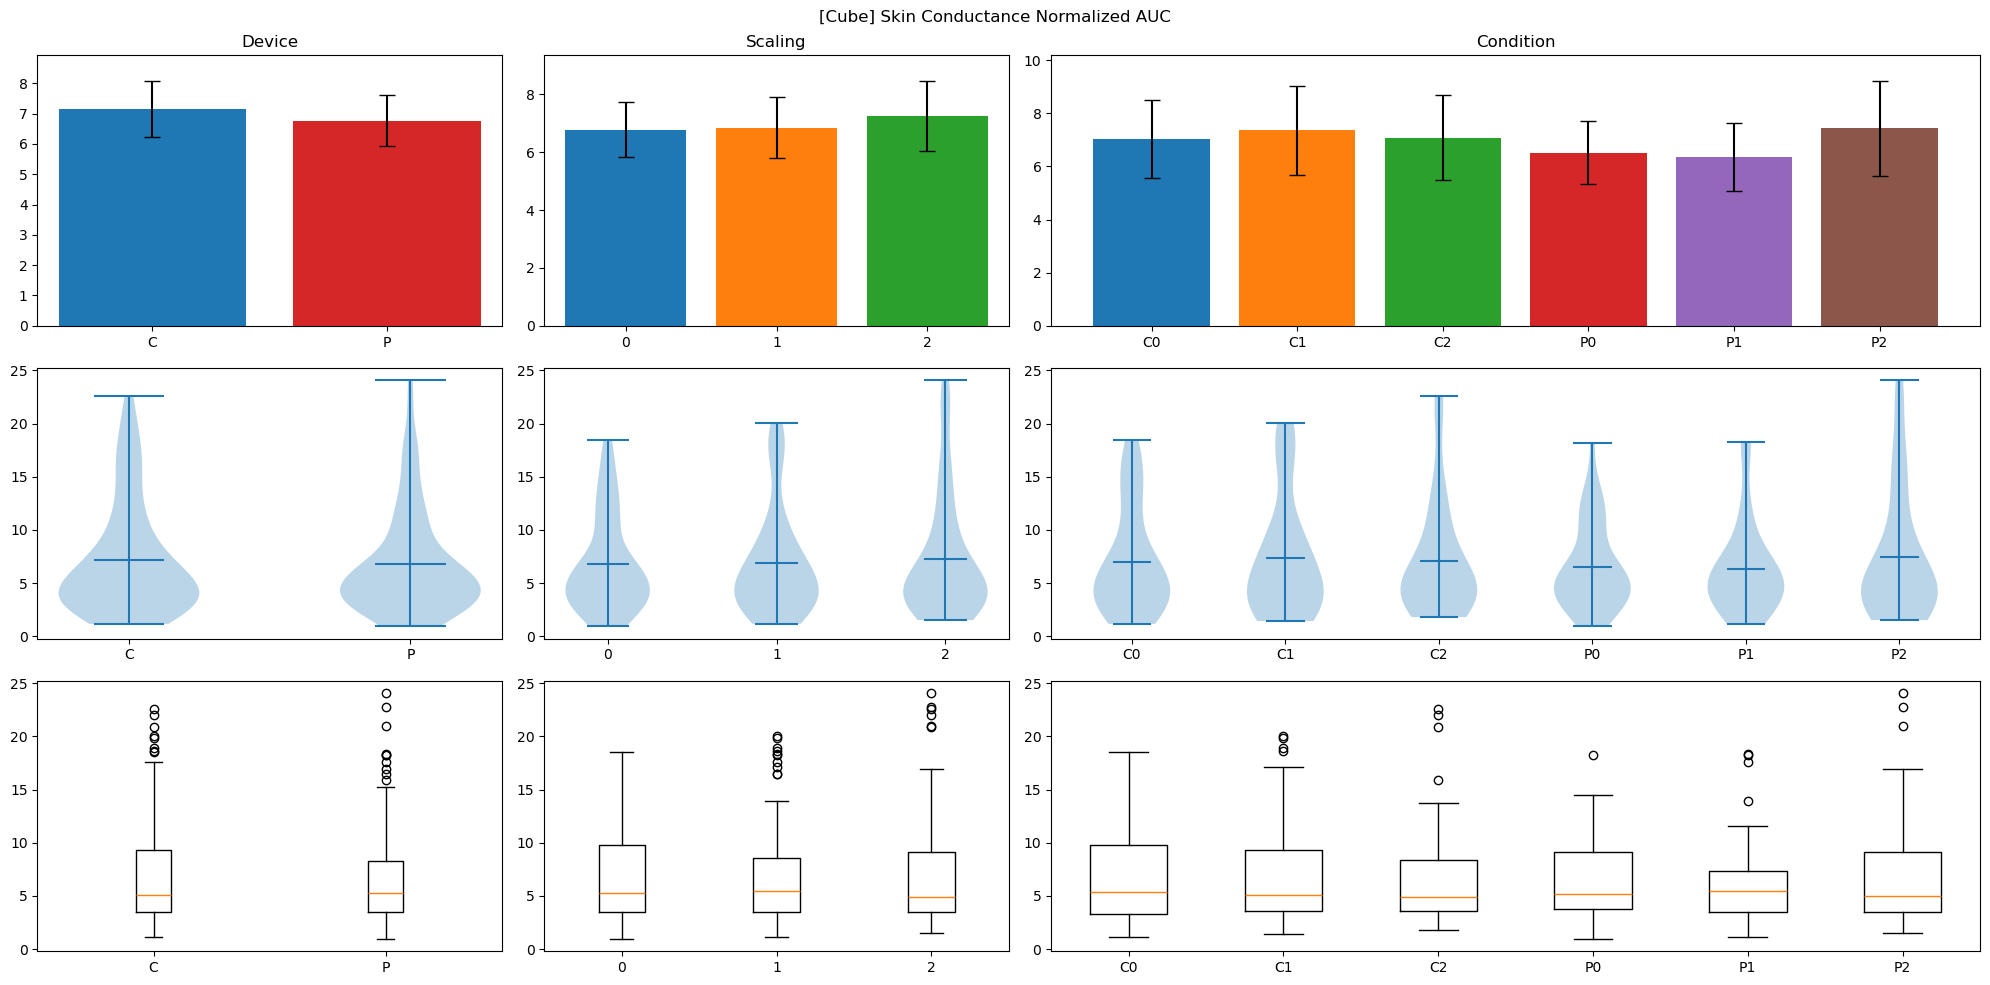

------ [Shovel] Skin Conductance Normalized AUC: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.553750,1,41,0.553750,0.354369,0.554922,0.554922,0.000055,1.000000,❌
1,Scaling,0.099541,2,82,0.049770,0.049350,0.951876,0.882070,0.000010,0.646199,❌
2,Device * Scaling,2.883409,2,82,1.441704,1.188249,0.309947,0.289162,0.000285,0.574937,❌


------ [Shovel] Skin Conductance Normalized AUC: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,3.536699,5,0.707340,0.588834,0.708537,0.603823,0.00035,0.532444,False,0.052545,6.535223e-18,❌
1,Error,246.257182,205,1.201255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


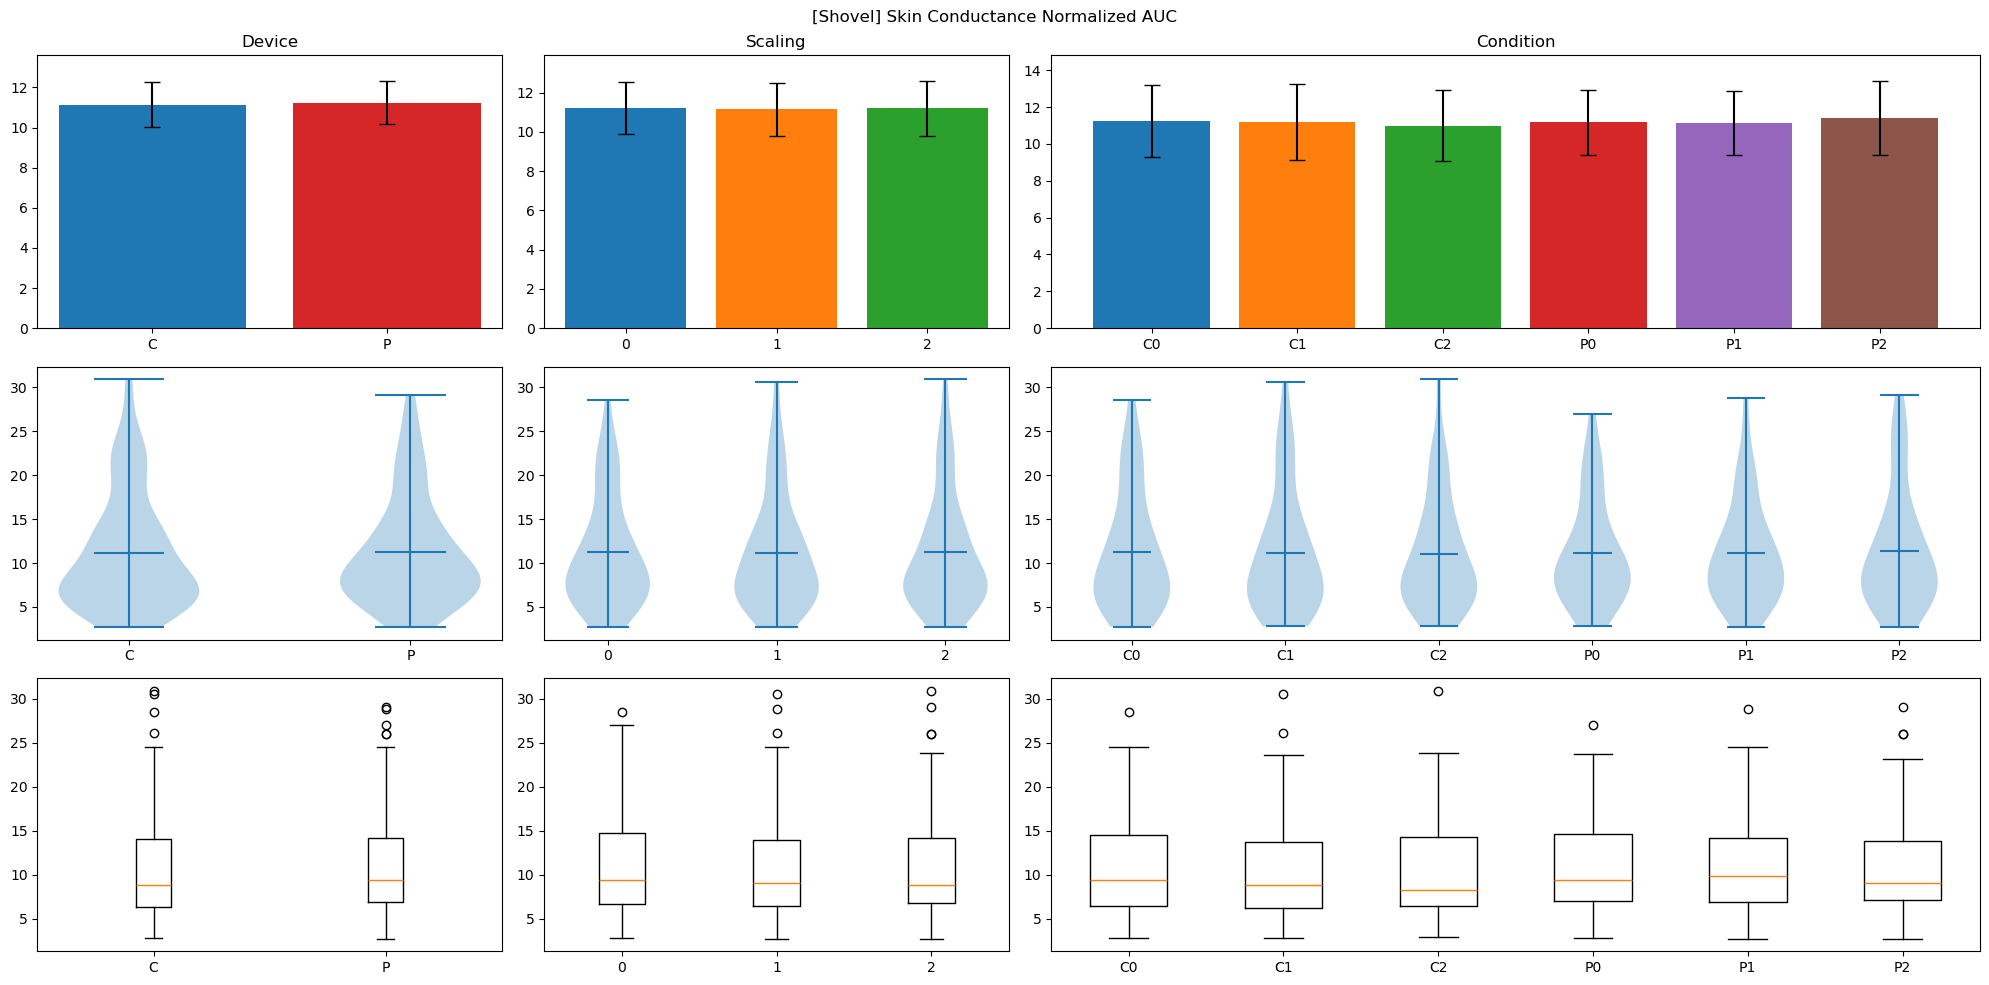

In [661]:
def gsr_con_auc(p):
    return normalized_auc(p, gsr_con_key)

title = 'Skin Conductance Normalized AUC'
ylabel = ''
report_exeriment(data, gsr_con_auc, cube, title, ylabel)
report_exeriment(data, gsr_con_auc, shovel, title, ylabel)

------ [Cube] Total Head Travel 3D: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,30.792265,1,41,30.792265,3.410929,0.071992,0.071992,0.012686,1.000000,🟨
1,Scaling,81.780435,2,82,40.890218,5.177640,0.007628,0.017872,0.032998,0.674090,✅
2,Device * Scaling,0.833778,2,82,0.416889,0.080390,0.922829,0.898773,0.000348,0.865481,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-0.241983,41.0,two-sided,0.810000,0.810000,holm,0.171,-0.031062,❌
2,Scaling,-,0,2,True,True,-2.231153,41.0,two-sided,0.031201,0.062402,holm,1.54,-0.439349,🟨
3,Scaling,-,1,2,True,True,-2.861362,41.0,two-sided,0.006612,0.019835,holm,5.718,-0.454323,✅


------ [Cube] Total Head Travel 3D: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,113.406478,5,22.681296,3.222314,0.00801,0.018418,0.045183,0.706647,False,0.304569,0.000024,✅
1,Error,1442.958488,205,7.038822,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-0.319565,41.0,two-sided,0.750921,1.000000,holm,0.175,-0.046683,❌
1,Condition,C0,C2,True,True,-1.788907,41.0,two-sided,0.081020,0.810197,holm,0.716,-0.335585,❌
2,Condition,C0,P0,True,True,-1.505934,41.0,two-sided,0.139750,1.000000,holm,0.473,-0.234720,❌
3,Condition,C0,P1,True,True,-1.498520,41.0,two-sided,0.141659,1.000000,holm,0.469,-0.260357,❌
4,Condition,C0,P2,True,True,-2.594420,41.0,two-sided,0.013083,0.183167,holm,3.186,-0.563910,❌
5,Condition,C1,C2,True,True,-1.839115,41.0,two-sided,0.073148,0.804628,holm,0.775,-0.307461,❌
6,Condition,C1,P0,True,True,-1.138351,41.0,two-sided,0.261582,1.000000,holm,0.305,-0.198229,❌
7,Condition,C1,P1,True,True,-1.189756,41.0,two-sided,0.240987,1.000000,holm,0.322,-0.223101,❌
8,Condition,C1,P2,True,True,-2.825738,41.0,two-sided,0.007257,0.108848,holm,5.277,-0.545534,❌
9,Condition,C2,P0,True,True,0.714010,41.0,two-sided,0.479267,1.000000,holm,0.212,0.143835,❌


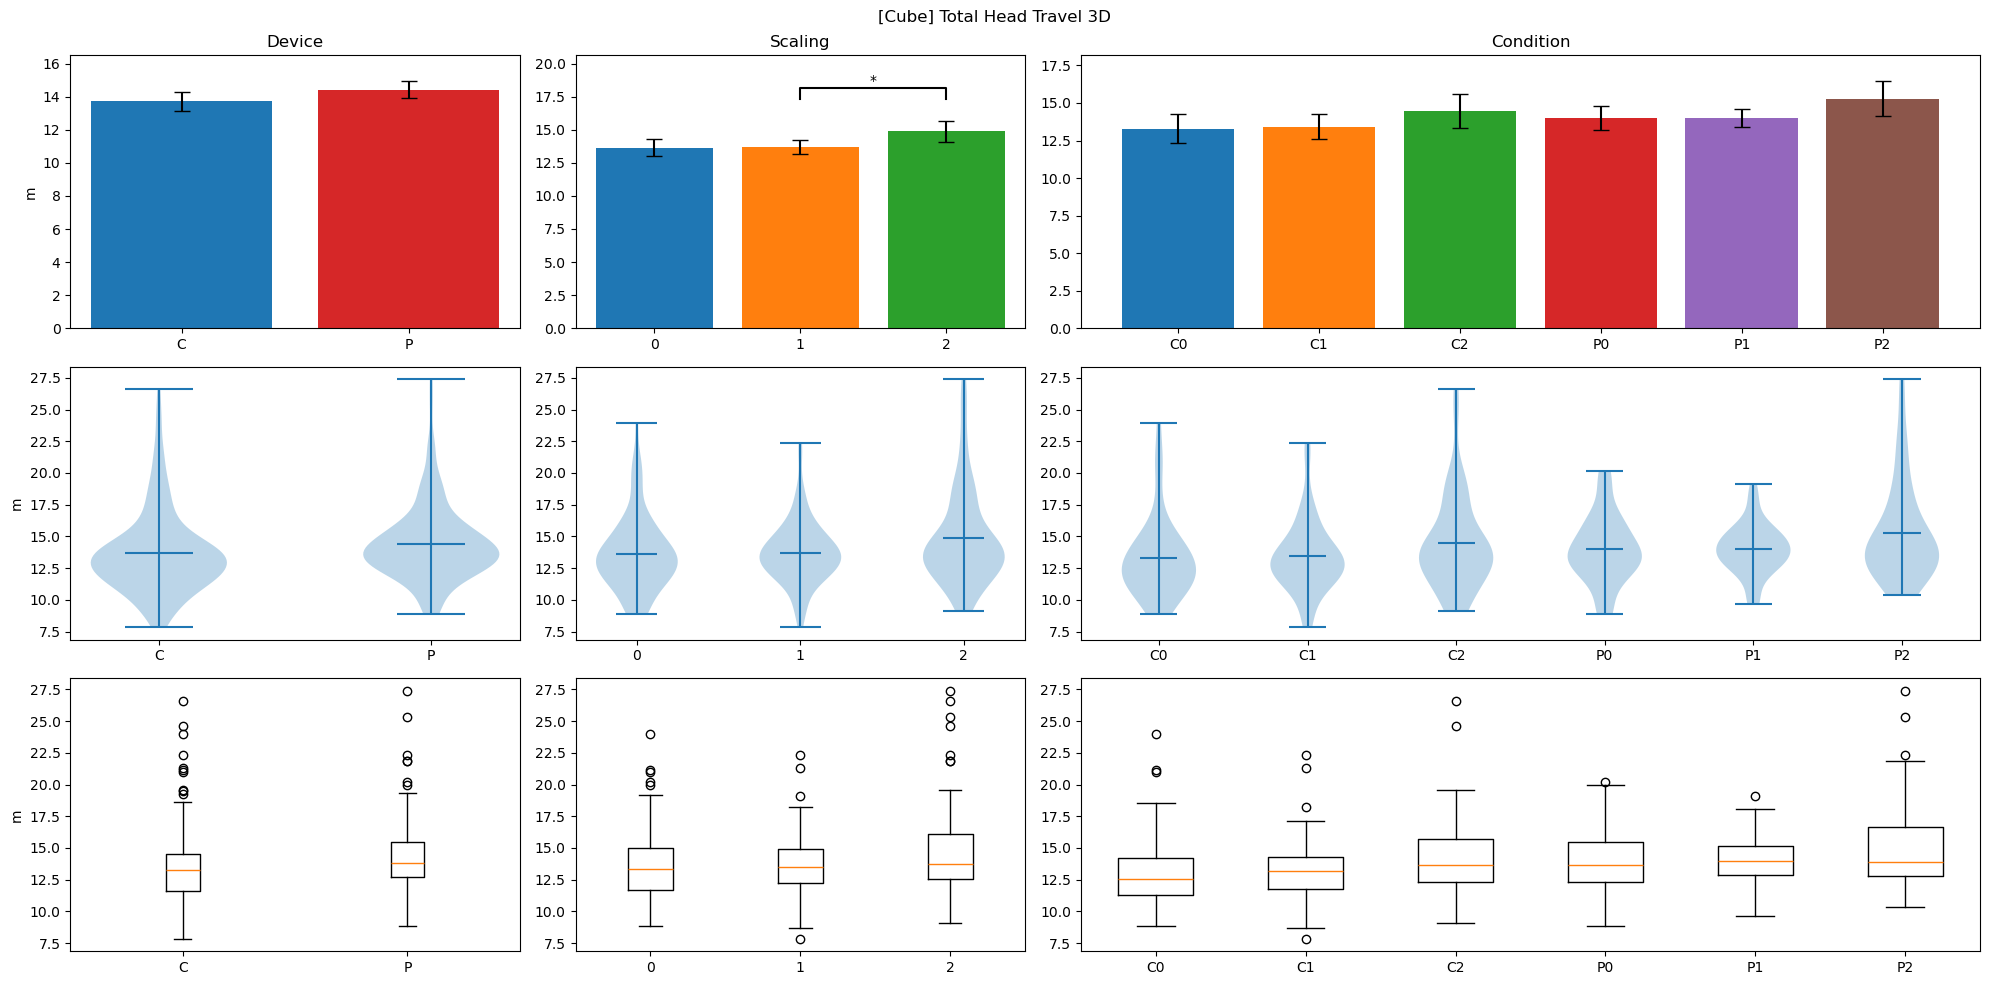

------ [Shovel] Total Head Travel 3D: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,327.775103,1,41,327.775103,7.587084,0.008726,0.008726,0.012171,1.000000,✅
1,Scaling,769.411889,2,82,384.705945,8.802507,0.000344,0.001000,0.028108,0.799725,✅
2,Device * Scaling,63.770785,2,82,31.885393,1.064536,0.349605,0.335740,0.002391,0.769927,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.754466,41.0,two-sided,0.008726,NaN,NaN,4.503,-0.247187,✅
1,Scaling,-,0,1,True,True,-1.951355,41.0,two-sided,0.057870,0.057870,holm,0.933,-0.189555,🟨
2,Scaling,-,0,2,True,True,-3.420612,41.0,two-sided,0.001427,0.004280,holm,21.933,-0.440539,✅
3,Scaling,-,1,2,True,True,-2.917095,41.0,two-sided,0.005709,0.011417,holm,6.493,-0.254299,✅


------ [Shovel] Total Head Travel 3D: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,1160.957777,5,232.191555,6.093794,0.000028,0.000225,0.041814,0.736054,False,0.354232,0.000212,✅
1,Error,7811.105582,205,38.102954,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-1.411627,41.0,two-sided,0.165604,0.828022,holm,0.418,-0.175374,❌
1,Condition,C0,C2,True,True,-3.500631,41.0,two-sided,0.001134,0.015877,holm,26.895,-0.510212,✅
2,Condition,C0,P0,True,True,-2.610733,41.0,two-sided,0.012562,0.138178,holm,3.298,-0.290501,❌
3,Condition,C0,P1,True,True,-3.005982,41.0,two-sided,0.004504,0.054046,holm,7.978,-0.449878,🟨
4,Condition,C0,P2,True,True,-3.538572,41.0,two-sided,0.001016,0.015246,holm,29.652,-0.589919,✅
5,Condition,C1,C2,True,True,-2.604206,41.0,two-sided,0.012768,0.138178,holm,3.253,-0.339354,❌
6,Condition,C1,P0,True,True,-0.904171,41.0,two-sided,0.371187,1.000000,holm,0.244,-0.115704,❌
7,Condition,C1,P1,True,True,-2.084017,41.0,two-sided,0.043431,0.347450,holm,1.175,-0.282386,❌
8,Condition,C1,P2,True,True,-3.338539,41.0,two-sided,0.001801,0.023410,holm,17.843,-0.420205,✅
9,Condition,C2,P0,True,True,1.845316,41.0,two-sided,0.072222,0.461158,holm,0.783,0.225571,❌


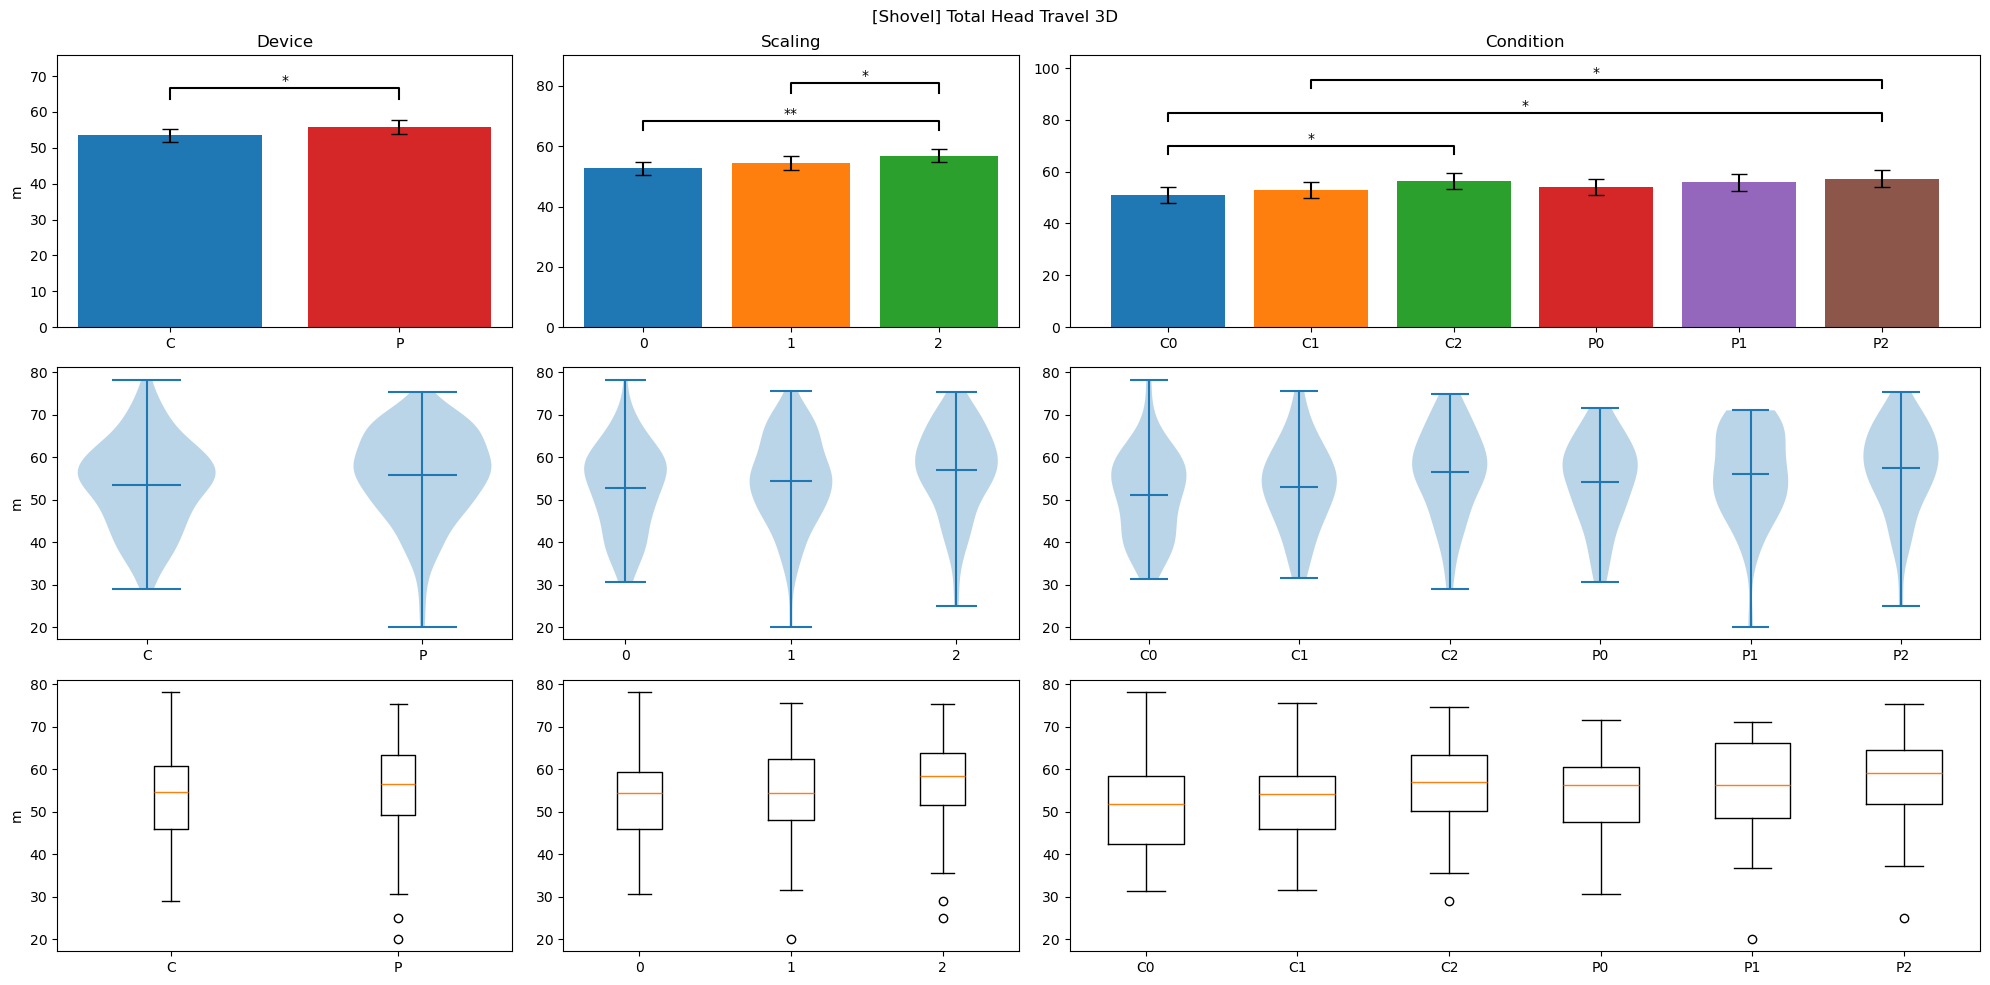

------ [Cube] Total Head Travel Planar: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,30.792265,1,41,30.792265,3.410929,0.071992,0.071992,0.012686,1.000000,🟨
1,Scaling,81.780435,2,82,40.890218,5.177640,0.007628,0.017872,0.032998,0.674090,✅
2,Device * Scaling,0.833778,2,82,0.416889,0.080390,0.922829,0.898773,0.000348,0.865481,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-0.241983,41.0,two-sided,0.810000,0.810000,holm,0.171,-0.031062,❌
2,Scaling,-,0,2,True,True,-2.231153,41.0,two-sided,0.031201,0.062402,holm,1.54,-0.439349,🟨
3,Scaling,-,1,2,True,True,-2.861362,41.0,two-sided,0.006612,0.019835,holm,5.718,-0.454323,✅


------ [Cube] Total Head Travel Planar: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,113.406478,5,22.681296,3.222314,0.00801,0.018418,0.045183,0.706647,False,0.304569,0.000024,✅
1,Error,1442.958488,205,7.038822,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-0.319565,41.0,two-sided,0.750921,1.000000,holm,0.175,-0.046683,❌
1,Condition,C0,C2,True,True,-1.788907,41.0,two-sided,0.081020,0.810197,holm,0.716,-0.335585,❌
2,Condition,C0,P0,True,True,-1.505934,41.0,two-sided,0.139750,1.000000,holm,0.473,-0.234720,❌
3,Condition,C0,P1,True,True,-1.498520,41.0,two-sided,0.141659,1.000000,holm,0.469,-0.260357,❌
4,Condition,C0,P2,True,True,-2.594420,41.0,two-sided,0.013083,0.183167,holm,3.186,-0.563910,❌
5,Condition,C1,C2,True,True,-1.839115,41.0,two-sided,0.073148,0.804628,holm,0.775,-0.307461,❌
6,Condition,C1,P0,True,True,-1.138351,41.0,two-sided,0.261582,1.000000,holm,0.305,-0.198229,❌
7,Condition,C1,P1,True,True,-1.189756,41.0,two-sided,0.240987,1.000000,holm,0.322,-0.223101,❌
8,Condition,C1,P2,True,True,-2.825738,41.0,two-sided,0.007257,0.108848,holm,5.277,-0.545534,❌
9,Condition,C2,P0,True,True,0.714010,41.0,two-sided,0.479267,1.000000,holm,0.212,0.143835,❌


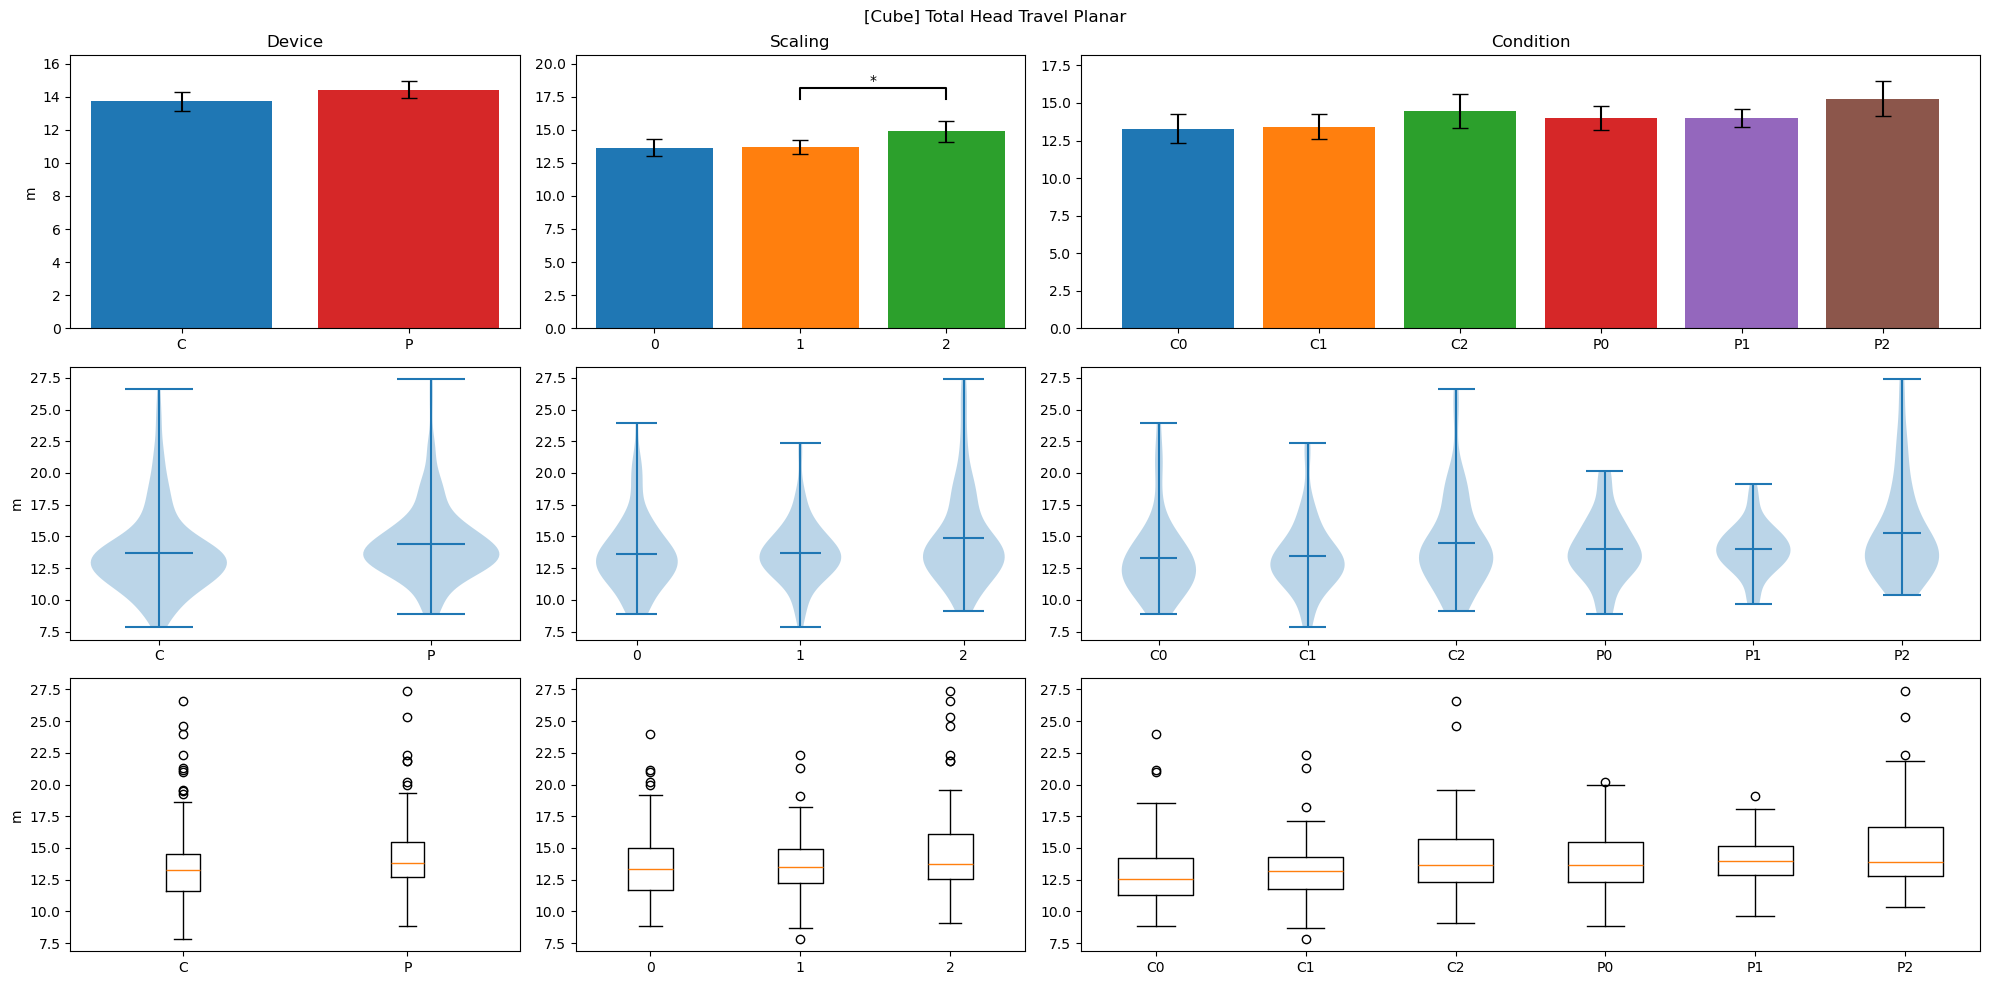

------ [Shovel] Total Head Travel Planar: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,327.775103,1,41,327.775103,7.587084,0.008726,0.008726,0.012171,1.000000,✅
1,Scaling,769.411889,2,82,384.705945,8.802507,0.000344,0.001000,0.028108,0.799725,✅
2,Device * Scaling,63.770785,2,82,31.885393,1.064536,0.349605,0.335740,0.002391,0.769927,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.754466,41.0,two-sided,0.008726,NaN,NaN,4.503,-0.247187,✅
1,Scaling,-,0,1,True,True,-1.951355,41.0,two-sided,0.057870,0.057870,holm,0.933,-0.189555,🟨
2,Scaling,-,0,2,True,True,-3.420612,41.0,two-sided,0.001427,0.004280,holm,21.933,-0.440539,✅
3,Scaling,-,1,2,True,True,-2.917095,41.0,two-sided,0.005709,0.011417,holm,6.493,-0.254299,✅


------ [Shovel] Total Head Travel Planar: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,1160.957777,5,232.191555,6.093794,0.000028,0.000225,0.041814,0.736054,False,0.354232,0.000212,✅
1,Error,7811.105582,205,38.102954,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-1.411627,41.0,two-sided,0.165604,0.828022,holm,0.418,-0.175374,❌
1,Condition,C0,C2,True,True,-3.500631,41.0,two-sided,0.001134,0.015877,holm,26.895,-0.510212,✅
2,Condition,C0,P0,True,True,-2.610733,41.0,two-sided,0.012562,0.138178,holm,3.298,-0.290501,❌
3,Condition,C0,P1,True,True,-3.005982,41.0,two-sided,0.004504,0.054046,holm,7.978,-0.449878,🟨
4,Condition,C0,P2,True,True,-3.538572,41.0,two-sided,0.001016,0.015246,holm,29.652,-0.589919,✅
5,Condition,C1,C2,True,True,-2.604206,41.0,two-sided,0.012768,0.138178,holm,3.253,-0.339354,❌
6,Condition,C1,P0,True,True,-0.904171,41.0,two-sided,0.371187,1.000000,holm,0.244,-0.115704,❌
7,Condition,C1,P1,True,True,-2.084017,41.0,two-sided,0.043431,0.347450,holm,1.175,-0.282386,❌
8,Condition,C1,P2,True,True,-3.338539,41.0,two-sided,0.001801,0.023410,holm,17.843,-0.420205,✅
9,Condition,C2,P0,True,True,1.845316,41.0,two-sided,0.072222,0.461158,holm,0.783,0.225571,❌


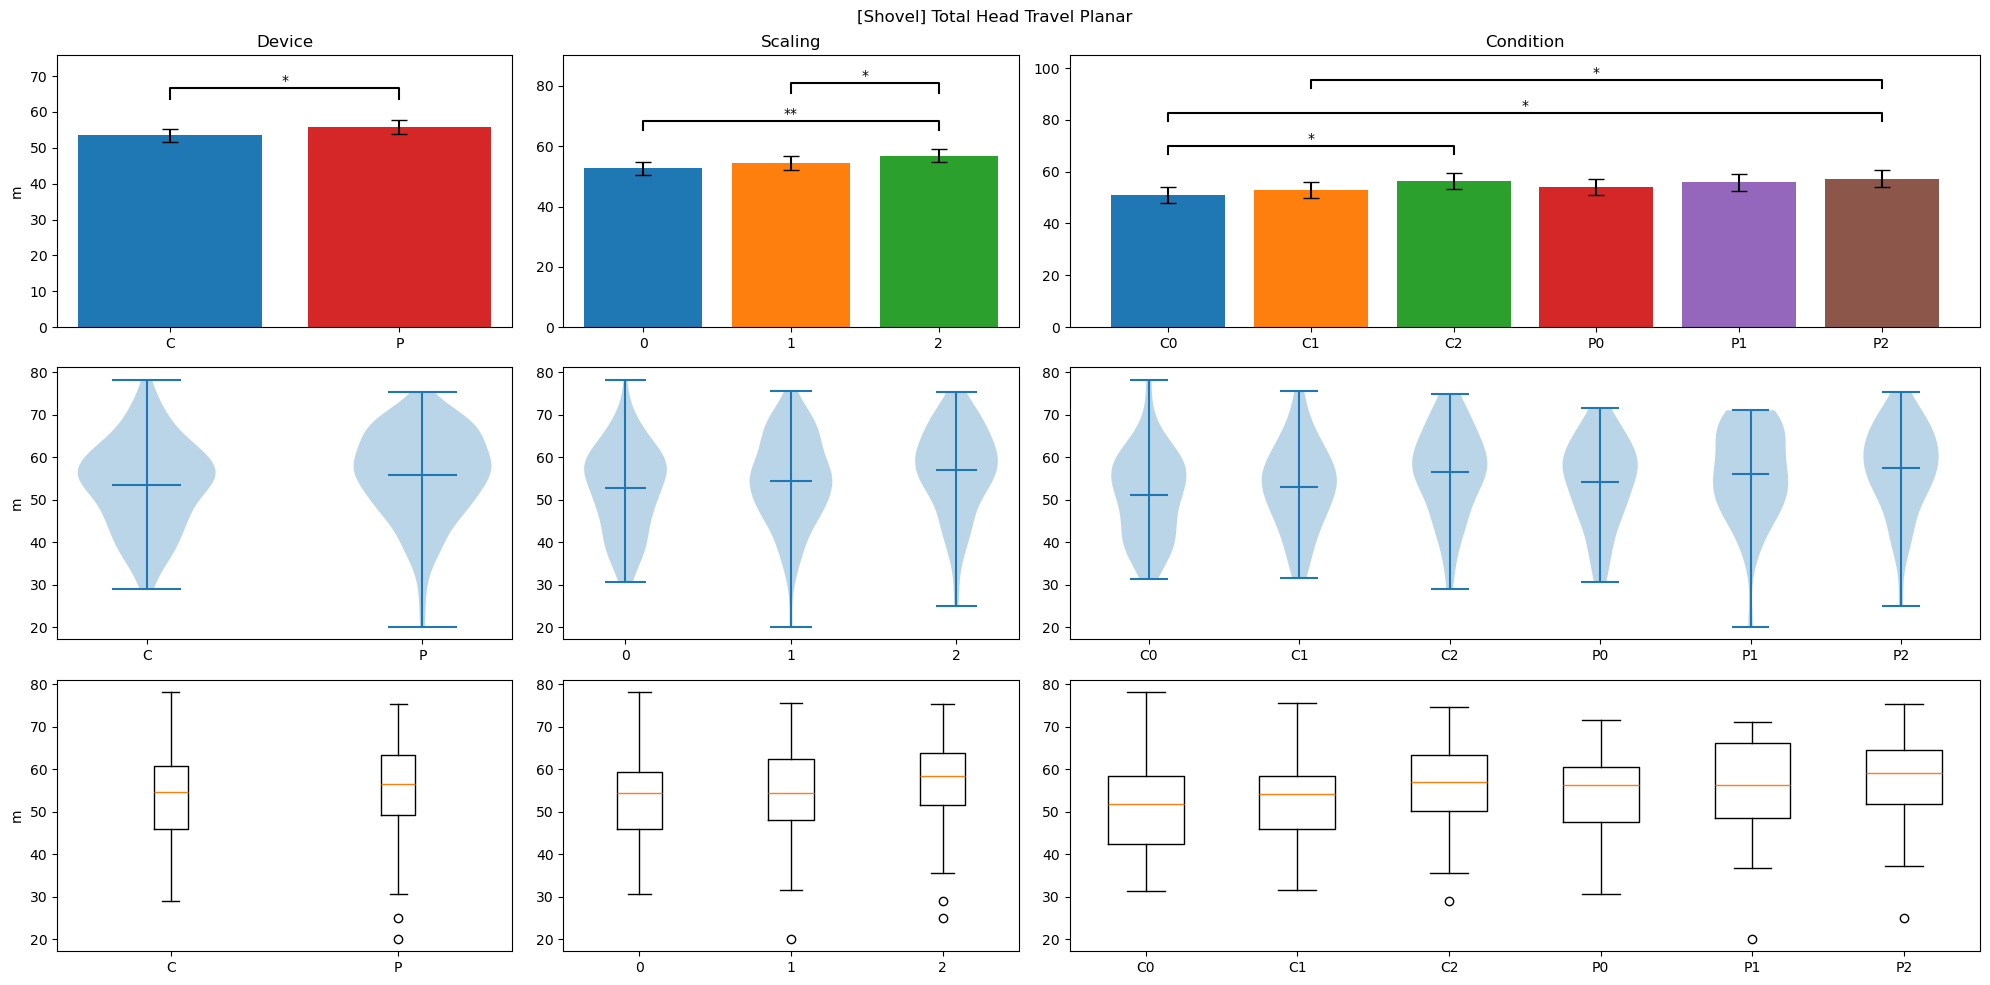

------ [Cube] Total Head Travel Vertical: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,7.810517,1,41,7.810517,144.730680,4.945364e-15,4.945364e-15,0.529340,1.000000,✅
1,Scaling,0.009390,2,82,0.004695,0.295805,7.447229e-01,6.905500e-01,0.001350,0.782321,❌
2,Device * Scaling,0.010043,2,82,0.005022,0.352729,7.038284e-01,6.501247e-01,0.001444,0.777255,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-12.030406,41.0,two-sided,4.945364e-15,NaN,NaN,1.366e+12,-2.586442,✅


------ [Cube] Total Head Travel Vertical: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,7.829951,5,1.565990,68.573026,6.910282e-42,4.602348e-23,0.529959,0.522257,False,0.127149,2.358108e-11,✅
1,Error,4.681549,205,0.022837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,1.425078,41.0,two-sided,1.617031e-01,9.702184e-01,holm,0.426,0.135611,❌
1,Condition,C0,C2,True,True,-0.172202,41.0,two-sided,8.641262e-01,1.000000e+00,holm,0.169,-0.022091,❌
2,Condition,C0,P0,True,True,-11.996287,41.0,two-sided,5.417989e-15,7.043386e-14,holm,1.251e+12,-2.141342,✅
3,Condition,C0,P1,True,True,-10.902533,41.0,two-sided,1.093810e-13,1.312572e-12,holm,6.944e+10,-2.175874,✅
4,Condition,C0,P2,True,True,-7.784240,41.0,two-sided,1.317535e-09,1.054028e-08,holm,8.737e+06,-1.897262,✅
5,Condition,C1,C2,True,True,-1.011135,41.0,two-sided,3.178820e-01,1.000000e+00,holm,0.269,-0.149322,❌
6,Condition,C1,P0,True,True,-14.083806,41.0,two-sided,2.650851e-17,3.976277e-16,holm,2.12e+14,-2.426608,✅
7,Condition,C1,P1,True,True,-12.613460,41.0,two-sided,1.063295e-15,1.488613e-14,holm,6.008e+12,-2.470838,✅
8,Condition,C1,P2,True,True,-8.241324,41.0,two-sided,3.097136e-10,2.787423e-09,holm,3.46e+07,-2.122850,✅
9,Condition,C2,P0,True,True,-10.295854,41.0,two-sided,6.192440e-13,6.811684e-12,holm,1.315e+10,-1.946097,✅


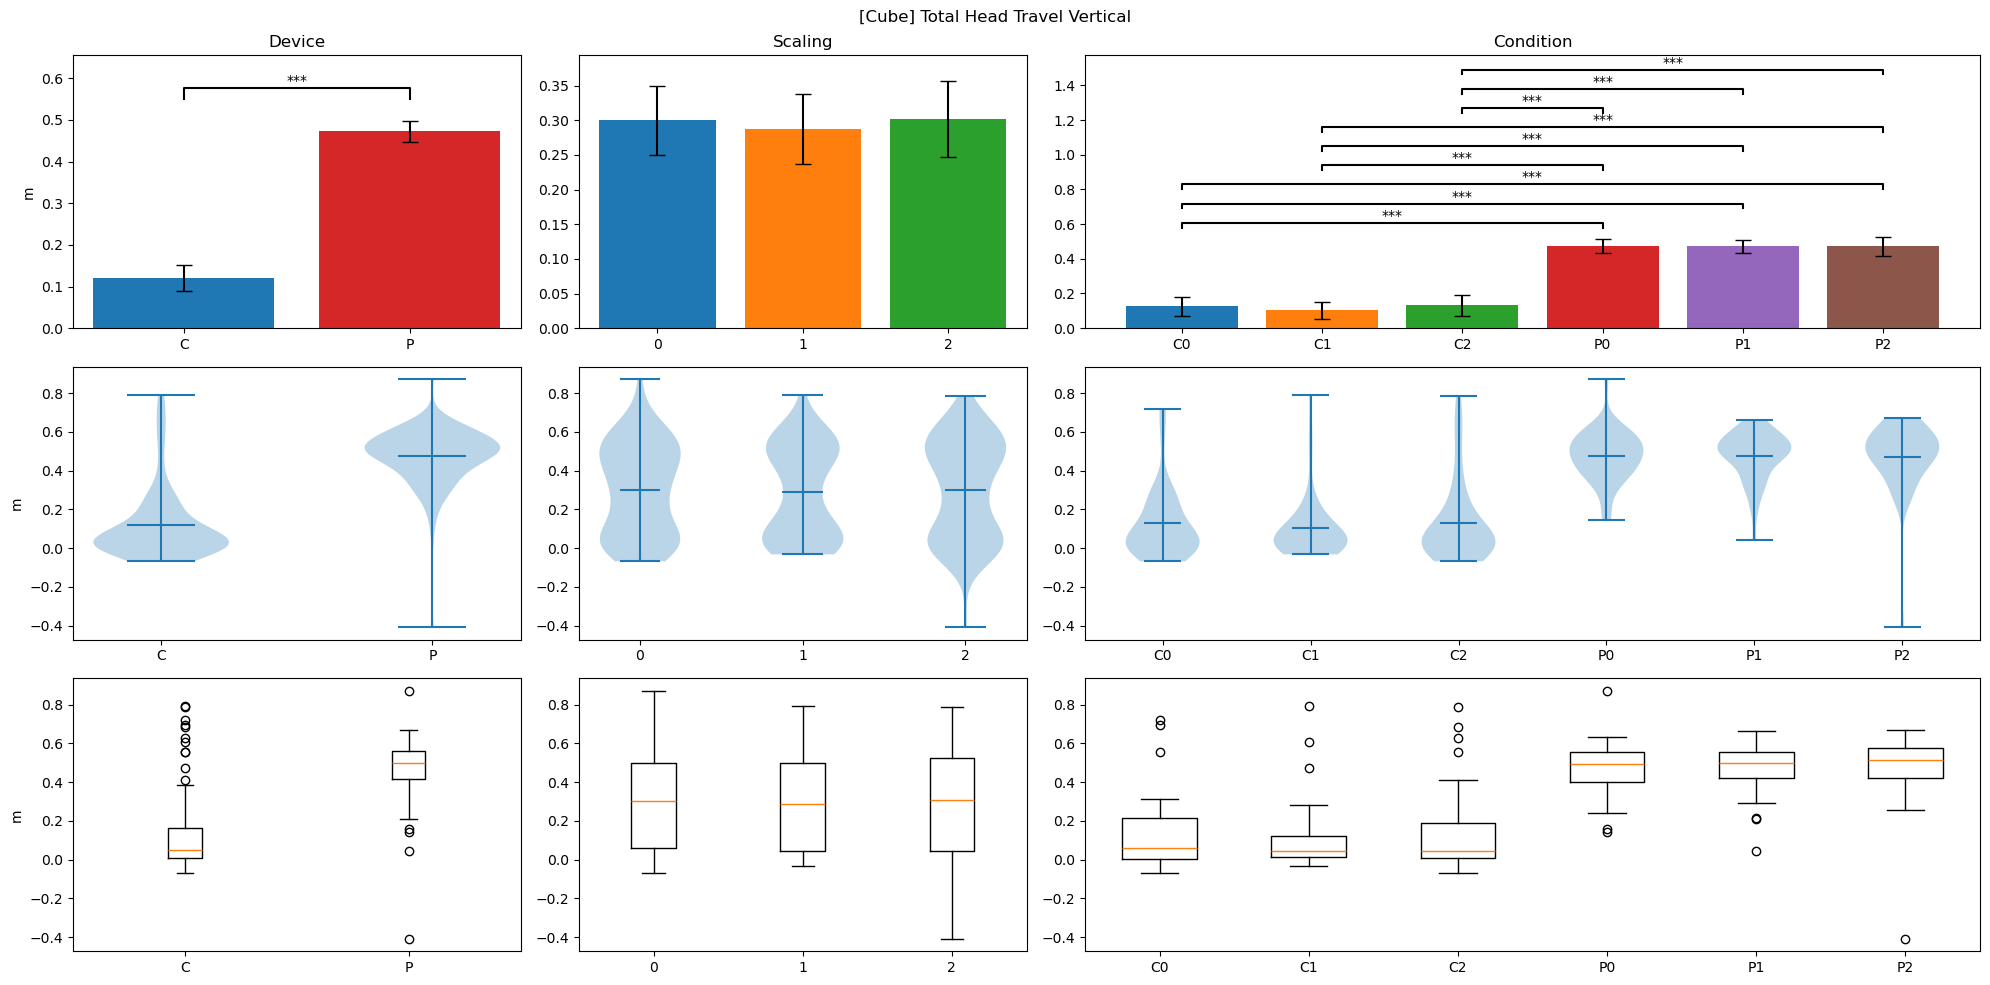

------ [Shovel] Total Head Travel Vertical: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.927312,1,41,0.927312,3.293185,0.076889,0.076889,0.035129,1.000000,🟨
1,Scaling,0.087482,2,82,0.043741,1.638269,0.200612,0.201306,0.003423,0.976421,❌
2,Device * Scaling,0.072257,2,82,0.036128,1.435287,0.243964,0.244112,0.002829,0.983266,❌


------ [Shovel] Total Head Travel Vertical: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,1.087051,5,0.217410,2.82111,0.017345,0.071967,0.040933,0.356768,False,0.034087,3.263307e-21,🟨
1,Error,15.798421,205,0.077065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


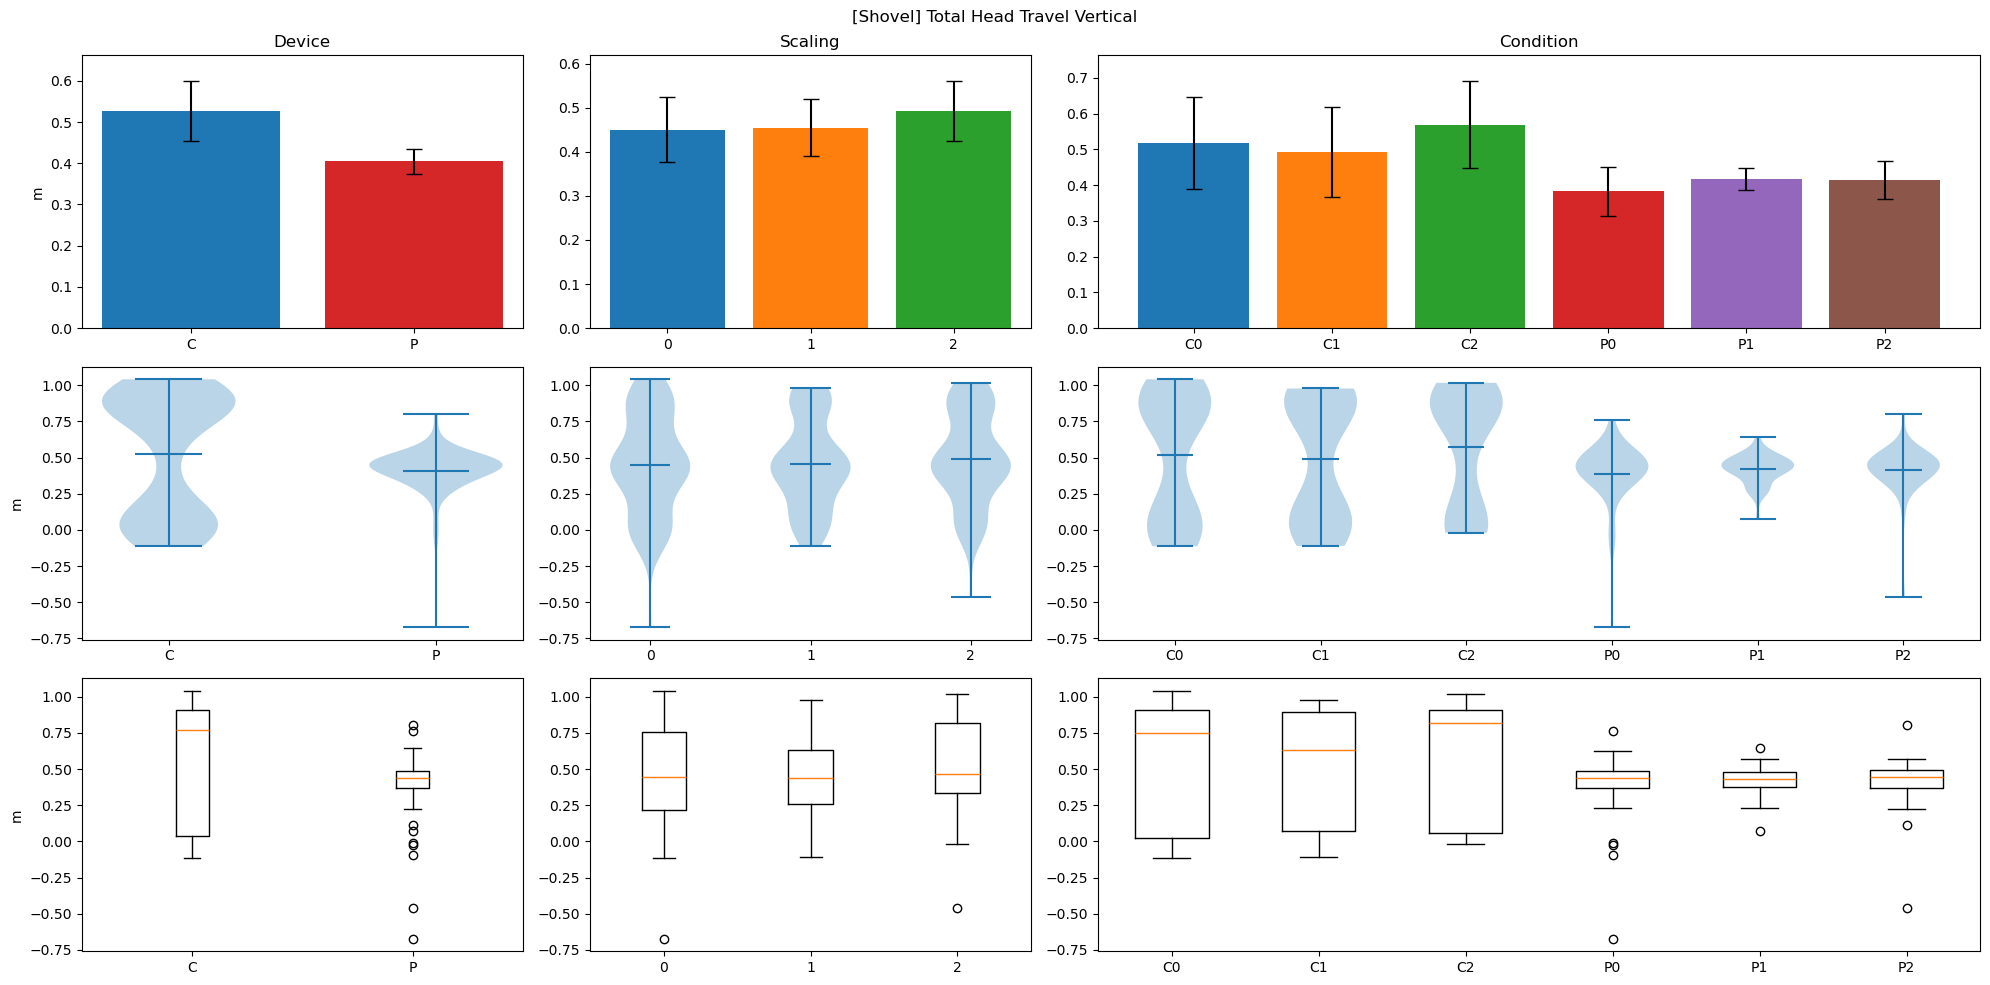

In [662]:
def hmd_path_len(p):
    return get_pt_path_len(p, hmd)

def hmd_path_len_planar(p):
    return get_pt_path_len_planar(p, hmd)

def hmd_path_len_vertical(p):
    return get_pt_path_len_vertical(p, hmd)

title = 'Total Head Travel 3D'
ylabel = 'm'
report_exeriment(data, hmd_path_len, cube, title, ylabel)
report_exeriment(data, hmd_path_len, shovel, title, ylabel)

title = 'Total Head Travel Planar'
ylabel = 'm'
report_exeriment(data, hmd_path_len_planar, cube, title, ylabel)
report_exeriment(data, hmd_path_len_planar, shovel, title, ylabel)

title = 'Total Head Travel Vertical'
ylabel = 'm'
report_exeriment(data, hmd_path_len_vertical, cube, title, ylabel)
report_exeriment(data, hmd_path_len_vertical, shovel, title, ylabel)

------ [Shovel] Average Hand Distance: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,135220.234960,1,41,135220.234960,21.845864,3.180166e-05,3.180166e-05,0.115486,1.000000,✅
1,Scaling,46328.995440,2,82,23164.497720,20.928004,4.536988e-08,2.173738e-07,0.042819,0.885321,✅
2,Device * Scaling,5467.706967,2,82,2733.853484,2.850314,6.357069e-02,7.162487e-02,0.005252,0.869571,🟨


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-4.673956,41.0,two-sided,0.000032,NaN,NaN,685.204,-0.773562,✅
1,Scaling,-,0,1,True,True,-4.212134,41.0,two-sided,0.000135,0.000270,holm,182.699,-0.384698,✅
2,Scaling,-,0,2,True,True,-5.520926,41.0,two-sided,0.000002,0.000006,holm,8564.456,-0.610009,✅
3,Scaling,-,1,2,True,True,-2.723940,41.0,two-sided,0.009436,0.009436,holm,4.211,-0.221618,✅


------ [Shovel] Average Hand Distance: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,187016.937367,5,37403.387473,18.118715,7.122661e-15,4.601677e-08,0.152957,0.463968,False,0.082202,1.493144e-14,✅
1,Error,423191.947137,205,2064.350962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-3.739669,41.0,two-sided,5.641010e-04,4.512808e-03,holm,50.208,-0.296470,✅
1,Condition,C0,C2,True,True,-4.645421,41.0,two-sided,3.481333e-05,4.177599e-04,holm,630.586,-0.574195,✅
2,Condition,C0,P0,True,True,-5.144912,41.0,two-sided,7.028703e-06,9.137314e-05,holm,2756.552,-0.856063,✅
3,Condition,C0,P1,True,True,-6.565926,41.0,two-sided,6.783159e-08,9.496423e-07,holm,2.104e+05,-1.160912,✅
4,Condition,C0,P2,True,True,-7.334169,41.0,two-sided,5.584272e-09,8.376408e-08,holm,2.222e+06,-1.217616,✅
5,Condition,C1,C2,True,True,-2.441113,41.0,two-sided,1.904717e-02,6.640823e-02,holm,2.32,-0.254084,🟨
6,Condition,C1,P0,True,True,-2.497788,41.0,two-sided,1.660206e-02,6.640823e-02,holm,2.605,-0.463124,🟨
7,Condition,C1,P1,True,True,-4.066091,41.0,two-sided,2.114224e-04,2.114224e-03,holm,121.655,-0.741264,✅
8,Condition,C1,P2,True,True,-4.552298,41.0,two-sided,4.672848e-05,5.140133e-04,holm,481.418,-0.794452,✅
9,Condition,C2,P0,True,True,-0.970660,41.0,two-sided,3.374094e-01,6.748187e-01,holm,0.259,-0.177769,❌


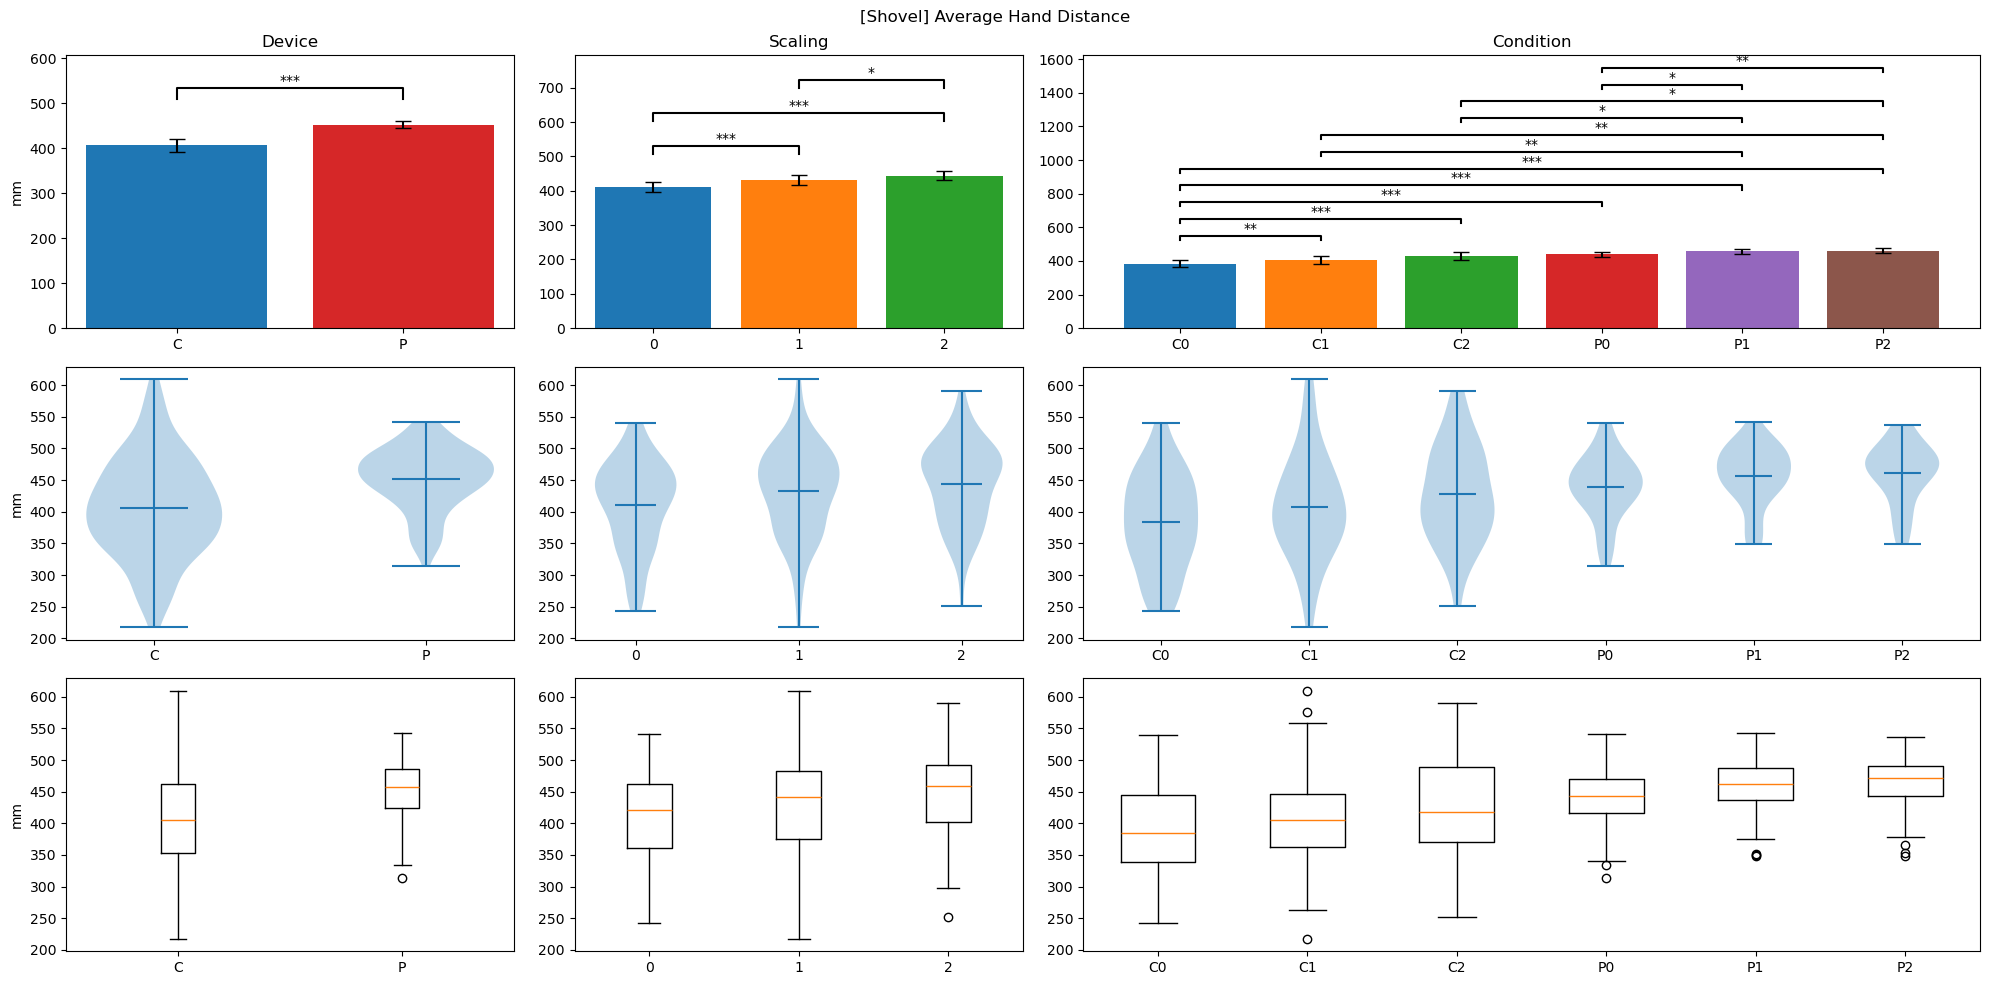

In [663]:
primary_tracked = "pt"
secondary_tracked = "st"
primary_visible = "pv"
secondary_visible = "sv"

def mean_pt_dist(p, pt_1, pt_2):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    df["dist"] = df.apply(lambda x: distance.euclidean((x[pt_1 + "_x"], x[pt_1 + "_y"], x[pt_1 + "_z"]), (x[pt_2 + "_x"], x[pt_2 + "_y"], x[pt_2 + "_z"])), axis = 1)
    return df["dist"].mean()

def tracked_hand_dist_mm(p):
    return mean_pt_dist(p, primary_tracked, secondary_tracked) * 1_000

title = "Average Hand Distance"
ylabel = "mm"
report_exeriment(data, tracked_hand_dist_mm, shovel, title, ylabel)

------ [Cube] Task Duration: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,182.927808,1,41,182.927808,2.978326,0.091917,0.091917,0.008656,1.000000,🟨
1,Scaling,509.542389,2,82,254.771194,4.594288,0.012847,0.023756,0.023743,0.717352,✅
2,Device * Scaling,22.108316,2,82,11.054158,0.253489,0.776694,0.729074,0.001054,0.807523,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,0.286750,41.0,two-sided,0.775748,0.775748,holm,0.173,0.040120,❌
2,Scaling,-,0,2,True,True,-1.955991,41.0,two-sided,0.057303,0.114606,holm,0.94,-0.330199,❌
3,Scaling,-,1,2,True,True,-3.503763,41.0,two-sided,0.001124,0.003372,holm,27.112,-0.414565,✅


------ [Cube] Task Duration: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,714.578513,5,142.915703,2.753211,0.019743,0.034595,0.032982,0.729578,False,0.378307,0.000529,✅
1,Error,10641.290022,205,51.908732,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,0.402014,41.0,two-sided,0.689762,1.000000,holm,0.18,0.058957,❌
1,Condition,C0,C2,True,True,-1.263424,41.0,two-sided,0.213574,1.000000,holm,0.35,-0.209017,❌
2,Condition,C0,P0,True,True,-0.795063,41.0,two-sided,0.431155,1.000000,holm,0.224,-0.111795,❌
3,Condition,C0,P1,True,True,-0.637407,41.0,two-sided,0.527403,1.000000,holm,0.202,-0.124074,❌
4,Condition,C0,P2,True,True,-2.137974,41.0,two-sided,0.038528,0.500863,holm,1.295,-0.437834,❌
5,Condition,C1,C2,True,True,-1.937285,41.0,two-sided,0.059621,0.715448,holm,0.911,-0.279265,❌
6,Condition,C1,P0,True,True,-1.100467,41.0,two-sided,0.277548,1.000000,holm,0.293,-0.184013,❌
7,Condition,C1,P1,True,True,-1.092719,41.0,two-sided,0.280897,1.000000,holm,0.291,-0.210156,❌
8,Condition,C1,P2,True,True,-3.388713,41.0,two-sided,0.001562,0.023433,holm,20.236,-0.518386,✅
9,Condition,C2,P0,True,True,0.713420,41.0,two-sided,0.479627,1.000000,holm,0.212,0.114538,❌


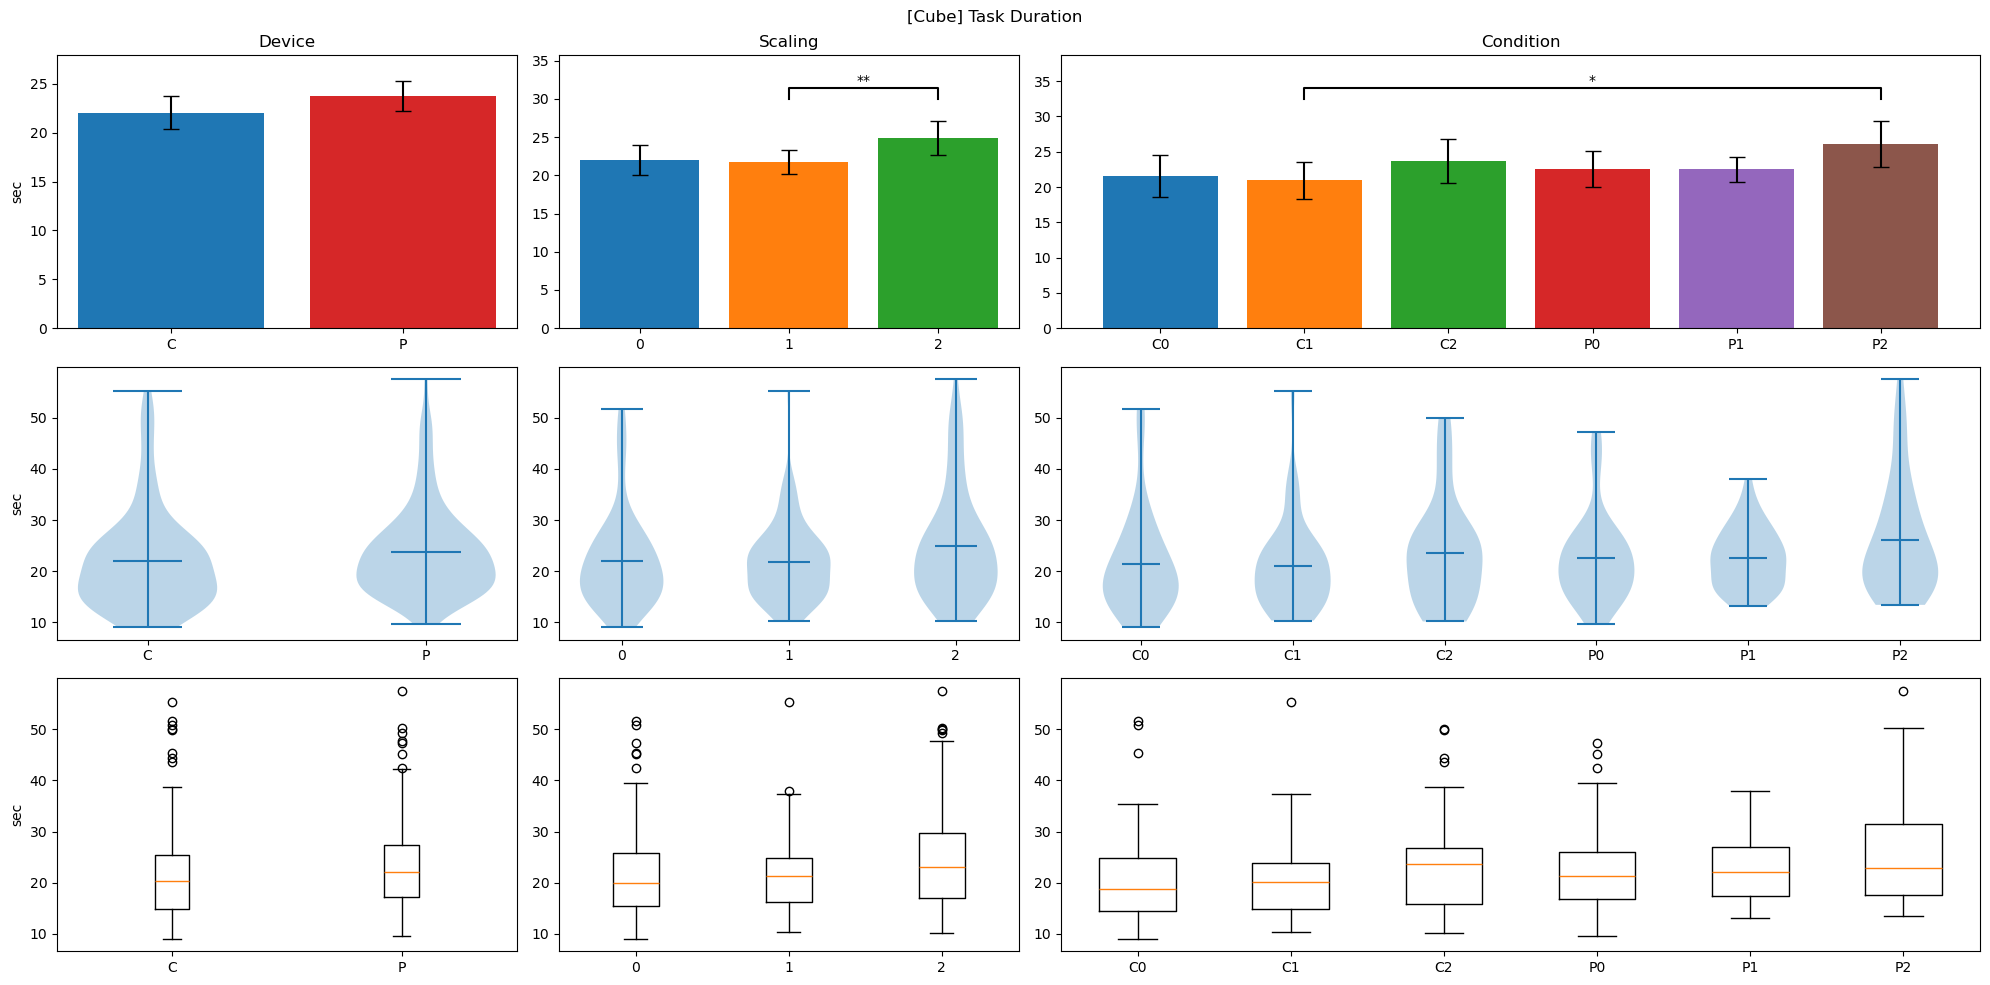

------ [Shovel] Task Duration: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,174.495364,1,41,174.495364,0.839379,0.364932,0.364932,0.001872,1.000000,❌
1,Scaling,7102.383999,2,82,3551.192000,15.168288,0.000002,0.000015,0.070940,0.815774,✅
2,Device * Scaling,14.563805,2,82,7.281902,0.039588,0.961204,0.925526,0.000157,0.760083,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.012462,41.0,two-sided,0.050771,0.050771,holm,1.036,-0.263000,🟨
2,Scaling,-,0,2,True,True,-4.467527,41.0,two-sided,0.000061,0.000183,holm,377.161,-0.740061,✅
3,Scaling,-,1,2,True,True,-4.280168,41.0,two-sided,0.000109,0.000219,holm,221.251,-0.494258,✅


------ [Shovel] Task Duration: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,7291.443168,5,1458.288634,6.984076,0.000005,0.000088,0.072691,0.696339,False,0.208419,7.263625e-08,✅
1,Error,42804.398927,205,208.801946,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-1.223210,41.0,two-sided,0.228234,1.000000,holm,0.334,-0.213714,❌
1,Condition,C0,C2,True,True,-3.557945,41.0,two-sided,0.000961,0.011531,holm,31.175,-0.675603,✅
2,Condition,C0,P0,True,True,-0.805739,41.0,two-sided,0.425042,1.000000,holm,0.226,-0.106924,❌
3,Condition,C0,P1,True,True,-1.858134,41.0,two-sided,0.070340,0.422042,holm,0.8,-0.337331,❌
4,Condition,C0,P2,True,True,-3.665054,41.0,two-sided,0.000703,0.009138,holm,41.223,-0.749761,✅
5,Condition,C1,C2,True,True,-2.382812,41.0,two-sided,0.021899,0.153292,holm,2.065,-0.425225,❌
6,Condition,C1,P0,True,True,0.698284,41.0,two-sided,0.488941,1.000000,holm,0.21,0.116296,❌
7,Condition,C1,P1,True,True,-0.548705,41.0,two-sided,0.586184,1.000000,holm,0.192,-0.100087,❌
8,Condition,C1,P2,True,True,-3.187908,41.0,two-sided,0.002743,0.030172,holm,12.313,-0.485362,✅
9,Condition,C2,P0,True,True,3.857131,41.0,two-sided,0.000398,0.005567,holm,68.757,0.578737,✅


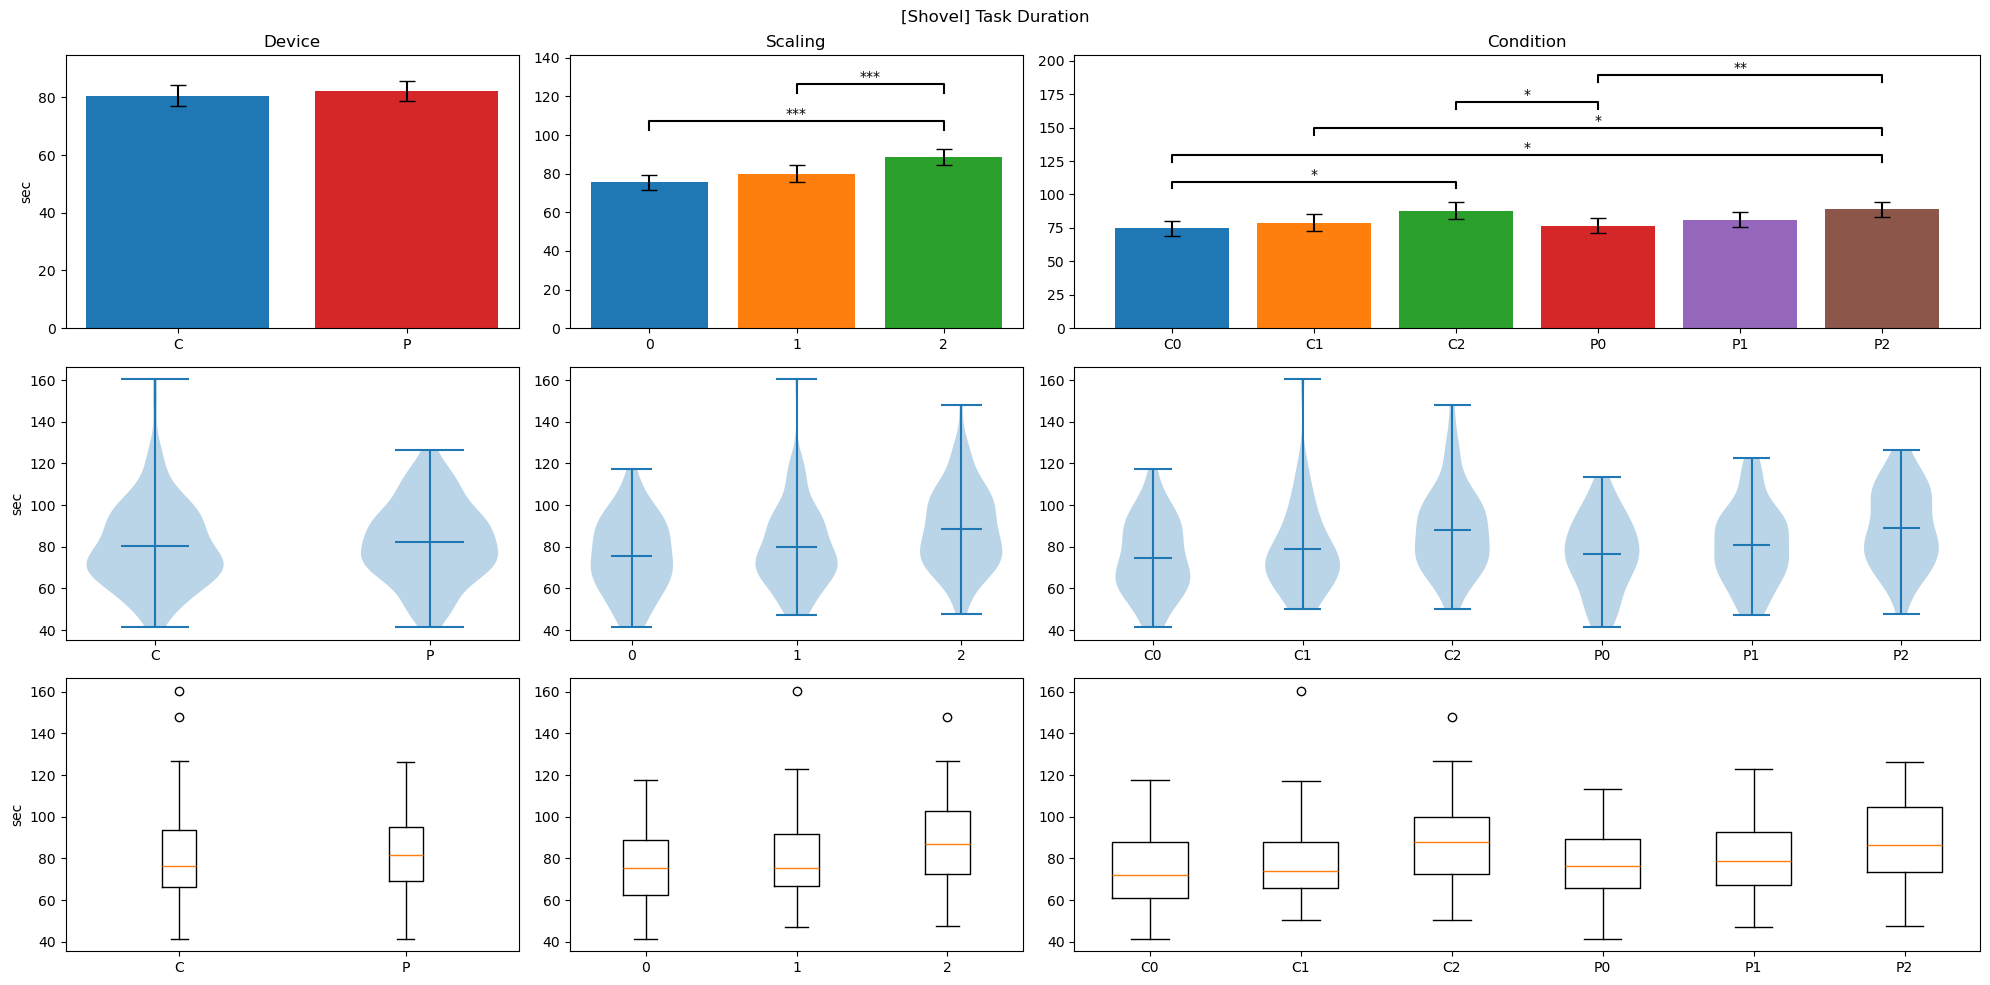

In [664]:
def task_duration(p):
    return (p[end_ts] - p[start_ts]) / 1_000

title = 'Task Duration'
ylabel = 'sec'
report_exeriment(data, task_duration, cube, title, ylabel)
report_exeriment(data, task_duration, shovel, title, ylabel)

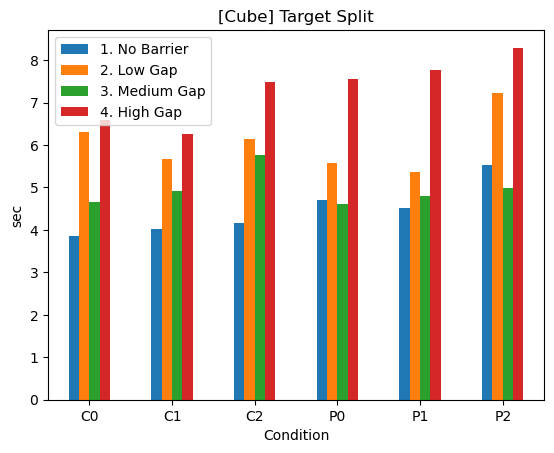

In [665]:
def single_target_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_time = first[unified_unix_key].max() - first[unified_unix_key].min()
    second_time = second[unified_unix_key].max() - second[unified_unix_key].min()
    third_time = third[unified_unix_key].max() - third[unified_unix_key].min()
    fourth_time = fourth[unified_unix_key].max() - fourth[unified_unix_key].min()

    return [first_time / 1_000, second_time / 1_000, third_time / 1_000, fourth_time / 1_000]

def agg_target_split(data, c):
    participants = list(map(lambda x: x[cube][c], data))

    splits = list(map(lambda x: single_target_split(x), participants))
    
    first = list(map(lambda x: x[0],  splits))
    second = list(map(lambda x: x[1], splits))
    third = list(map(lambda x: x[2],  splits))
    fourth = list(map(lambda x: x[3], splits))
    
    return [np.mean(first), np.mean(second), np.mean(third), np.mean(fourth)]

condition_splits = list(map(lambda x: agg_target_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["1. No Barrier", "2. Low Gap", "3. Medium Gap", "4. High Gap"], index = conditions)

df.plot(kind='bar', color=["tab:blue", "tab:orange", "tab:green", "tab:red"])

plt.title("[Cube] Target Split")
plt.xlabel("Condition")
plt.ylabel("sec")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

------ [Cube] 1. No Barrier Duration: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,51.728071,1,41,51.728071,7.861990,0.007680,0.007680,0.031440,1.000000,✅
1,Scaling,17.706917,2,82,8.853458,1.697802,0.189457,0.198250,0.010989,0.696471,❌
2,Device * Scaling,7.758596,2,82,3.879298,0.620894,0.539971,0.472949,0.004845,0.643212,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.803924,41.0,two-sided,0.00768,NaN,NaN,5.025,-0.550788,✅


------ [Cube] 1. No Barrier Duration: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,77.193584,5,15.438717,2.616316,0.025599,0.077984,0.046202,0.407915,False,0.059916,6.415467e-17,🟨
1,Error,1209.692094,205,5.900937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


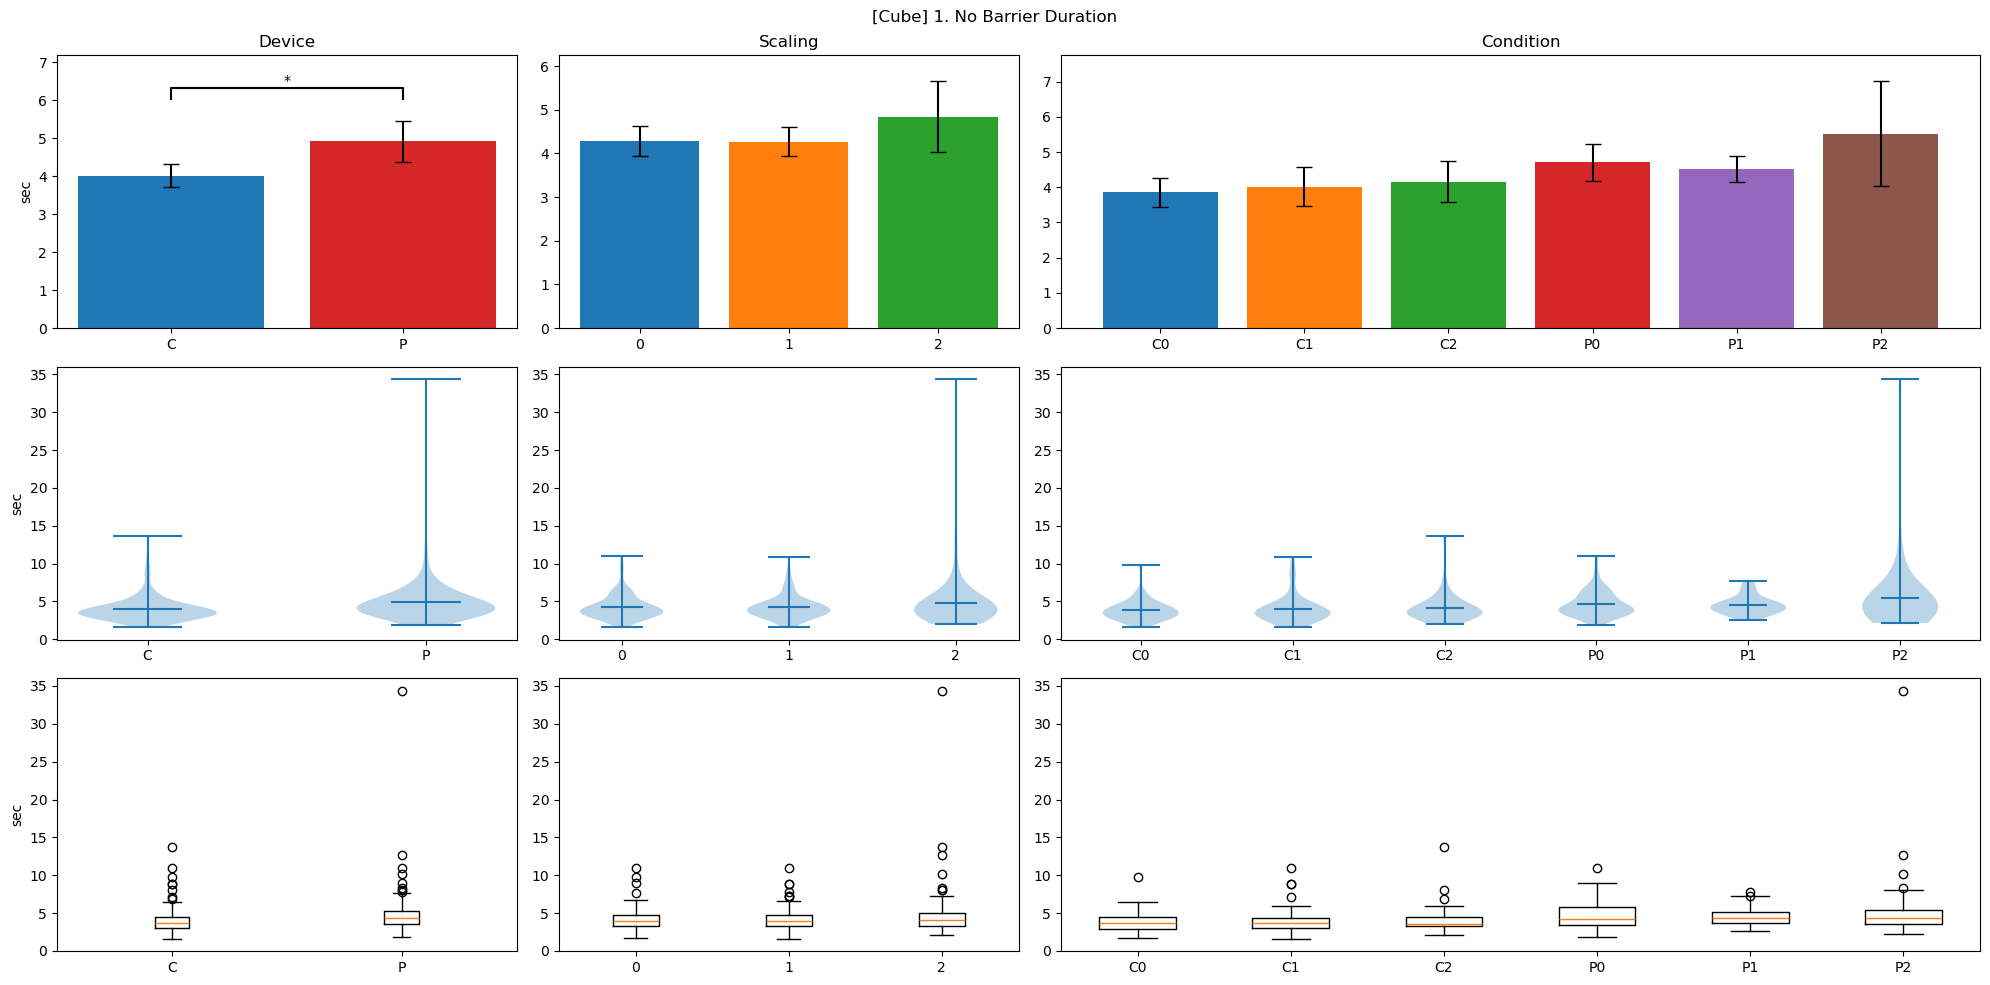

------ [Cube] 2. Low Gap Duration: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.016160,1,41,0.016160,0.000908,0.976109,0.976109,0.000004,1.000000,❌
1,Scaling,59.694881,2,82,29.847441,2.036516,0.137030,0.149660,0.013676,0.759533,❌
2,Device * Scaling,37.937940,2,82,18.968970,1.687544,0.191333,0.194037,0.008735,0.917295,❌


------ [Cube] 2. Low Gap Duration: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,97.648981,5,19.529796,1.403148,0.224495,0.242659,0.022179,0.653007,False,0.286095,0.00001,❌
1,Error,2853.304613,205,13.918559,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


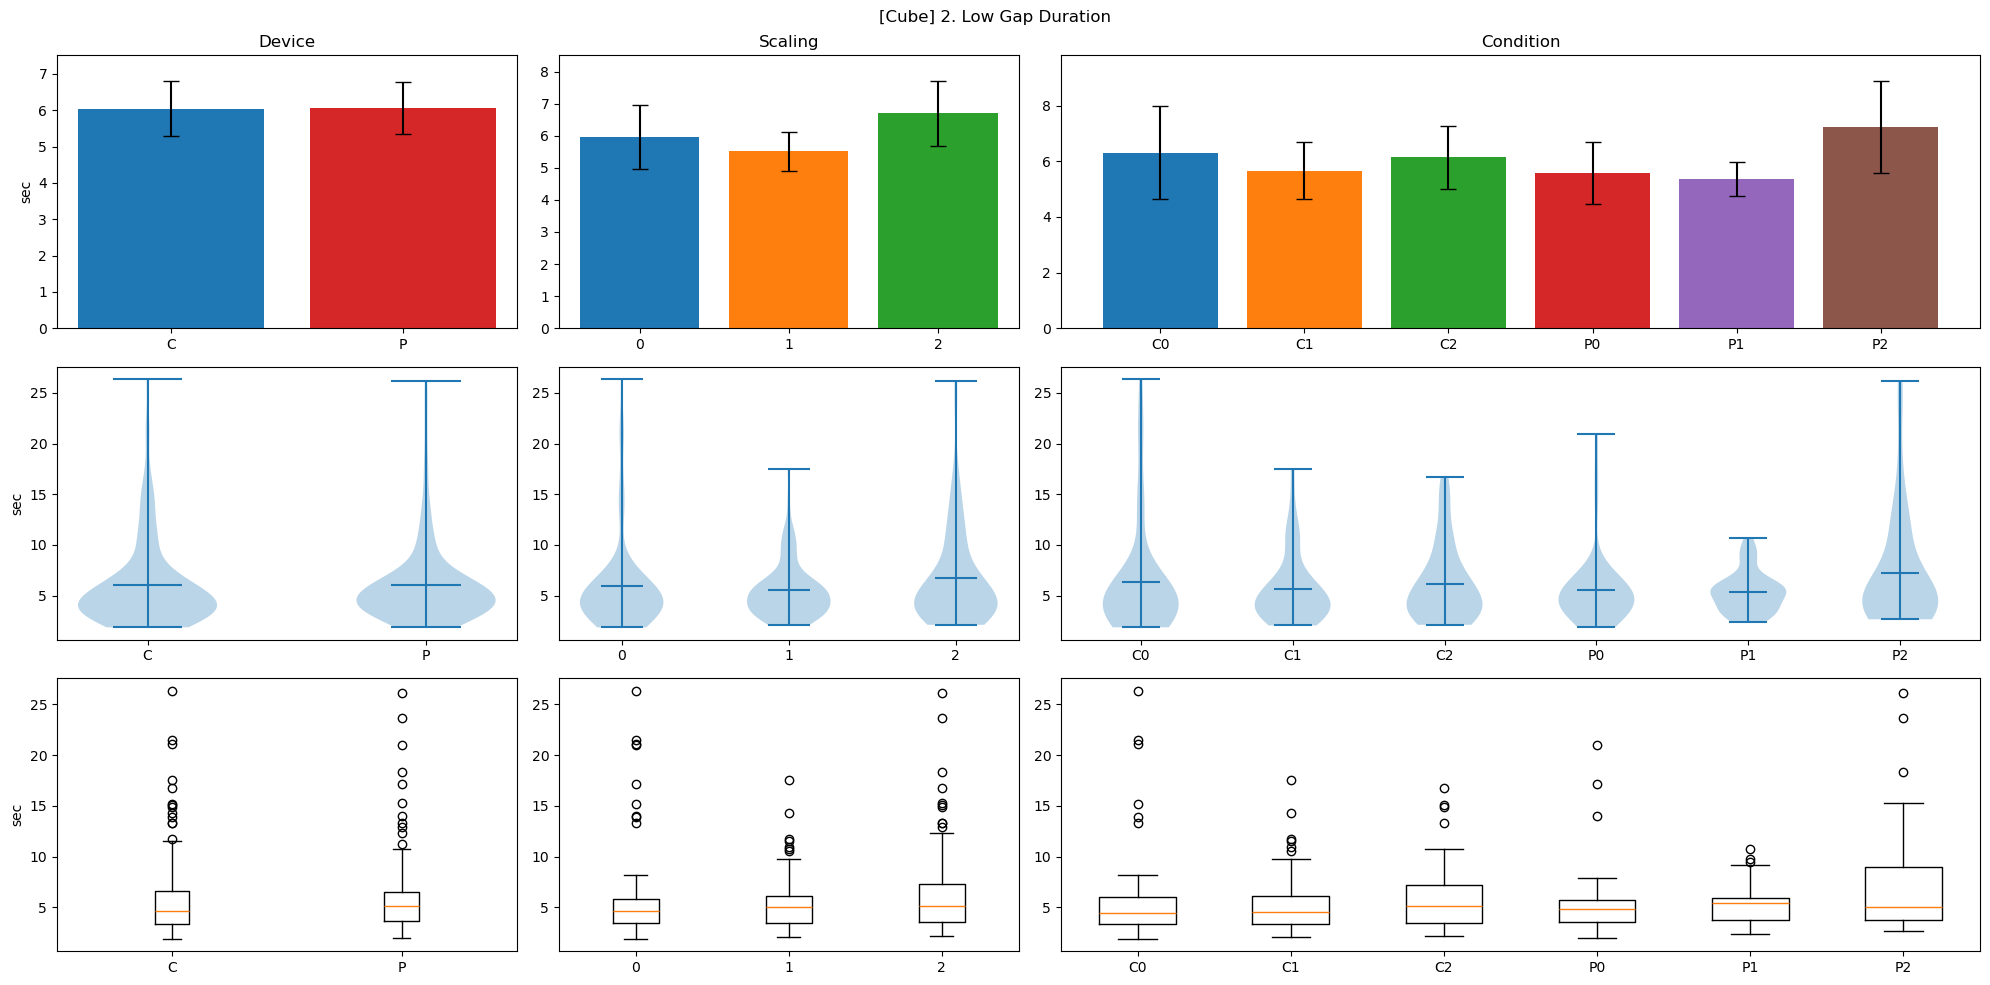

------ [Cube] 3. Medium Gap Duration: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,6.000789,1,41,6.000789,1.044895,0.312680,0.312680,0.003035,1.000000,❌
1,Scaling,24.331919,2,82,12.165959,2.200411,0.117256,0.129273,0.012194,0.794572,❌
2,Device * Scaling,6.875315,2,82,3.437658,0.827098,0.440931,0.419121,0.003476,0.807764,❌


------ [Cube] 3. Medium Gap Duration: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,37.208023,5,7.441605,1.481598,0.197217,0.224213,0.018527,0.577944,False,0.138356,9.566995e-11,❌
1,Error,1029.650748,205,5.022687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


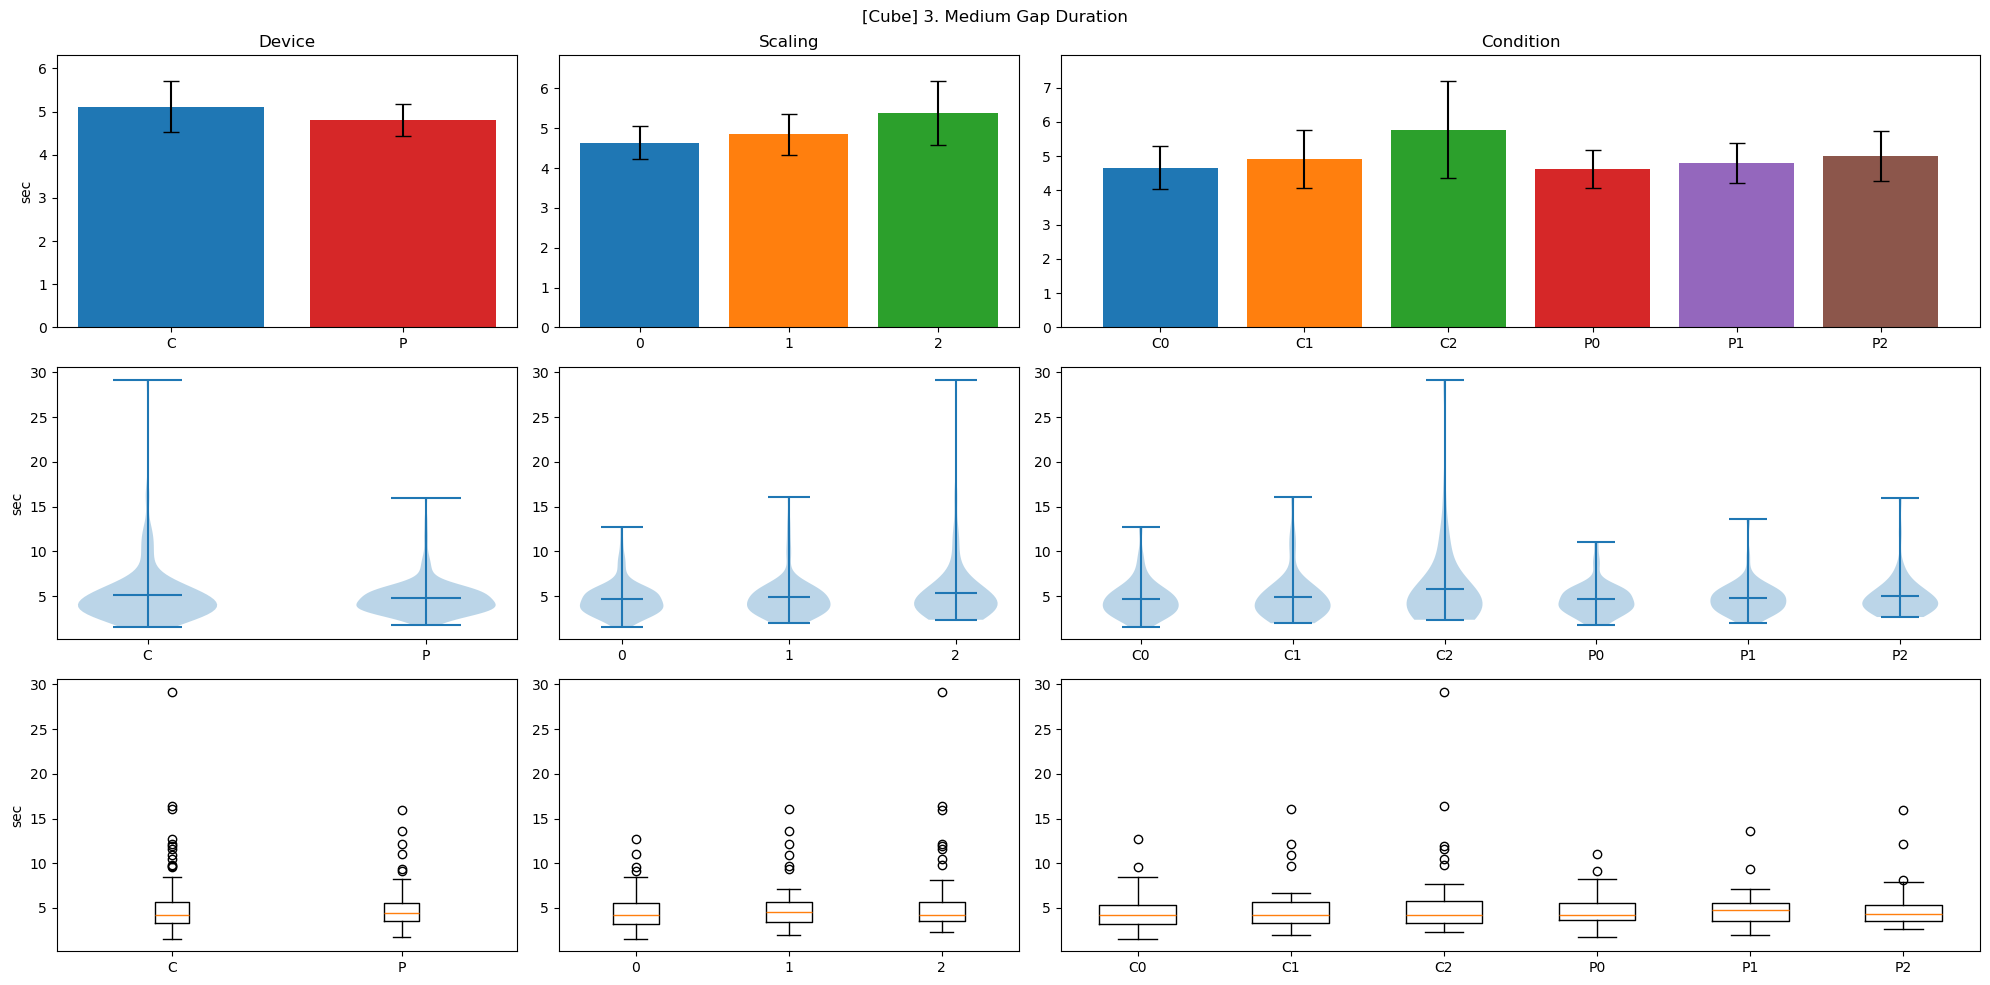

------ [Cube] 4. High Gap Duration: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,75.160180,1,41,75.160180,15.917703,0.000267,0.000267,0.038639,1.000000,✅
1,Scaling,40.372807,2,82,20.186404,3.813254,0.026090,0.034997,0.021133,0.816239,✅
2,Device * Scaling,5.416871,2,82,2.708436,0.668588,0.515203,0.504155,0.002888,0.924583,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.989700,41.0,two-sided,0.000267,NaN,NaN,98.592,-0.510919,✅
1,Scaling,-,0,1,True,True,0.166456,41.0,two-sided,0.868616,0.868616,holm,0.169,0.023516,❌
2,Scaling,-,0,2,True,True,-1.906594,41.0,two-sided,0.063598,0.127196,holm,0.866,-0.320176,❌
3,Scaling,-,1,2,True,True,-2.841588,41.0,two-sided,0.006963,0.020888,holm,5.468,-0.382761,✅


------ [Cube] 4. High Gap Duration: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,120.949859,5,24.189972,5.166313,0.000174,0.000529,0.060749,0.821295,False,0.537704,0.042955,✅
1,Error,959.861294,205,4.682250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,0.776620,41.0,two-sided,0.441841,1.000000,holm,0.221,0.123026,❌
1,Condition,C0,C2,True,True,-1.726990,41.0,two-sided,0.091698,0.733580,holm,0.651,-0.300248,❌
2,Condition,C0,P0,True,True,-2.261653,41.0,two-sided,0.029087,0.261786,holm,1.631,-0.337422,❌
3,Condition,C0,P1,True,True,-2.736989,41.0,two-sided,0.009126,0.109516,holm,4.333,-0.505876,❌
4,Condition,C0,P2,True,True,-3.051999,41.0,two-sided,0.003978,0.051716,holm,8.89,-0.648807,🟨
5,Condition,C1,C2,True,True,-2.317209,41.0,two-sided,0.025564,0.255635,holm,1.815,-0.403353,❌
6,Condition,C1,P0,True,True,-2.611110,41.0,two-sided,0.012550,0.138048,holm,3.301,-0.444762,❌
7,Condition,C1,P1,True,True,-3.431519,41.0,two-sided,0.001383,0.019360,holm,22.548,-0.635118,✅
8,Condition,C1,P2,True,True,-4.650153,41.0,two-sided,0.000034,0.000514,holm,639.325,-0.762766,✅
9,Condition,C2,P0,True,True,-0.129873,41.0,two-sided,0.897302,1.000000,holm,0.168,-0.020783,❌


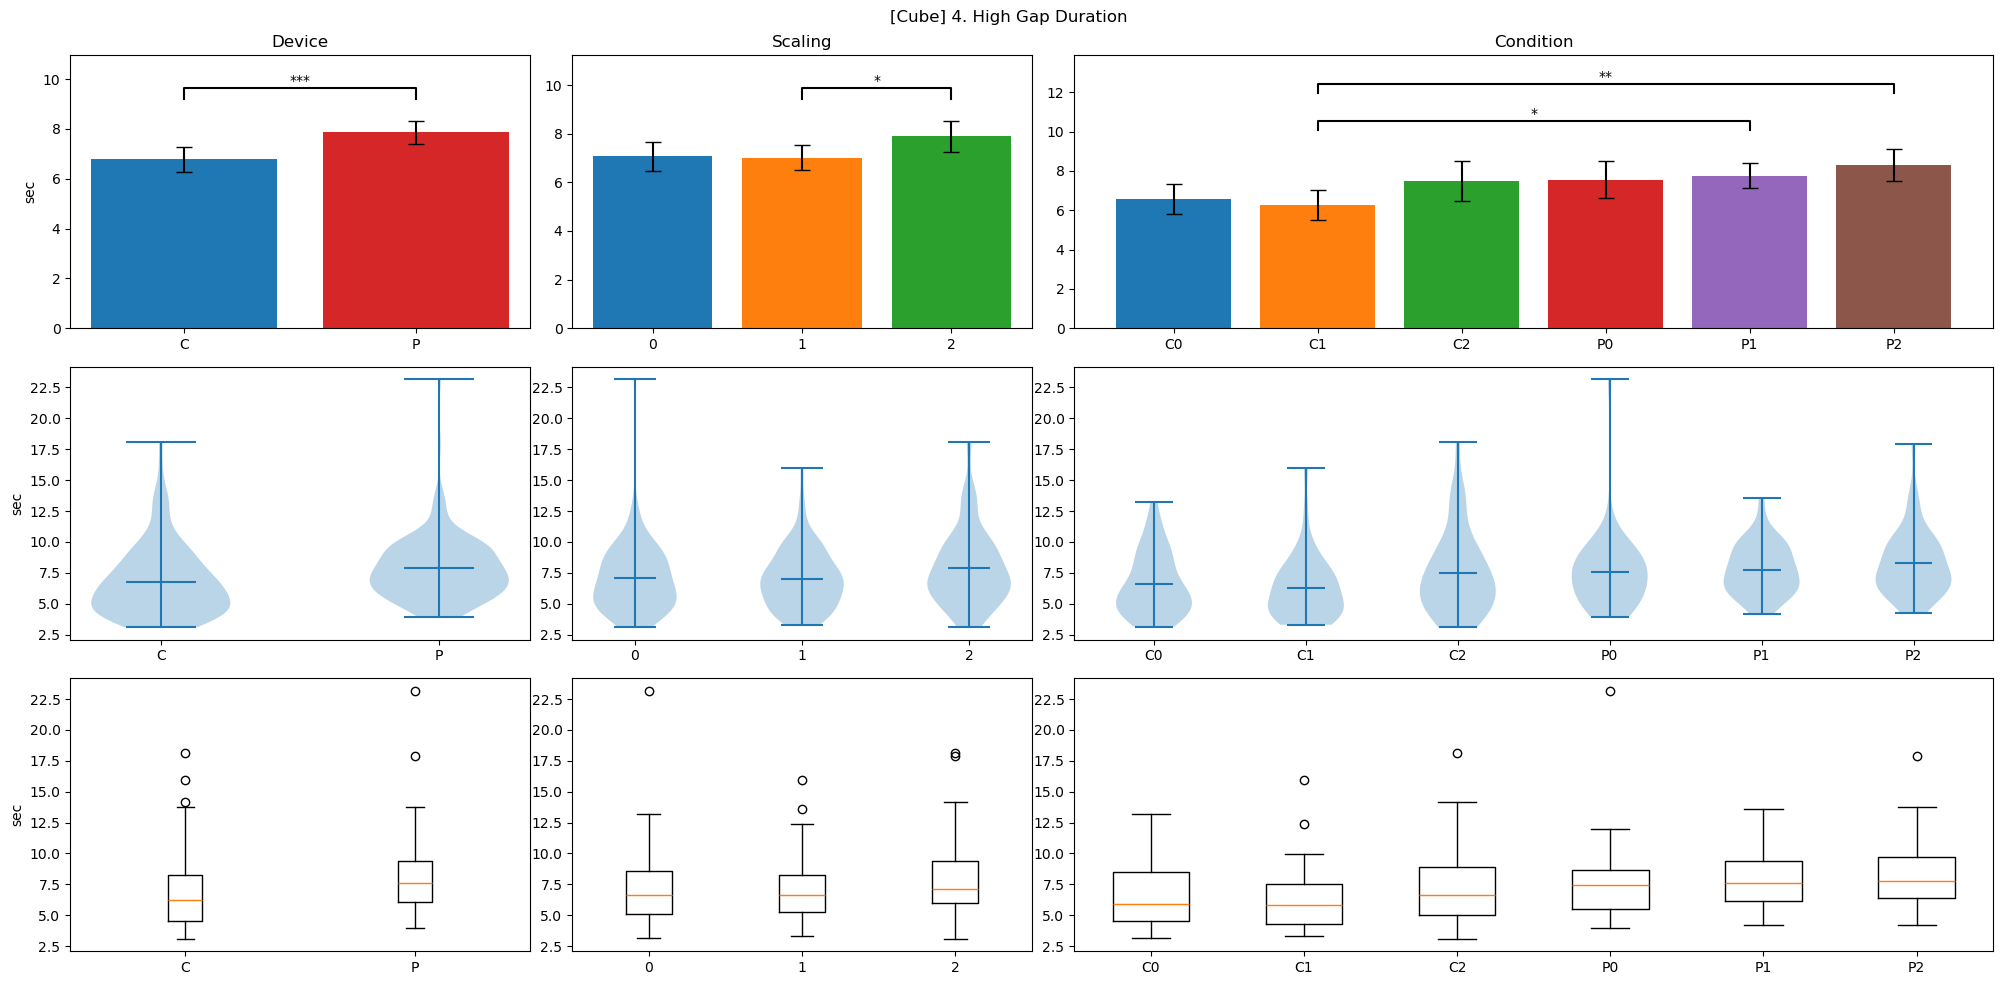

In [666]:
def single_first(p):
    return single_target_split(p)[0]

def single_second(p):
    return single_target_split(p)[1]

def single_third(p):
    return single_target_split(p)[2]

def single_fourth(p):
    return single_target_split(p)[3]

title = "1. No Barrier Duration"
ylabel = "sec"
report_exeriment(data, single_first, cube, title, ylabel)

title = "2. Low Gap Duration"
ylabel = "sec"
report_exeriment(data, single_second, cube, title, ylabel)

title = "3. Medium Gap Duration"
ylabel = "sec"
report_exeriment(data, single_third, cube, title, ylabel)

title = "4. High Gap Duration"
ylabel = "sec"
report_exeriment(data, single_fourth, cube, title, ylabel)

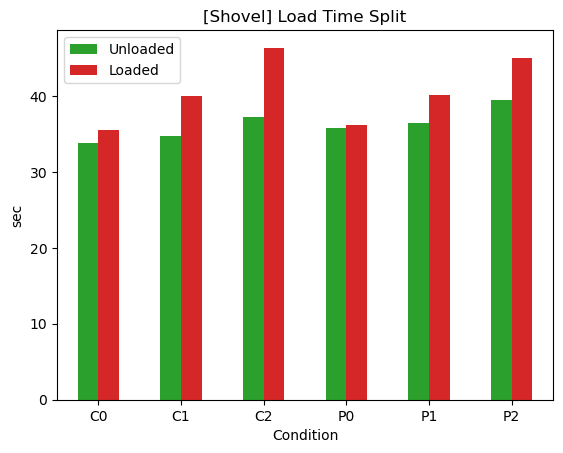

In [667]:
def single_load_time_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    loaded_time = 0
    unloaded_time = 0

    for i in range(20):
        single = df[(df["collision_or_load_count"] == i+1)]

        unloaded = single[(single["shovel_loaded_state"] == False)]
        unloaded_time += unloaded[unity_unix_key].max() - unloaded[unity_unix_key].min()

        loaded = single[(single["shovel_loaded_state"] == True)]
        loaded_time += loaded[unity_unix_key].max() - loaded[unity_unix_key].min()
    
    return [unloaded_time / 1_000, loaded_time / 1_000]

def agg_load_time_split(data, c):
    participants = list(map(lambda x: x[shovel][c], data))

    splits = list(map(lambda x: single_load_time_split(x), participants))
    
    unloaded_times = list(map(lambda x: x[0], splits))
    loaded_times = list(map(lambda x: x[1], splits))
    
    return [np.mean(unloaded_times), np.mean(loaded_times)]

condition_splits = list(map(lambda x: agg_load_time_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["Unloaded", "Loaded"], index = conditions)

df.plot(kind='bar', color=["tab:green", "tab:red"])

plt.title("[Shovel] Load Time Split")
plt.xlabel("Condition")
plt.ylabel("sec")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

------ [Shovel] Loaded Duration: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,1.995558,1,41,1.995558,0.036418,8.495975e-01,8.495975e-01,0.000067,1.000000,❌
1,Scaling,4114.775772,2,82,2057.387886,37.346902,2.946071e-12,1.260352e-10,0.121265,0.836623,✅
2,Device * Scaling,45.818095,2,82,22.909048,0.344485,7.096055e-01,6.459415e-01,0.001534,0.743362,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-4.072889,41.0,two-sided,2.070822e-04,2.070822e-04,holm,123.963,-0.468023,✅
2,Scaling,-,0,2,True,True,-7.182456,41.0,two-sided,9.118662e-09,2.735599e-08,holm,1.397e+06,-1.001847,✅
3,Scaling,-,1,2,True,True,-5.731193,41.0,two-sided,1.042990e-06,2.085980e-06,holm,1.624e+04,-0.575179,✅


------ [Shovel] Loaded Duration: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,4162.589425,5,832.517885,13.969444,9.422663e-12,2.607930e-08,0.122501,0.642763,False,0.182128,8.466273e-09,✅
1,Error,12217.105373,205,59.595636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-2.414414,41.0,two-sided,2.030851e-02,1.015425e-01,holm,2.199,-0.409719,❌
1,Condition,C0,C2,True,True,-5.470180,41.0,two-sided,2.445240e-06,3.178812e-05,holm,7342.998,-0.941993,✅
2,Condition,C0,P0,True,True,-0.585917,41.0,two-sided,5.611428e-01,1.000000e+00,holm,0.196,-0.073609,❌
3,Condition,C0,P1,True,True,-2.826360,41.0,two-sided,7.244768e-03,4.923022e-02,holm,5.284,-0.453634,✅
4,Condition,C0,P2,True,True,-5.214992,41.0,two-sided,5.602636e-06,6.723163e-05,holm,3400.814,-0.956396,✅
5,Condition,C1,C2,True,True,-2.837743,41.0,two-sided,7.032888e-03,4.923022e-02,holm,5.421,-0.494749,✅
6,Condition,C1,P0,True,True,2.009639,41.0,two-sided,5.108185e-02,2.043274e-01,holm,1.031,0.339092,❌
7,Condition,C1,P1,True,True,-0.019348,41.0,two-sided,9.846576e-01,1.000000e+00,holm,0.167,-0.003704,❌
8,Condition,C1,P2,True,True,-3.252172,41.0,two-sided,2.294660e-03,1.835728e-02,holm,14.406,-0.439373,✅
9,Condition,C2,P0,True,True,6.746704,41.0,two-sided,3.758922e-08,5.638383e-07,holm,3.668e+05,0.866759,✅


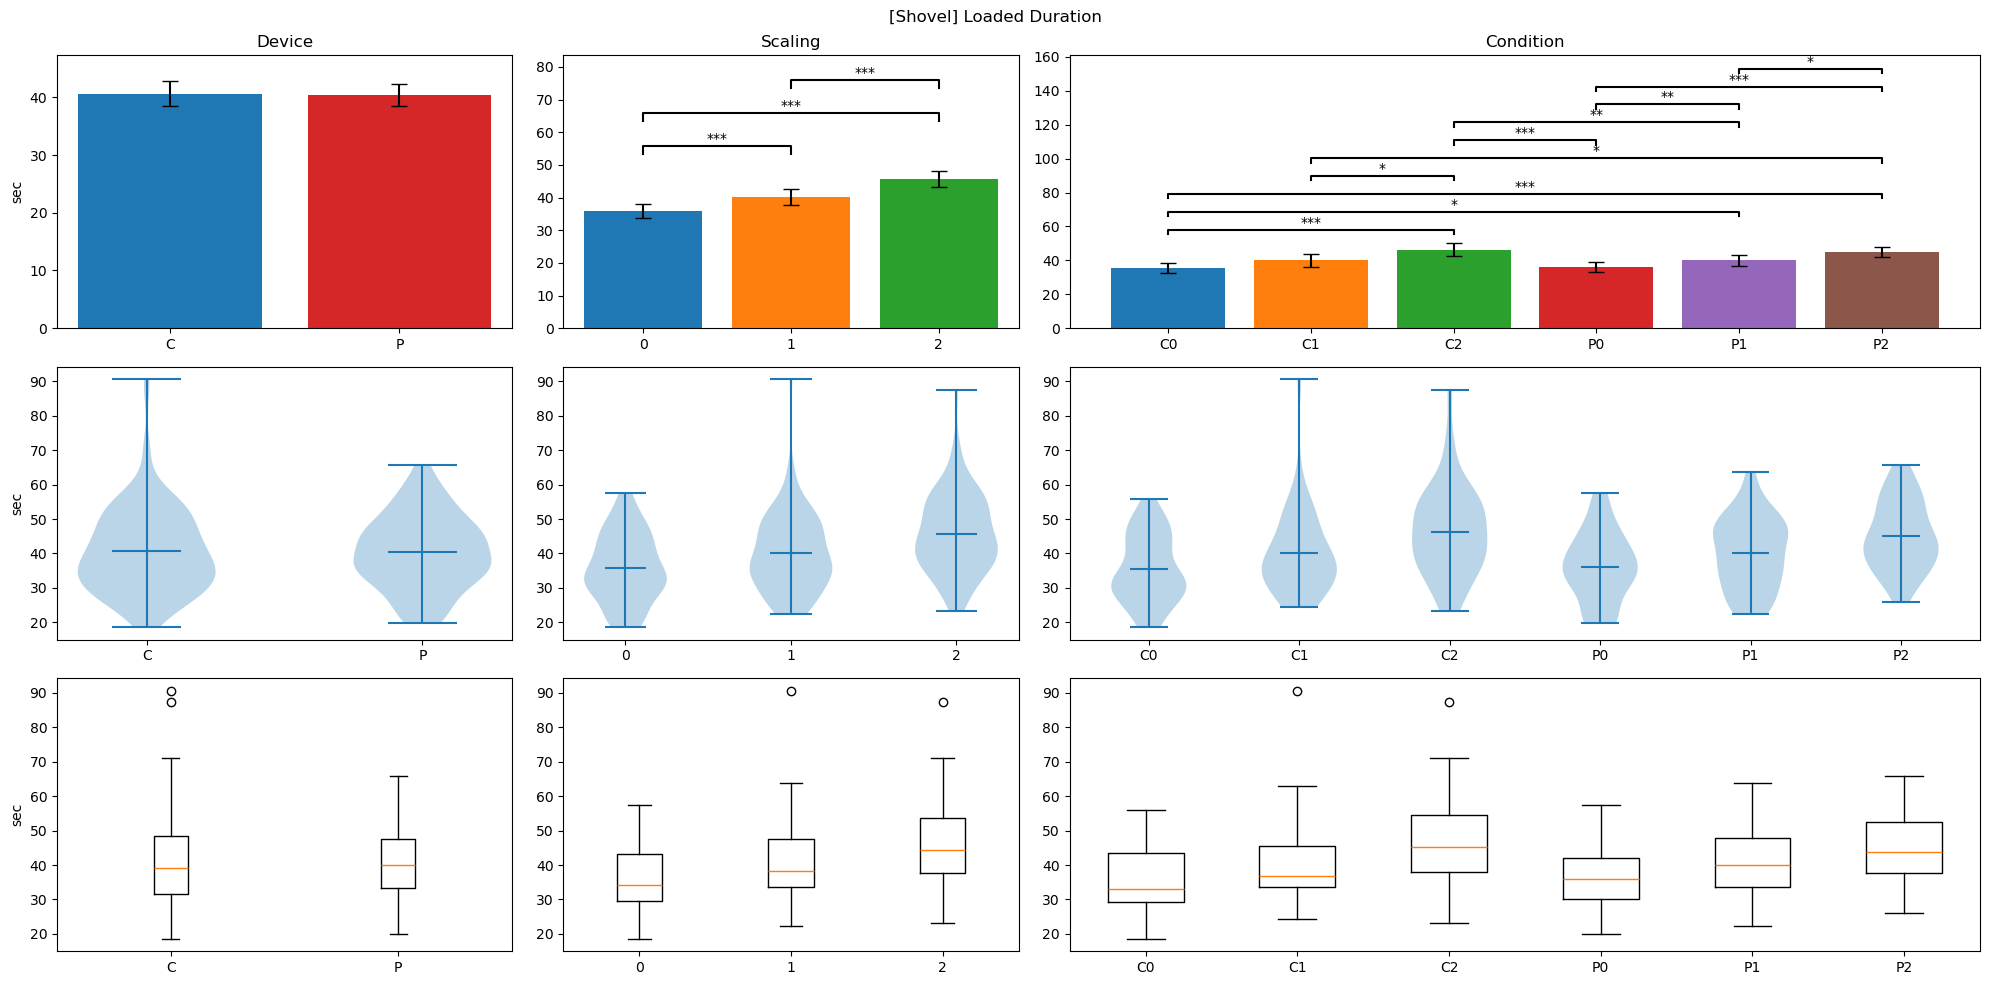

------ [Shovel] Unloaded Duration: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,253.783143,1,41,253.783143,5.819635,0.020407,0.020407,0.015293,1.000000,✅
1,Scaling,596.233330,2,82,298.116665,6.249929,0.002976,0.005059,0.035203,0.844454,✅
2,Device * Scaling,2.448700,2,82,1.224350,0.043354,0.957595,0.937373,0.000150,0.850618,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.412392,41.0,two-sided,0.020407,NaN,NaN,2.19,-0.310149,✅
1,Scaling,-,0,1,True,True,-0.929222,41.0,two-sided,0.358213,0.358213,holm,0.25,-0.114614,❌
2,Scaling,-,0,2,True,True,-2.850946,41.0,two-sided,0.006794,0.020383,holm,5.585,-0.500862,✅
3,Scaling,-,1,2,True,True,-2.688841,41.0,two-sided,0.010319,0.020637,holm,3.9,-0.388330,✅


------ [Shovel] Unloaded Duration: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,852.465174,5,170.493035,4.36069,0.000857,0.002686,0.049581,0.761821,False,0.381003,0.000583,✅
1,Error,8015.033270,205,39.097723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-0.700090,41.0,two-sided,0.487825,1.000000,holm,0.21,-0.110728,❌
1,Condition,C0,C2,True,True,-2.460783,41.0,two-sided,0.018164,0.236130,holm,2.415,-0.472466,❌
2,Condition,C0,P0,True,True,-2.035310,41.0,two-sided,0.048318,0.483183,holm,1.078,-0.254277,❌
3,Condition,C0,P1,True,True,-1.933485,41.0,two-sided,0.060101,0.540911,holm,0.905,-0.337006,❌
4,Condition,C0,P2,True,True,-3.336280,41.0,two-sided,0.001812,0.027184,holm,17.743,-0.666041,✅
5,Condition,C1,C2,True,True,-1.780095,41.0,two-sided,0.082473,0.659780,holm,0.706,-0.324375,❌
6,Condition,C1,P0,True,True,-0.814066,41.0,two-sided,0.420310,1.000000,holm,0.228,-0.129923,❌
7,Condition,C1,P1,True,True,-1.226994,41.0,two-sided,0.226824,1.000000,holm,0.335,-0.211563,❌
8,Condition,C1,P2,True,True,-3.002189,41.0,two-sided,0.004550,0.063699,holm,7.908,-0.531258,🟨
9,Condition,C2,P0,True,True,1.160889,41.0,two-sided,0.252402,1.000000,holm,0.312,0.195003,❌


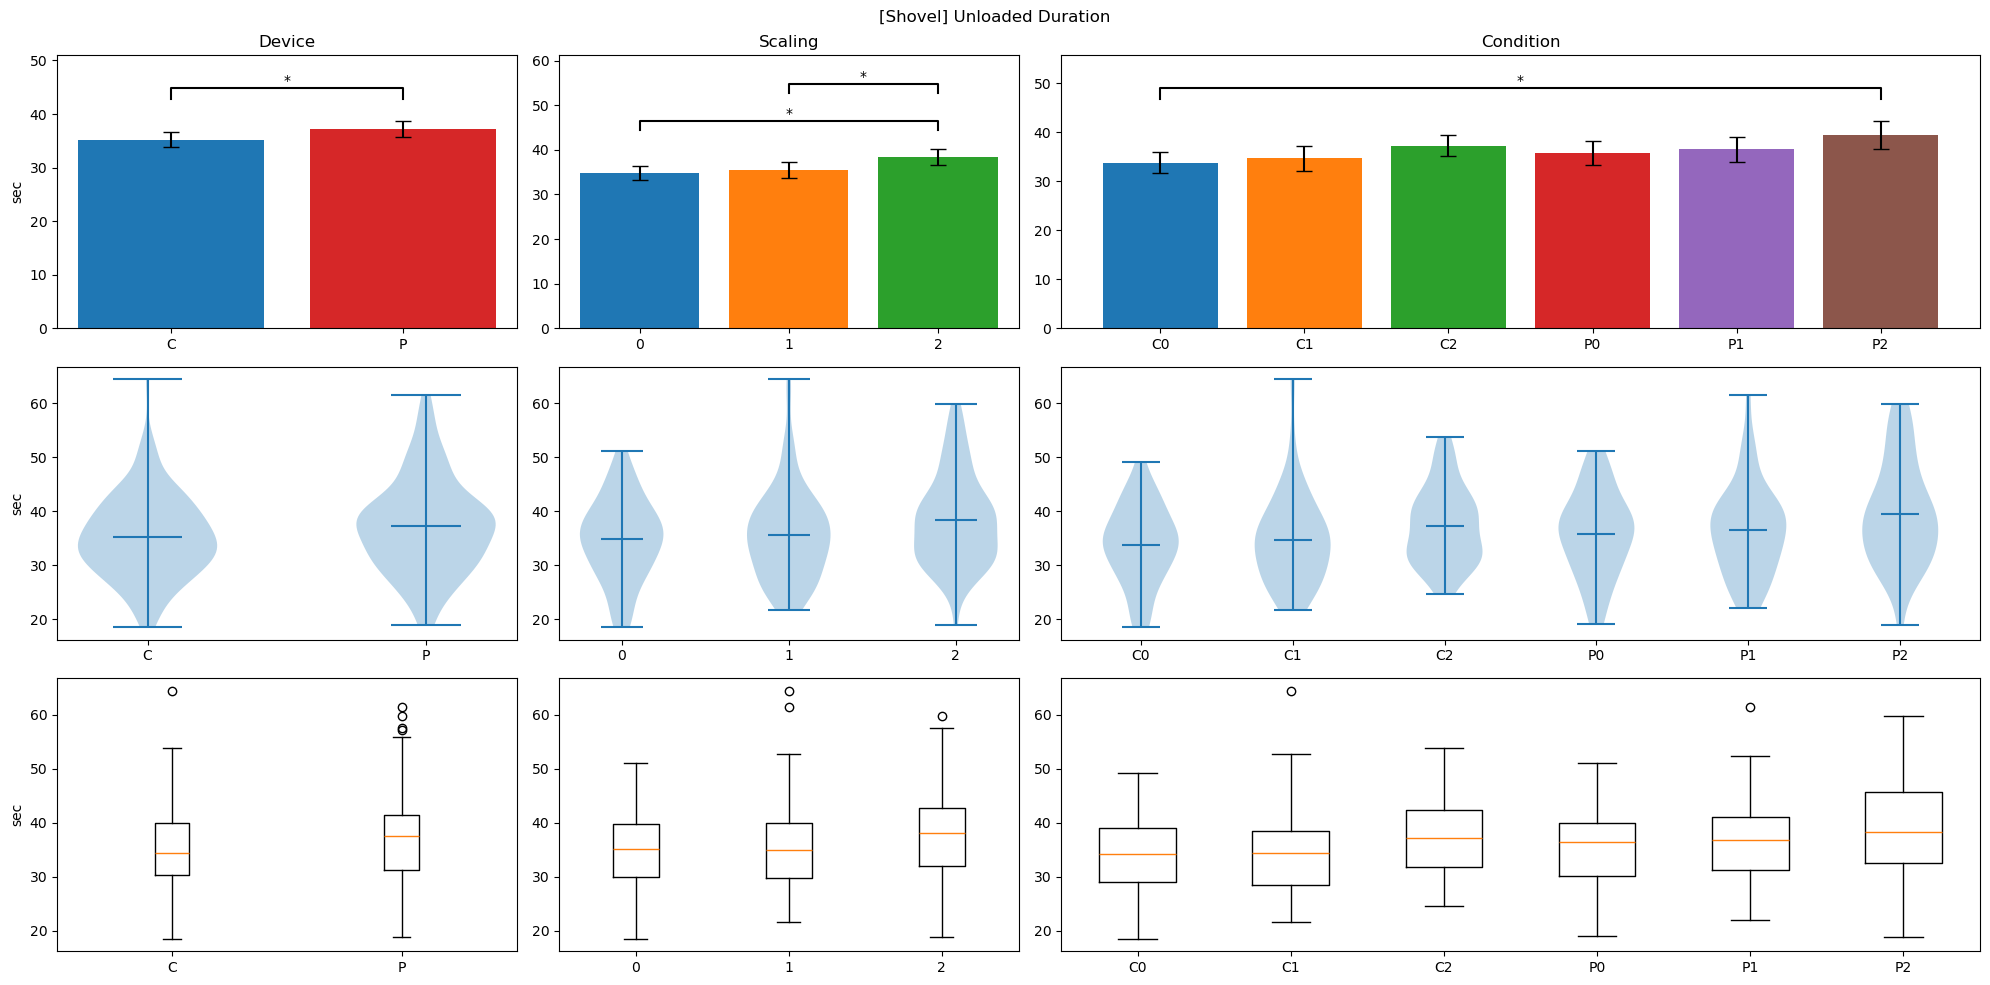

In [668]:
def single_unloaded(p):
    return single_load_time_split(p)[0]

def single_loaded(p):
    return single_load_time_split(p)[1]

title = "Loaded Duration"
ylabel = "sec"
report_exeriment(data, single_loaded, shovel, title, ylabel)

title = "Unloaded Duration"
ylabel = "sec"
report_exeriment(data, single_unloaded, shovel, title, ylabel)

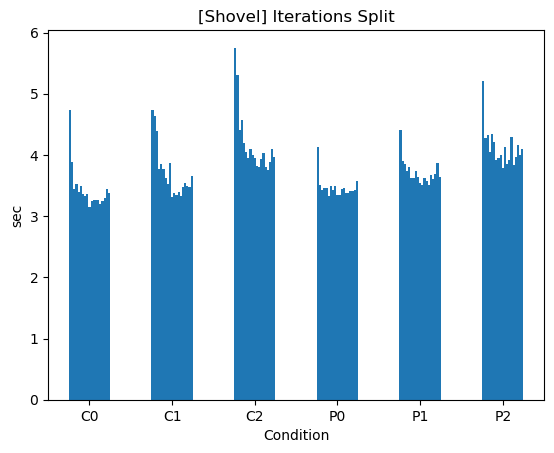

In [669]:
n_iterations = range(19)

def single_iteration_split (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    iteration_times = []

    for i in n_iterations:
        iteration = df[(df["collision_or_load_count"] == i+1)]
        time = (iteration[unity_unix_key].max() - iteration[unity_unix_key].min() ) / 1_000
        iteration_times.append(time)
    
    return iteration_times

def agg_iteration_split(data, c):
    participants = list(map(lambda x: x[shovel][c], data))

    participant_splits = list(map(lambda x: single_iteration_split(x), participants))
    n_participants = len(participants)

    splits = []

    for i in n_iterations:
        splits.append([])
        for j in range(n_participants):
            splits[i].append(participant_splits[j][i])

    split_means = list(map(lambda x: np.mean(x), splits))
    
    return split_means

condition_splits = list(map(lambda x: agg_iteration_split(data, x), conditions))

columns = list(map(lambda x: str(x+1), n_iterations))

df = pd.DataFrame(condition_splits, columns=columns, index = conditions)

df.plot(kind='bar', color = "tab:blue", legend=False)

plt.title("[Shovel] Iterations Split")
plt.xlabel("Condition")
plt.ylabel("sec")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

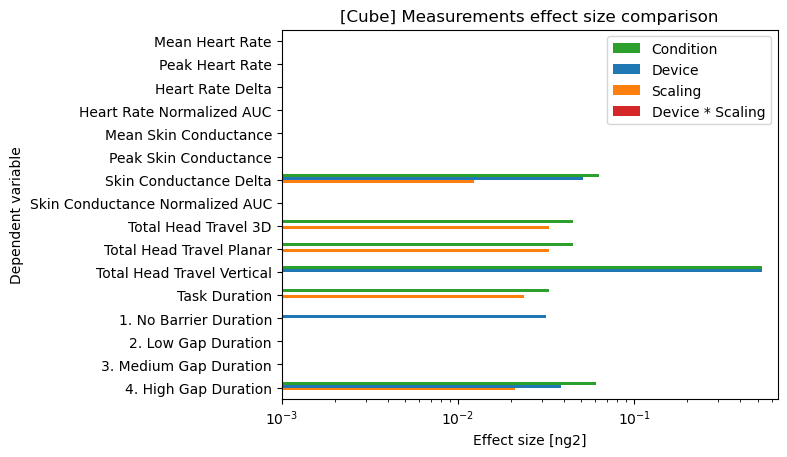

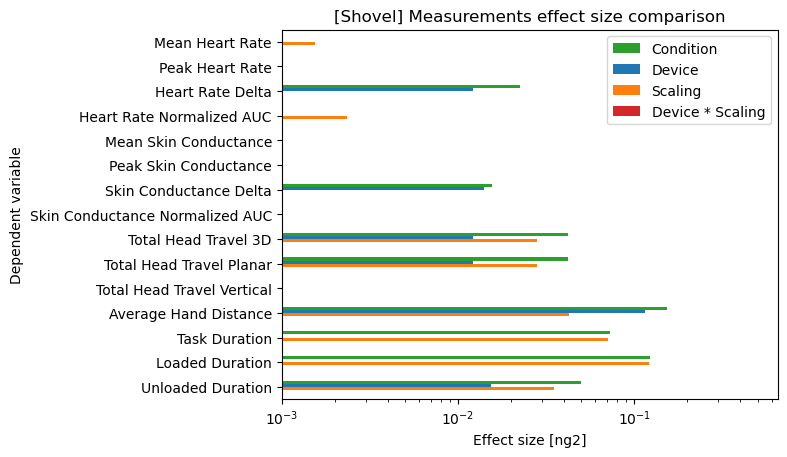

In [670]:
show_eff_size_comparison('Measurements', xlim=[0.001, 0.65])